# RAFT-Stereo — DIMER guided notebook: dense stereo disparity and bounded stereo fine-tuning (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/raft-stereo-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/raft-stereo-pipeline/blob/main/tutorials/raft_stereo_colab.ipynb) [![Upstream](https://img.shields.io/badge/Upstream-princeton--vl%2FRAFT--Stereo-181717?style=flat&logo=github&logoColor=white)](https://github.com/princeton-vl/RAFT-Stereo) [![arXiv](https://img.shields.io/badge/arXiv-2109.07547-b31b1b.svg)](https://arxiv.org/abs/2109.07547) [![License](https://img.shields.io/badge/License-Apache--2.0-blue.svg)](https://github.com/kurtvalcorza/raft-stereo-pipeline/blob/main/LICENSE)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** dense disparity estimation for rectified stereo pairs with RAFT-Stereo (`princeton-vl/RAFT-Stereo`, Middlebury checkpoint), evaluated by end-point error and bad-pixel rates against a median constant, OpenCV StereoSGBM and the pretrained network, and a bounded stereo fine-tune that exports a reloadable SafeTensors adapter

**This notebook is standalone.** Section 2 carries the repository's package (3 modules under `src/raft_stereo_pipeline/`, at revision `95db0ef90f15`), the upstream third-party source it builds on (8 files under `src/raft_stereo_pipeline/third_party/`, carried verbatim with its licence), the stage runner, the hash-locked requirements (35 packages), the pinned snapshot manifests and the licence, and verifies every carried file against its SHA-256 before use, so the notebook keeps working after export even if the repository changes or disappears. Nothing is installed into the notebook kernel: a pinned `uv` (checked by size and SHA-256) builds an isolated Python environment from the lock with `--require-hashes`, and every stage runs there in its own process, so the hosted runtime's own packages are never replaced and no restart is needed. Its only external dependencies are PyPI, the managed CPython build that `uv` downloads, and the upstream RAFT-Stereo checkpoint archive (`models.zip`, linked from upstream's `download_models.sh`, on Dropbox, no credential): only the `raftstereo-middlebury.pth` member is kept, and its ~45 MB, digest-verified before loading. It was generated by `tools/build_notebook.py` (build_notebook.py/3.1); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh Linux x86_64 runtime (a Colab or Kaggle **T4 GPU** is the documented runtime; a CPU-only runtime completes the same path, much more slowly — see the Prerequisites) builds an isolated Python environment from the carried hash-locked requirements (35 packages: torch, numpy, scipy, opt-einsum, opencv-python-headless, safetensors, pillow and their dependencies) without touching the notebook kernel's own packages, then runs each stage below in its own process: it verifies the carried upstream RAFT-Stereo source against its SHA-256 digests, stages and digest-verifies the pinned Middlebury checkpoint (Section 3 refuses to load a checkpoint whose SHA-256 is not pinned), runs the pretrained model on a rendered demonstration pair and two probes with exact answers, renders and validates a 32-pair dataset with exact ground-truth disparity and splits it 24 / 8, scores three baselines on the held-out pairs, **runs a bounded fine-tune**, scores the exported adapter in a fresh process, runs the adapted model on three unseen pairs and exports their disparity maps, and reloads the adapter in another fresh process to check that it reproduces the trained model. Nothing is skipped behind a default-off flag, and no clone, DIMER worker, credential, upload dialog or configuration edit is needed, and no restart (NOTEBOOK_SPEC 2.2 §5, RUN7, FT2).

**Bring Your Own Data:** Two optional branches in Section 13 are off by default (`USE_BYOD_PAIR = False`, `USE_BYOD_DATASET = False`). The **pair** branch runs your own rectified pair (and, if you have it, its ground-truth disparity) through the same validation, model, SGBM baseline and evaluation report as the demonstration pair. The **dataset** branch takes a folder of your own labelled pairs through the full workflow — validate → split → baselines → fine-tune → evaluate → infer → export → reload — with the same stages as the sample (NOTEBOOK_SPEC 2.2 DAT14), writing to `outputs/byod/` so the sample results are kept. Location fields (`BYOD_LEFT_PATH`, `BYOD_RIGHT_PATH`, `BYOD_DISPARITY_PATH`, `BYOD_DATASET_DIR`) read from a path without an upload dialog (EXE2); left empty on Colab, they open one. Uploaded files stay in this runtime.

A **rectified stereo pair** is two images taken side by side and aligned so that every scene point appears on the *same row* in both. The horizontal offset between the two appearances is the **disparity** `d`, in pixels: the left-image pixel `(x, y)` shows the same point as the right-image pixel `(x − d, y)`. Near surfaces have large disparity and far ones small, and with a calibrated rig depth follows as `focal length × baseline / d`. Stereo matching estimates `d` for every left-image pixel.

**RAFT-Stereo** (Lipson, Teed and Deng, 2021) does this with a recurrent network: two convolutional encoders turn each image into features at 1/4 resolution, a **correlation volume** compares every left feature with every right feature on the same row, and a multi-level GRU starts from zero disparity and refines it over a chosen number of **iterations**, each time looking up the correlation around its current estimate; a learned convex upsampling returns full resolution. The upstream code is not on PyPI, so this notebook carries the upstream `core/` package verbatim (MIT licence, commit `6e93ed2`) and verifies every file's SHA-256 before importing it. It uses upstream's pure-PyTorch correlation (`corr_implementation = 'reg'`), so the optional CUDA sampler extension is never built and the same code runs on a GPU or a CPU.

**The default path really adapts the model.** The tutorial data are rendered in code — slanted textured backgrounds with textured objects in front, a right camera with a different gain and offset, and sensor noise — so the ground-truth disparity is exact and the data carry no licence or download. The checkpoint was fine-tuned on Middlebury photographs; Section 8 adapts it to this rendered domain with a short fine-tune, and Sections 9–11 measure, use, export and reload the result. Every number is measured in this runtime; none is copied from the paper.

**Learning objectives:** by the end you should be able to (1) state the stereo task as *rectified pair → disparity of the left image* and explain what a disparity value means geometrically (Section 4); (2) explain what the refinement iterations do and use two probes with exact answers to check a model's sign and scale (Sections 4–5); (3) explain why a dataset is validated and split before any model runs, and why baselines are configured on the training split only (Sections 6–7); (4) compare end-point error (EPE) with bad-pixel rates and say what each hides (Sections 7 and 9); (5) read a training loss as optimisation evidence and the held-out comparison as task evidence (Sections 8–9); (6) interpret the adapted model's disparity on unseen pairs and check that an exported adapter reproduces the trained model (Sections 10–11); and (7) predict, then measure, what unfreezing the encoders changes when both runs start from the same checkpoint (Section 14). Along the way the notebook builds a locked runtime, verifies carried upstream code and a pinned checkpoint, and writes machine-readable outputs with provenance.

**This notebook does not demonstrate:** accuracy on real photographs or any deployment rig (the default data are rendered, and the held-out score is measured on 8 rendered pairs); benchmark results (no KITTI, Middlebury, ETH3D or SceneFlow evaluation is run, and the paper's numbers are not reproduced here); depth in metres (no camera calibration is used); stereo rectification of unrectified images; confidence or uncertainty estimates (RAFT-Stereo outputs none); upstream's full training recipe (OneCycle schedule, augmentation, mixed precision, 200,000 steps on two GPUs); and the faster CUDA correlation kernels.

## How to use this notebook

**Who this notebook is for.** Learners who can open a hosted notebook (Google Colab or Jupyter), run cells in order and read short Python, and who want to see how a pretrained stereo network is evaluated honestly and adapted to a new domain. No prior stereo-vision experience is assumed: each term is explained where it is first needed and the glossary below collects them. A T4 GPU is recommended; a CPU-only runtime works but is slow. The **Prerequisites** give the details.

**Running it.** In Colab, choose *Runtime → Change runtime type → T4 GPU*, then *Runtime → Run all*. The default path needs no edit, no upload, no account, no token and no runtime restart. Sections 1–3 build an isolated environment from hash-locked packages and download the checkpoint archive, so they take the longest before any model runs; read ahead while they finish.

**Where the code runs.** The notebook kernel installs nothing and imports no model library. Each learner cell calls `run_stage('…')`, which runs one stage of the carried stage runner in its own process with the isolated environment's Python, streams what it prints, and stops the notebook with the stage's own error message if it fails. Stages hand results to each other only through files in the run directory — the verified checkpoint, the recorded split, the adapter and JSON records — so each stage that needs a model loads it afresh from verified files.

**Two kinds of cell.** *Learner cells* (Sections 4–13) are the machine-learning workflow; each runs one stage and prints compact dictionaries for you to read. *Infrastructure cells* (Sections 1–3: the runtime check, the carried code, the isolated install and the checkpoint staging) are collapsed and titled **Infrastructure**. You may run them without studying their implementation: they exist for reproducibility and provenance, not as prerequisite machine-learning knowledge.

**Form controls.** Some learner cells start with fields that Colab renders as a form: `VALID_ITERS` (Section 4); `N_PAIRS`, `DATASET_SEED`, `HOLDOUT`, `SEED` and `EPOCHS` (Section 6); `LEARNING_RATE`, `BATCH_SIZE`, `TRAIN_ITERS` and `FREEZE_ENCODERS` (Section 8); `NEW_DATA_SEED` (Section 10); and the BYOD switches and locations (Section 13). Leave them at their defaults for the first run. Changing a field and choosing *Runtime → Run after* from that cell is how you experiment afterwards.

**Section tags.** Each numbered heading carries one tag. **[Concept]** — what the model does and why. **[Evaluation practice]** — how the evidence is produced and how to read it. **[Engineering]** — reproducibility, provenance and packaging.

**Predict, then check.** Before each principal result a **Predict before running** prompt asks you to commit to an expectation; after it, **What to notice** describes normal output and a collapsed **Check your reasoning** block gives worked guidance. Write your own answer first, then open it. The notes describe the shape of a normal result rather than fixed numbers: this revision has no recorded hosted run, and exact values vary with the runtime.

## The task: Input → Model/System → Output

| Stage | Input | Model / system | Output |
|---|---|---|---|
| **Inference** | a rectified pair (left, right), same size; `VALID_ITERS` | padded to a multiple of 32 px → feature and context encoders (1/4 resolution) → row-wise correlation volume → multi-level GRU refining the disparity `VALID_ITERS` times → convex upsampling → cropped back | a disparity map for the left image, (H, W) float32 pixels, larger = nearer |
| **Adaptation** | 24 training pairs with exact disparity | the same network, BatchNorm frozen, encoders frozen by default; upstream's sequence loss on every refinement | updated weights, exported as a SafeTensors adapter |
| **Evaluation** | 8 held-out pairs never used for training or for any choice | the adapted model next to three baselines, all scored on the same valid pixels | EPE and bad-pixel rates per pair and on average |

The network outputs no confidence: every pixel gets a disparity, whether or not the scene allows a match there.

## Roadmap

| Section | Tag | What happens | What you read |
|---|---|---|---|
| 1. Check the runtime | [Engineering] | Linux, GPU (optional) and disk checked; a fresh run directory | the GPU name or the CPU note |
| 2. Carry the code, install the runtime | [Engineering] | carried files verified; an isolated hash-locked environment | versions, `cuda` |
| 3. Pin, stage and verify | [Engineering] | upstream source and checkpoint digest-checked | the verified file counts |
| 4. The pretrained model on one pair | [Concept] | disparity of a rendered pair, next to SGBM | EPE, bad-pixel rates, the figure |
| 5. Probes with exact answers | [Evaluation practice] | random dots shifted by 2 px and by 8 px | the predicted medians |
| 6. Dataset, validation and split | [Evaluation practice] | 32 pairs validated, split 24 / 8, refusals shown | split sizes, refusals |
| 7. Baselines on the held-out pairs | [Evaluation practice] | median constant, SGBM, pretrained network | the baseline table |
| 8. Bounded fine-tuning | [Concept] | a short adaptation from the checkpoint | the epoch losses |
| 9. Held-out comparison | [Evaluation practice] | the exported adapter scored in a fresh process | the principal result |
| 10. Unseen pairs | [Concept] | pretrained vs adapted on three new scenes; disparity files | per-pair EPE, the figure |
| 11. Fresh reload | [Engineering] | the adapter rebuilt from files in a new process | reload parity |
| 12. Outputs and provenance | [Engineering] | the result record and the files written | identity, digests |
| 13. Optional BYOD | [Evaluation practice] | your own pair or labelled folder (off by default) | your results |
| 14. Change one thing | [Concept] | unfreeze the encoders and compare | the run history |

**Fast path.** Short on time? Run all, then read Sections 4, 7 and 9 and the interpretation: they carry the principal results.

<details>
<summary><strong>Glossary</strong> — open when a term is unfamiliar</summary>

- **Rectified stereo pair:** two images from side-by-side cameras, warped so that each scene point lies on the same row in both; matching then only searches along a row (the *epipolar line*).
- **Disparity:** the horizontal offset `d` in pixels between a point's position in the left image and in the right image (left `x` ↔ right `x − d`). Larger disparity means a nearer surface.
- **Depth from disparity:** with a calibrated rig, depth = focal length (pixels) × baseline / disparity. This notebook stays in pixels.
- **Occlusion and the valid mask:** a point seen by one camera but hidden from (or outside) the other has no true match. The rendered data mark such pixels invalid, and every metric scores only valid pixels (the non-occluded protocol).
- **Correlation volume:** for every left-image feature, its similarity with every right-image feature on the same row; RAFT-Stereo looks values up around its current estimate.
- **Refinement iterations:** the number of GRU updates applied to the disparity estimate (`VALID_ITERS` at inference, `TRAIN_ITERS` while training); upstream evaluates with 32.
- **EPE (end-point error):** the mean absolute disparity error in pixels over valid pixels. Sensitive to a few very large errors.
- **Bad-pixel rate (bad-1 / bad-2 / bad-3):** the share of valid pixels whose error exceeds 1, 2 or 3 px (ETH3D reports bad-1, Middlebury bad-2). It counts failures and ignores how large they are.
- **D1:** KITTI's outlier rate: error above 3 px **and** above 5 % of the true disparity.
- **SGBM:** OpenCV's semi-global block matching (Hirschmüller, 2008), a classical, training-free matcher; pixels it cannot match are filled from a row neighbour here.
- **Median baseline:** predicting the training split's median disparity everywhere — the floor any method has to beat.
- **Fine-tuning / frozen encoders:** continuing gradient training of the pretrained network on new data; with the encoders frozen, the feature and context encoders keep their weights and only the update block and heads train.
- **Sequence loss:** upstream's training loss: the L1 error of every refinement's estimate, with later iterations weighted more.
- **Held-out split:** pairs never shown to the optimiser and never used to choose a setting; the task evidence.
- **Adapter / reload equivalence:** the SafeTensors file of the tensors the fine-tune could change, and the check that a fresh model built from the checkpoint plus the adapter returns the same disparity.
- **Digest (SHA-256):** a fingerprint of a file's bytes; a single changed byte changes it.
- **Hash-locked environment:** a separate Python environment built from a requirements file that pins every package to one version and one set of SHA-256 digests; the installer refuses anything else.
- **Stage:** one step of the workflow run as its own process by `run_stage`; it reads the files earlier stages wrote and writes its own.
- **BYOD:** Bring Your Own Data — the optional Section 13 branches that run the same stages on your own pairs.

</details>

## Prerequisites

- **Runtime:** a fresh **Linux x86_64** runtime: Google Colab or Kaggle with a **T4 GPU** (the documented runtime), or a Linux Jupyter kernel. The kernel's own Python version does not matter: the notebook installs nothing into it and runs every stage with CPython 3.12.12 in an isolated environment built from 35 hash-locked packages (torch 2.14.0, whose Linux wheel is the CUDA 13.0 build). A **CPU-only runtime also completes the default path, more slowly**: in a local 4-thread CPU check (Linux container, nothing else running, random weights), one 32-iteration inference on a 320 × 224 pair took 3.3 s and one 12-iteration training step on two pairs 10 s, so the default path's stages need roughly 10–20 minutes on 2–4 CPU threads after the environment is built (an estimate from those two measurements). Hosted-runtime times have not been measured yet for this revision. Everything runs in float32. About 1 GiB of disk is needed for the checkpoint download and about 8 GiB for the isolated environment.
- **Learner:** basic Python and NumPy, and Colab or Jupyter familiarity. No prior experience with stereo vision or fine-tuning is assumed; disparity, rectification, occlusion, the correlation volume, refinement iterations, EPE, bad-pixel rates and SGBM are explained where they first appear and again in the glossary.
- **Model and code:** the model code is upstream `princeton-vl/RAFT-Stereo` `core/` at commit `6e93ed2169bd858dbb43033988563f3b0bb49506` (MIT), carried verbatim and verified file by file. The checkpoint `raftstereo-middlebury.pth` is a pickle-based PyTorch `state_dict` from upstream's `models.zip`; it is loaded only after its byte size and SHA-256 match the carried manifest, and only with `torch.load(..., weights_only=True)`. No remote code is fetched or executed.
- **Data contract:** a record is a rectified pair (two images of one size, each side 64..1280 px, at most 1280 × 1024 pixels) with a ground-truth disparity map for the **left** image in pixels and an optional valid mask. Disparity files may be `.pfm` (Middlebury, ETH3D; `inf` = unknown), `.npy`, or 16-bit `.png` (KITTI convention, value / 256, 0 = unknown); ground truth at or above 512 px is not scored, and a negative disparity is refused (it usually means left and right are swapped). For BYOD, `pairs.json` lists `{"left", "right", "disparity", "valid"?, "group"?}` objects with file names relative to the folder.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — images of identifiable people, private property or client sites are exactly that. Uploaded files are written under this run's directory and are not sent to any service. The default path uploads nothing.
- **External access:** Dropbox, to fetch upstream's `models.zip` over HTTPS without a credential (the link in upstream `download_models.sh` at commit `6e93ed2`); only the `raftstereo-middlebury.pth` member is extracted and the archive is deleted. PyPI (`files.pythonhosted.org`), for the pinned `uv` wheel and the 35 hash-locked packages; and the managed CPython build (python-build-standalone) that `uv` downloads for the isolated environment. The tutorial data are rendered in code, so no dataset is downloaded. No repository clone and no credentials are required; nothing is installed from this repository.

## 1. Check the runtime · [Engineering]

> **Infrastructure.** The code cells in Sections 1–3 are collapsed. You may run them without studying their implementation; they exist for reproducibility and provenance. The learning activities start in Section 4.

**Input:** a fresh hosted runtime. **System:** checks that it is Linux x86_64, looks for a CUDA GPU, checks the free disk, and creates a new run directory. **Output:** the GPU name (or a note that the stages will run on the CPU) and the directories this run uses. Each run writes to a new directory under `outputs/raft_stereo/`, so an earlier export cannot be mistaken for a current result. The verified checkpoint is kept in `weights/` and reused by a later run.

In [1]:
# @title Infrastructure: check the runtime, GPU and disk; create a fresh run directory
import hashlib
import json
import os
import platform
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('This notebook needs a Linux x86_64 GPU runtime (Google Colab or Kaggle with a T4 or better): its locked environment is built for manylinux x86_64.')
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
    GPU = gpu.stdout.strip() if gpu.returncode == 0 else None
except FileNotFoundError:
    GPU = None
if GPU is None:
    print('No CUDA GPU was detected: every stage will run on the CPU, which is much slower (see the Prerequisites). For the documented runtime select Runtime > Change runtime type > T4 GPU, then Run all.')
STEM = 'raft_stereo'
ROOT = Path.cwd() / 'outputs' / STEM / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
WEIGHTS = Path.cwd() / 'weights'
WEIGHTS.mkdir(exist_ok=True)
ENV_ROOT = Path(tempfile.gettempdir()) / (STEM + '_env_' + ROOT.name)
staged_gib = sum(p.stat().st_size for p in WEIGHTS.rglob('*') if p.is_file()) / 1024**3
need = {'weights': max(0.0, 1.0 - staged_gib), 'environment': 8.0}
free = {'weights': shutil.disk_usage(WEIGHTS).free / 1024**3, 'environment': shutil.disk_usage(tempfile.gettempdir()).free / 1024**3}
if os.stat(WEIGHTS).st_dev == os.stat(tempfile.gettempdir()).st_dev:
    short = free['weights'] < need['weights'] + need['environment']
else:
    short = free['weights'] < need['weights'] or free['environment'] < need['environment']
if short:
    raise RuntimeError(f'Not enough free disk: need about {need} GiB, free {free} GiB. Start a fresh runtime (see Troubleshooting).')
print({'gpu': GPU, 'kernel_python': platform.python_version(), 'run_directory': str(ROOT), 'weights': str(WEIGHTS), 'environment': str(ENV_ROOT), 'free_gib': {k: round(v, 1) for k, v in free.items()}})

{'gpu': 'Tesla T4, 15360 MiB', 'kernel_python': '3.13.15', 'run_directory': '/content/outputs/raft_stereo/f9edce1ef640', 'weights': '/content/weights', 'environment': '/tmp/raft_stereo_env_f9edce1ef640', 'free_gib': {'weights': 193.2, 'environment': 193.2}}


**Expected result:** one dictionary naming the GPU (for example `Tesla T4, 15360 MiB`) or `None` after a CPU note, the kernel's Python version, the run directory, the weights directory, the isolated environment's directory and the free disk. If the cell stops with a platform or disk message, see **Troubleshooting**.

## 2. Carry the code and install the locked runtime · [Engineering]

> **Infrastructure.** The next two code cells are collapsed. The first **is** the code this notebook runs, carried so that the notebook works on its own; the second builds the environment every stage runs in.

The first cell holds, as text: the package's three modules under `src/raft_stereo_pipeline/` (identity constants, checkpoint staging and verification, validation, metrics, baselines, the pipeline class and the rendered samples); the upstream RAFT-Stereo `core/` files and their MIT licence under `src/raft_stereo_pipeline/third_party/raft_stereo/`, byte for byte as published at commit `6e93ed2`; the stage runner `tutorial_stages.py`; the hash-locked `requirements.txt` (35 packages); the checkpoint manifest; and the repository licence. It writes each file into the run directory and checks its SHA-256 against `CARRIED_HASHES`, stopping on any mismatch. The repository's parity test (`tests/test_notebook_parity.py`) fails whenever the carried text and the repository diverge, and the package checks the upstream files again against its own `UPSTREAM_SHA256` before importing them. Nothing in this cell runs a model.

In [2]:
# @title Infrastructure: write and verify the carried package, stage runner, lock and manifests
CARRIED_FILES = {'src/raft_stereo_pipeline/__init__.py': '"""DIMER pipeline for RAFT-Stereo dense stereo disparity: carried upstream source verified by SHA-256, a pinned\nMiddlebury checkpoint, held-out EPE / bad-pixel evaluation against SGBM and median baselines, and bounded stereo\nfine-tuning with a portable SafeTensors adapter."""\n\nfrom .pipeline import (\n    ARTIFACT_FORMAT,\n    DEFAULT_UPSTREAM_DIR,\n    DEFAULT_VALID_ITERS,\n    DEFAULT_WEIGHTS_DIR,\n    INPUT_SCHEMA,\n    MANIFEST_NAME,\n    MAX_DISPARITY,\n    MAX_IMAGE_SIDE,\n    MAX_PIXELS,\n    MIN_IMAGE_SIDE,\n    MODEL_ARGS,\n    MODEL_ID,\n    MODEL_KEY,\n    MODEL_LICENSE,\n    MODEL_REVISION,\n    UPSTREAM_COMMIT,\n    UPSTREAM_REPOSITORY,\n    UPSTREAM_SHA256,\n    WEIGHTS_ARCHIVE_URL,\n    WEIGHTS_FILE,\n    RaftStereoPipeline,\n    aggregate_metrics,\n    disparity_metrics,\n    evaluation_report,\n    is_pinned,\n    load_upstream,\n    median_disparity,\n    read_stereo_records,\n    sgbm_disparity,\n    sgbm_num_disparities,\n    split_dataset,\n    stage_missing_files,\n    validate_dataset,\n    validate_inputs,\n    validate_pair,\n    verify_snapshot,\n    verify_upstream,\n)\nfrom .samples import (\n    disparity_to_rgb,\n    random_dot_pair,\n    read_disparity,\n    read_pfm,\n    render_stereo_scene,\n    stereo_dataset,\n    write_pfm,\n)\n\n__all__ = [\n    "ARTIFACT_FORMAT",\n    "DEFAULT_UPSTREAM_DIR",\n    "DEFAULT_VALID_ITERS",\n    "DEFAULT_WEIGHTS_DIR",\n    "INPUT_SCHEMA",\n    "MANIFEST_NAME",\n    "MAX_DISPARITY",\n    "MAX_IMAGE_SIDE",\n    "MAX_PIXELS",\n    "MIN_IMAGE_SIDE",\n    "MODEL_ARGS",\n    "MODEL_ID",\n    "MODEL_KEY",\n    "MODEL_LICENSE",\n    "MODEL_REVISION",\n    "UPSTREAM_COMMIT",\n    "UPSTREAM_REPOSITORY",\n    "UPSTREAM_SHA256",\n    "WEIGHTS_ARCHIVE_URL",\n    "WEIGHTS_FILE",\n    "RaftStereoPipeline",\n    "aggregate_metrics",\n    "disparity_metrics",\n    "disparity_to_rgb",\n    "evaluation_report",\n    "is_pinned",\n    "load_upstream",\n    "median_disparity",\n    "random_dot_pair",\n    "read_disparity",\n    "read_pfm",\n    "read_stereo_records",\n    "render_stereo_scene",\n    "sgbm_disparity",\n    "sgbm_num_disparities",\n    "split_dataset",\n    "stage_missing_files",\n    "stereo_dataset",\n    "validate_dataset",\n    "validate_inputs",\n    "validate_pair",\n    "verify_snapshot",\n    "verify_upstream",\n    "write_pfm",\n]\n', 'src/raft_stereo_pipeline/samples.py': '"""Tutorial stereo samples with exact ground-truth disparity, and disparity file readers/writers.\n\nEvery sample is rendered in code from a seed, so it needs no download, no licence and no credential, and its\nground truth is exact by construction. A scene is a slanted, textured background plane and a few textured\nfronto-parallel objects (rectangles and ellipses) at larger disparities. The left view samples each surface at its\nown coordinates; the right view samples it at ``x + d``, where ``d`` is that surface\'s disparity, and the front-most\nsurface (largest disparity) wins. The right camera then gets a different gain and offset, and both views get sensor\nnoise, so the two images do not match pixel for pixel even where the geometry does.\n\nConventions (the same as the pipeline and the upstream RAFT-Stereo code):\n\n* ``disparity[y, x] = d`` means left pixel ``(x, y)`` shows the same surface point as right pixel ``(x - d, y)``;\n  disparities are positive pixels and the arrays are float32 of shape ``(H, W)``.\n* ``valid`` marks the pixels whose point is visible in both views (in frame and not occluded); the metrics score\n  only those pixels (the "non-occluded" protocol).\n"""\n\nfrom __future__ import annotations\n\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image\n\nSAMPLE_WIDTH = 320\nSAMPLE_HEIGHT = 224\nSAMPLE_MAX_DISPARITY = 40.0\nSAMPLE_MIN_DISPARITY = 2.0\nSAMPLE_KIND = "synthetic"\nSAMPLE_LICENSE = "generated in code by this package (no third-party data)"\n\n\ndef _value_noise(rng: np.random.Generator, height: int, width: int, scales: tuple[int, ...]) -> np.ndarray:\n    """Multi-octave value noise in [0, 1]: random grids at several cell sizes, bicubically upsampled and summed."""\n    total = np.zeros((height, width), dtype=np.float64)\n    weight_sum = 0.0\n    for scale in scales:\n        grid = rng.random((max(2, height // scale + 2), max(2, width // scale + 2)))\n        layer = Image.fromarray((grid * 255).astype(np.uint8)).resize((width, height), Image.BICUBIC)\n        weight = float(scale) ** 0.5\n        total += weight * np.asarray(layer, dtype=np.float64) / 255.0\n        weight_sum += weight\n    total /= weight_sum\n    low, high = total.min(), total.max()\n    return (total - low) / max(high - low, 1e-6)\n\n\ndef _texture(rng: np.random.Generator, height: int, width: int, *, low_texture: bool) -> np.ndarray:\n    """An RGB texture (H, W, 3) in [0, 255]: a base colour modulated by noise; low-texture surfaces vary little."""\n    base = rng.uniform(40, 220, size=3)\n    noise = _value_noise(rng, height, width, (2, 4, 8, 16, 32))\n    amplitude = 0.08 if low_texture else rng.uniform(0.6, 0.95)\n    tint = _value_noise(rng, height, width, (16, 48))[..., None] * rng.uniform(-40, 40, size=3)\n    shade = 1.0 - amplitude / 2 + amplitude * noise[..., None]\n    return np.clip(base * shade + tint, 0, 255)\n\n\ndef _sample(texture: np.ndarray, u: np.ndarray, v: np.ndarray) -> np.ndarray:\n    """Bilinear lookup of ``texture`` at float columns ``u`` and rows ``v`` (edge-clamped)."""\n    from scipy.ndimage import map_coordinates\n\n    channels = [map_coordinates(texture[..., c], [v, u], order=1, mode="nearest") for c in range(3)]\n    return np.stack(channels, axis=-1)\n\n\ndef render_stereo_scene(\n    seed: int,\n    *,\n    width: int = SAMPLE_WIDTH,\n    height: int = SAMPLE_HEIGHT,\n    max_disparity: float = SAMPLE_MAX_DISPARITY,\n) -> dict[str, Any]:\n    """Render one rectified stereo pair with exact disparity; the same seed always gives the same record."""\n    if width < 64 or height < 64:\n        raise ValueError(f"scene must be at least 64 x 64 px, got {width} x {height}")\n    if not SAMPLE_MIN_DISPARITY + 4 <= max_disparity <= width / 2:\n        raise ValueError(f"max_disparity must be in [{SAMPLE_MIN_DISPARITY + 4}, {width / 2}], got {max_disparity}")\n    rng = np.random.default_rng(seed)\n    pad = int(np.ceil(max_disparity)) + 8\n    canvas_w = width + pad\n    ys, xs = np.mgrid[0:height, 0:width].astype(np.float64)\n\n    # Background: a slanted plane d = a + b*u + c*y (nearer, so larger disparity, towards the bottom of the image).\n    a = rng.uniform(SAMPLE_MIN_DISPARITY, SAMPLE_MIN_DISPARITY + 4)\n    b = rng.uniform(-(a - SAMPLE_MIN_DISPARITY) / width, 0.01)  # keeps the plane at or above SAMPLE_MIN_DISPARITY\n    c = rng.uniform(0.0, 0.3 * max_disparity) / height\n    background = _texture(rng, height, canvas_w, low_texture=False)\n\n    objects = []\n    for _ in range(int(rng.integers(3, 7))):\n        half_w = rng.uniform(0.06, 0.2) * width\n        half_h = rng.uniform(0.08, 0.25) * height\n        disparity = rng.uniform(0.35 * max_disparity, max_disparity)\n        objects.append(\n            {\n                "shape": "ellipse" if rng.random() < 0.4 else "rectangle",\n                "cx": rng.uniform(0.1, 0.95) * width,\n                "cy": rng.uniform(0.1, 0.9) * height,\n                "hw": half_w,\n                "hh": half_h,\n                "d": disparity,\n                "texture": _texture(rng, height, canvas_w, low_texture=bool(rng.random() < 0.25)),\n            }\n        )\n    objects.sort(key=lambda o: o["d"])  # back to front\n\n    def inside(obj: dict[str, Any], u: np.ndarray, v: np.ndarray) -> np.ndarray:\n        du, dv = (u - obj["cx"]) / obj["hw"], (v - obj["cy"]) / obj["hh"]\n        if obj["shape"] == "ellipse":\n            return du**2 + dv**2 <= 1.0\n        return (np.abs(du) <= 1.0) & (np.abs(dv) <= 1.0)\n\n    # Left view: surfaces sampled at their own coordinates.\n    left_layer = np.zeros((height, width), dtype=np.int16)  # 0 = background, i + 1 = objects[i]\n    disparity = a + b * xs + c * ys\n    left = _sample(background, xs, ys)\n    for index, obj in enumerate(objects):\n        mask = inside(obj, xs, ys)\n        left_layer[mask] = index + 1\n        disparity[mask] = obj["d"]\n        left[mask] = _sample(obj["texture"], xs[mask], ys[mask])\n\n    # Right view: right pixel x sees the surface point whose left coordinate is u = x + d.\n    right_layer = np.zeros((height, width), dtype=np.int16)\n    u_background = (xs + a + c * ys) / (1.0 - b)\n    right = _sample(background, u_background, ys)\n    for index, obj in enumerate(objects):\n        u = xs + obj["d"]\n        mask = inside(obj, u, ys)\n        right_layer[mask] = index + 1\n        right[mask] = _sample(obj["texture"], u[mask], ys[mask])\n\n    # A left pixel is valid when its point is in the right frame and the same surface is front-most there.\n    target = np.rint(xs - disparity).astype(np.int64)\n    in_frame = target >= 0\n    rows = ys.astype(np.int64)\n    same_surface = np.zeros_like(in_frame)\n    same_surface[in_frame] = right_layer[rows[in_frame], target[in_frame]] == left_layer[in_frame]\n    valid = in_frame & same_surface\n\n    # Photometric differences between the cameras: gain and offset on the right view, sensor noise on both.\n    gain, offset = rng.uniform(0.85, 1.15), rng.uniform(-12, 12)\n    right = right * gain + offset\n    left = left + rng.normal(0.0, 2.0, left.shape)\n    right = right + rng.normal(0.0, 2.0, right.shape)\n    return {\n        "id": f"scene-{seed}",\n        "left": Image.fromarray(np.clip(np.rint(left), 0, 255).astype(np.uint8)),\n        "right": Image.fromarray(np.clip(np.rint(right), 0, 255).astype(np.uint8)),\n        "disparity": disparity.astype(np.float32),\n        "valid": valid,\n        "seed": int(seed),\n        "kind": SAMPLE_KIND,\n    }\n\n\ndef stereo_dataset(\n    n_pairs: int, *, seed: int = 0, width: int = SAMPLE_WIDTH, height: int = SAMPLE_HEIGHT\n) -> list[dict[str, Any]]:\n    """``n_pairs`` independent scenes; scene ``i`` uses seed ``seed * 100003 + i`` so datasets never share scenes."""\n    if isinstance(n_pairs, bool) or not isinstance(n_pairs, int) or n_pairs < 1:\n        raise ValueError(f"n_pairs must be a positive int, got {n_pairs!r}")\n    return [render_stereo_scene(seed * 100003 + i, width=width, height=height) for i in range(n_pairs)]\n\n\ndef random_dot_pair(\n    shift: int, *, width: int = SAMPLE_WIDTH, height: int = SAMPLE_HEIGHT, seed: int = 0\n) -> dict[str, Any]:\n    """A random-dot pair in which left pixel ``x`` reappears at right pixel ``x - shift``: disparity = ``shift``.\n\n    ``shift = 0`` gives two identical images (every point at infinity). The left ``shift`` columns have no match in\n    the right view and are marked invalid.\n    """\n    if isinstance(shift, bool) or not isinstance(shift, int) or not 0 <= shift < width // 2:\n        raise ValueError(f"shift must be an int in [0, {width // 2}), got {shift!r}")\n    rng = np.random.default_rng(seed)\n    dots = (rng.random((height, width + shift)) > 0.5).astype(np.float64)\n    texture = np.repeat((40 + 175 * dots)[..., None], 3, axis=2)\n    left = texture[:, :width]  # left pixel x shows texture column x\n    right = texture[:, shift : shift + width]  # right pixel x - shift shows the same column\n    valid = np.ones((height, width), dtype=bool)\n    valid[:, :shift] = False\n    return {\n        "id": f"random-dots-shift-{shift}",\n        "left": Image.fromarray(left.astype(np.uint8)),\n        "right": Image.fromarray(right.astype(np.uint8)),\n        "disparity": np.full((height, width), float(shift), dtype=np.float32),\n        "valid": valid,\n        "kind": "probe",\n    }\n\n\n# --------------------------------------------------------------------------- disparity files\n\n\ndef read_pfm(path: str | Path) -> np.ndarray:\n    """Read a single-channel PFM file (Middlebury, ETH3D, SceneFlow) as a float32 (H, W) array, top row first."""\n    with open(path, "rb") as handle:\n        header = handle.readline().decode("ascii").strip()\n        if header not in ("Pf", "PF"):\n            raise ValueError(f"{path}: not a PFM file (header {header!r})")\n        if header == "PF":\n            raise ValueError(f"{path}: a 3-channel PFM is not a disparity map")\n        dims = handle.readline().decode("ascii").split()\n        while not dims:\n            dims = handle.readline().decode("ascii").split()\n        width, height = (int(v) for v in dims)\n        scale = float(handle.readline().decode("ascii").strip())\n        dtype = "<f4" if scale < 0 else ">f4"\n        data = np.fromfile(handle, dtype=dtype, count=width * height)\n    if data.size != width * height:\n        raise ValueError(f"{path}: PFM holds {data.size} values, header says {width} x {height}")\n    return np.flipud(data.reshape(height, width)).astype(np.float32)\n\n\ndef write_pfm(path: str | Path, array: np.ndarray) -> None:\n    """Write a float32 (H, W) array as a little-endian single-channel PFM."""\n    array = np.asarray(array, dtype=np.float32)\n    if array.ndim != 2:\n        raise ValueError(f"PFM disparity must be 2-D, got shape {array.shape}")\n    with open(path, "wb") as handle:\n        handle.write(f"Pf\\n{array.shape[1]} {array.shape[0]}\\n-1\\n".encode("ascii"))\n        np.flipud(array).astype("<f4").tofile(handle)\n\n\ndef read_disparity(path: str | Path) -> tuple[np.ndarray, np.ndarray]:\n    """Read a ground-truth disparity file; return ``(disparity, valid)``.\n\n    * ``.pfm`` — float disparity; ``inf``/``nan`` (Middlebury\'s "unknown") are invalid.\n    * ``.npy`` — float (H, W) array; non-finite values are invalid.\n    * ``.png`` — 16-bit KITTI convention, disparity = value / 256, and 0 means "no ground truth".\n    """\n    path = Path(path)\n    suffix = path.suffix.lower()\n    if suffix == ".pfm":\n        disparity = read_pfm(path)\n        valid = np.isfinite(disparity)\n    elif suffix == ".npy":\n        disparity = np.load(path, allow_pickle=False).astype(np.float32)\n        if disparity.ndim != 2:\n            raise ValueError(f"{path.name}: disparity array must be 2-D (H, W), got shape {disparity.shape}")\n        valid = np.isfinite(disparity)\n    elif suffix == ".png":\n        with Image.open(path) as handle:\n            raw = np.asarray(handle)\n        if raw.dtype != np.uint16 or raw.ndim != 2:\n            raise ValueError(\n                f"{path.name}: a PNG disparity map must be single-channel 16-bit (KITTI convention, value / 256), "\n                f"got dtype {raw.dtype} with shape {raw.shape}"\n            )\n        disparity = raw.astype(np.float32) / 256.0\n        valid = raw > 0\n    else:\n        raise ValueError(f"{path.name}: unsupported disparity format {suffix!r}; use .pfm, .npy or 16-bit .png")\n    disparity = np.where(valid, disparity, 0.0).astype(np.float32)\n    return disparity, valid\n\n\ndef write_disparity_png16(path: str | Path, disparity: np.ndarray) -> None:\n    """Write disparity in the KITTI 16-bit PNG convention (value = round(d * 256), clipped to 1..65535)."""\n    values = np.clip(np.rint(np.asarray(disparity, dtype=np.float64) * 256.0), 1, 65535).astype(np.uint16)\n    Image.fromarray(values).save(path)\n\n\n# A perceptually ordered colour ramp (dark blue -> cyan -> yellow -> red); near surfaces (large disparity) are warm.\n_RAMP = np.array(\n    [[20, 20, 90], [30, 90, 200], [40, 180, 220], [120, 220, 120], [240, 220, 60], [240, 120, 40], [180, 20, 30]],\n    dtype=np.float64,\n)\n\n\ndef disparity_to_rgb(disparity: np.ndarray, *, vmax: float | None = None, valid: np.ndarray | None = None) -> Image.Image:\n    """Colour-code a disparity map (0 -> dark blue, ``vmax`` -> dark red); invalid pixels are drawn black."""\n    disparity = np.asarray(disparity, dtype=np.float64)\n    top = float(vmax) if vmax else float(np.nanmax(np.where(np.isfinite(disparity), disparity, 0.0)) or 1.0)\n    scaled = np.clip(np.nan_to_num(disparity / max(top, 1e-6)), 0.0, 1.0) * (len(_RAMP) - 1)\n    low = np.floor(scaled).astype(int)\n    high = np.minimum(low + 1, len(_RAMP) - 1)\n    frac = (scaled - low)[..., None]\n    rgb = _RAMP[low] * (1 - frac) + _RAMP[high] * frac\n    if valid is not None:\n        rgb[~np.asarray(valid, dtype=bool)] = 0\n    return Image.fromarray(rgb.astype(np.uint8))\n\n\ndef error_to_rgb(error: np.ndarray, valid: np.ndarray, *, limit: float = 3.0) -> Image.Image:\n    """Absolute disparity error as grey (0 px) to red (``limit`` px or more); invalid pixels are black."""\n    level = np.clip(np.asarray(error, dtype=np.float64) / limit, 0.0, 1.0)[..., None]\n    rgb = np.array([235.0, 235.0, 235.0]) * (1 - level) + np.array([200.0, 0.0, 0.0]) * level\n    rgb[~np.asarray(valid, dtype=bool)] = 0\n    return Image.fromarray(rgb.astype(np.uint8))\n\n\ndef panel(images: list[Image.Image], labels: list[str], *, columns: int = 3) -> Image.Image:\n    """Tile same-size images into a grid with a one-line caption above each tile."""\n    from PIL import ImageDraw\n\n    if not images or len(images) != len(labels):\n        raise ValueError("panel needs one label per image")\n    width, height = images[0].size\n    caption = 18\n    rows = (len(images) + columns - 1) // columns\n    sheet = Image.new("RGB", (columns * width, rows * (height + caption)), "white")\n    draw = ImageDraw.Draw(sheet)\n    for index, (image, label) in enumerate(zip(images, labels, strict=True)):\n        x, y = (index % columns) * width, (index // columns) * (height + caption)\n        sheet.paste(image.convert("RGB").resize((width, height)), (x, y + caption))\n        draw.text((x + 4, y + 3), label, fill="black")\n    return sheet\n', 'src/raft_stereo_pipeline/pipeline.py': '"""Dense stereo disparity estimation and bounded stereo fine-tuning with RAFT-Stereo (Middlebury checkpoint).\n\nRAFT-Stereo is not published as a Python package. The model code is the upstream ``core/`` package of\n``princeton-vl/RAFT-Stereo`` at commit ``UPSTREAM_COMMIT``, carried verbatim under ``third_party/raft_stereo/``\n(MIT licence). ``load_upstream`` refuses to import it unless every file matches ``UPSTREAM_SHA256``. The pure-PyTorch\ncorrelation (``corr_implementation = "reg"``) is used, so the optional CUDA sampler extension is never needed and\nthe model runs on CPU and on any CUDA GPU.\n\nThe checkpoint is ``raftstereo-middlebury.pth`` from upstream\'s ``models.zip`` (``download_models.sh``). It is a\npickle-based PyTorch ``state_dict``; it is loaded only after its byte size and SHA-256 match the manifest, and only\nwith ``torch.load(..., weights_only=True)``, which refuses arbitrary pickled objects. Until\n``tools/pin_snapshot.py`` has recorded the checkpoint\'s SHA-256 and byte size, the package refuses to stage, verify\nor load the checkpoint: an unpinned checkpoint is never trusted.\n"""\n\n# ruff: noqa: E501  -- refusal messages and docstrings name the rule in full; they are kept on one line\nfrom __future__ import annotations\n\nimport hashlib\nimport importlib\nimport json\nimport shutil\nimport sys\nimport urllib.request\nimport warnings\nimport zipfile\nfrom argparse import Namespace\nfrom collections.abc import Callable, Mapping, Sequence\nfrom dataclasses import dataclass, field\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image\n\nfrom .samples import read_disparity\n\nMODEL_ID = "princeton-vl/RAFT-Stereo/raftstereo-middlebury"\n# A URL-hosted checkpoint has no commit, so its pinned identity is the SHA-256 of the checkpoint\'s own bytes\n# (the .pth file inside the archive, not the archive). "unpinned" until tools/pin_snapshot.py records it.\nMODEL_REVISION = "d22e84c0e431bf31d7cc66902c40601859eb40b35ef7f4399ea81276c2915819"\nMODEL_LICENSE = "mit"\nMODEL_KEY = "raftstereo-middlebury"\nUNPINNED = "unpinned"\nPIN_COMMAND = "python tools/pin_snapshot.py"\nMANIFEST_NAME = "dimer-base-manifest.json"\nARTIFACT_FORMAT = "raft-stereo-adapter-v1"\n\n# The upstream source tree carried verbatim, and the SHA-256 of every carried file at UPSTREAM_COMMIT.\nUPSTREAM_REPOSITORY = "princeton-vl/RAFT-Stereo"\nUPSTREAM_COMMIT = "6e93ed2169bd858dbb43033988563f3b0bb49506"\nUPSTREAM_LICENSE = "mit"\nDEFAULT_UPSTREAM_DIR = Path(__file__).resolve().parent / "third_party" / "raft_stereo"\nUPSTREAM_SHA256 = {\n    "core/__init__.py": "e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855",\n    "core/raft_stereo.py": "107d836e37d341e4ca6f93446a448d2c3626fefb3145b1ca8ce5768fea55257a",\n    "core/corr.py": "cf3a9dacbfbfd28656f793a9857d066c7ce2a05fbceb3a3f3206522649c7be19",\n    "core/extractor.py": "7e384e51f70f705f8f46efc042afa5fc6fb848e07cf0314f2c9ec6a38a026972",\n    "core/update.py": "e3d8a9b402f58109cf7e4990d8a14d0d2a675b0b1f108edc42ee085e57133ec9",\n    "core/utils/__init__.py": "e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855",\n    "core/utils/utils.py": "65968f7bab52e4744dc36b7fab1d56b47a91cc0180b6f594387d730677d602c1",\n    "LICENSE": "f134ad9e8937e5b9571867acea371a53d1f3d4ff6babdbcddd8f6e554ad467aa",\n}\n\n# The checkpoint: one member of upstream\'s models.zip (the archive URL of download_models.sh at UPSTREAM_COMMIT).\nWEIGHTS_FILE = "raftstereo-middlebury.pth"\nWEIGHTS_ARCHIVE_URL = (\n    "https://www.dropbox.com/scl/fi/5khx1bhz84dapi8vtwapg/models.zip?rlkey=ggddrn1du1iiq6mgc2dsdpmwi&dl=1"\n)\nMAX_ARCHIVE_BYTES = 2 * 1024**3  # refuse a larger download outright\nMAX_MEMBER_BYTES = 512 * 1024**2  # the checkpoint itself is about 45 MB\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / "weights" / MODEL_KEY\n\n# The architecture of the Middlebury checkpoint: upstream demo.py defaults (the Middlebury demo command passes no\n# architecture flag). corr_implementation "reg" is upstream\'s default, pure-PyTorch correlation.\nMODEL_ARGS: dict[str, Any] = {\n    "hidden_dims": [128, 128, 128],\n    "corr_implementation": "reg",\n    "shared_backbone": False,\n    "corr_levels": 4,\n    "corr_radius": 4,\n    "n_downsample": 2,\n    "context_norm": "batch",\n    "slow_fast_gru": False,\n    "n_gru_layers": 3,\n    "mixed_precision": False,\n}\nEXPECTED_PARAMETERS = 11_116_176  # parameters of that architecture (counted from the carried code)\nEXPECTED_STATE_TENSORS = 337  # state_dict entries, BatchNorm buffers included\n\n# Operational ceilings. The "reg" correlation volume holds H/4 * W/4 * W/4 values per level, so memory grows with\n# width squared times height; inference is padded to a multiple of 32 px as upstream\'s demo and evaluation do.\nMIN_IMAGE_SIDE = 64\nMAX_IMAGE_SIDE = 1280\nMAX_PIXELS = 1280 * 1024\nMAX_DISPARITY = 512.0  # upstream treats ground truth at or above 512 px as invalid\nMAX_RECORDS = 2000\nPAD_DIVISOR = 32\nDEFAULT_VALID_ITERS = 32  # upstream demo.py / evaluate_stereo.py default\nMAX_ITERS = 64\n\n# Bounded fine-tuning defaults. Optimiser and loss follow upstream train_stereo.py (AdamW eps 1e-8, weight decay\n# 1e-5, sequence loss gamma 0.9 adjusted for the iteration count, ground truth >= 700 px ignored, gradient-norm clip\n# 1.0, BatchNorm frozen); the learning rate is upstream\'s Middlebury fine-tuning value. Upstream\'s OneCycle schedule,\n# augmentation and mixed precision are not used: the tutorial runs a constant learning rate in float32.\nDEFAULT_EPOCHS = 3\nDEFAULT_BATCH_SIZE = 2\nDEFAULT_LEARNING_RATE = 2e-5\nDEFAULT_WEIGHT_DECAY = 1e-5\nDEFAULT_TRAIN_ITERS = 12\nDEFAULT_GAMMA = 0.9\nLOSS_MAX_FLOW = 700.0\nGRAD_CLIP = 1.0\nDEFAULT_SEED = 20261004\nTRAIN_CROP = (320, 448)  # (height, width): larger training pairs are cropped at a seeded random position\nENCODER_PREFIXES = ("fnet.", "cnet.")  # feature encoder and context encoder\n\n# Metric thresholds (pixels). "bad-t" is the share of valid pixels whose absolute disparity error exceeds t px:\n# bad-1 is ETH3D\'s reported outlier rate, bad-2 Middlebury\'s, bad-3 the threshold of KITTI\'s D1.\nBAD_THRESHOLDS = (1.0, 2.0, 3.0)\n\n\ndef _sha256(path: Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, "rb") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b""):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef is_pinned() -> bool:\n    """True once MODEL_REVISION is the checkpoint\'s 64-hex SHA-256."""\n    revision = MODEL_REVISION\n    return len(revision) == 64 and all(c in "0123456789abcdef" for c in revision)\n\n\ndef _require_pinned(action: str) -> None:\n    if not is_pinned():\n        raise RuntimeError(\n            f"refusing to {action}: {MODEL_ID} has no pinned checkpoint digest yet (MODEL_REVISION = "\n            f"{MODEL_REVISION!r}); run `{PIN_COMMAND}` where the upstream archive is reachable to record the "\n            "SHA-256 and byte size, then regenerate the notebook"\n        )\n\n\n# --------------------------------------------------------------------------- carried upstream source\n\n\ndef verify_upstream(path: str | Path | None = None) -> dict[str, Any]:\n    """Check every carried upstream file against UPSTREAM_SHA256; raise naming the first missing or changed file."""\n    root = Path(path) if path is not None else DEFAULT_UPSTREAM_DIR\n    for name, expected in UPSTREAM_SHA256.items():\n        file_path = root / name\n        if not file_path.is_file():\n            raise FileNotFoundError(f"carried upstream file missing: {file_path}")\n        digest = _sha256(file_path)\n        if digest != expected:\n            raise ValueError(\n                f"carried upstream file {name}: sha256 {digest} != {expected} (RAFT-Stereo @ {UPSTREAM_COMMIT[:12]}); "\n                "the carried source was changed — restore it from the repository"\n            )\n    return {"path": str(root), "repository": UPSTREAM_REPOSITORY, "commit": UPSTREAM_COMMIT, "files": len(UPSTREAM_SHA256)}\n\n\ndef load_upstream(path: str | Path | None = None) -> Any:\n    """Verify, then import the carried upstream ``core.raft_stereo`` module and return it.\n\n    Upstream imports itself as the top-level package ``core``; the carried directory is put first on ``sys.path``\n    and the imported module must come from it, so a different ``core`` package can never stand in for it.\n    """\n    root = Path(path) if path is not None else DEFAULT_UPSTREAM_DIR\n    verify_upstream(root)\n    root = root.resolve()\n    loaded = sys.modules.get("core")\n    if loaded is not None:\n        origin = Path(getattr(loaded, "__file__", "") or "").resolve()\n        if root not in origin.parents:\n            raise RuntimeError(f"a different module named \'core\' is already imported ({origin}); restart the process")\n    if str(root) not in sys.path:\n        sys.path.insert(0, str(root))\n    # Two known, harmless deprecation warnings from the unmodified upstream code, filtered by exact message only:\n    # torch.cuda.amp.autocast (mixed precision is off here) and torch.meshgrid without `indexing` ("ij" is the default).\n    warnings.filterwarnings("ignore", message=r"`torch\\.cuda\\.amp\\.autocast\\(args\\.\\.\\.\\)` is deprecated", category=FutureWarning)\n    warnings.filterwarnings("ignore", message=r"torch\\.meshgrid: in an upcoming release", category=UserWarning)\n    module = importlib.import_module("core.raft_stereo")\n    if root not in Path(module.__file__).resolve().parents:\n        raise RuntimeError(f"core.raft_stereo was imported from {module.__file__}, not from {root}")\n    return module\n\n\ndef build_model(upstream_dir: str | Path | None = None) -> Any:\n    """The upstream RAFTStereo architecture of the Middlebury checkpoint, randomly initialised (nothing downloaded)."""\n    module = load_upstream(upstream_dir)\n    return module.RAFTStereo(Namespace(**MODEL_ARGS))\n\n\n# --------------------------------------------------------------------------- checkpoint manifest and staging\n\n\ndef _read_manifest(root: Path) -> dict[str, Any]:\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"manifest not found: {manifest_path}")\n    with open(manifest_path, encoding="utf-8") as handle:\n        return json.load(handle)\n\n\ndef _check_manifest_identity(manifest: Mapping[str, Any]) -> None:\n    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:\n        raise ValueError(\n            f"manifest names {manifest.get(\'modelId\')}@{manifest.get(\'revision\')}, "\n            f"package pins {MODEL_ID}@{MODEL_REVISION}"\n        )\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check the local checkpoint against its DIMER manifest; raise naming the first mismatch."""\n    _require_pinned("verify the checkpoint")\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest = _read_manifest(root)\n    _check_manifest_identity(manifest)\n    for entry in manifest["files"]:\n        if not entry.get("sha256") or entry.get("bytes") is None:\n            raise ValueError(f"{entry[\'path\']}: manifest records no sha256/bytes; run `{PIN_COMMAND}`")\n        file_path = root / entry["path"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f"checkpoint file missing: {file_path}")\n        size = file_path.stat().st_size\n        if size != entry["bytes"]:\n            raise ValueError(f"{entry[\'path\']}: size {size} != manifest {entry[\'bytes\']}")\n        digest = _sha256(file_path)\n        if digest != entry["sha256"]:\n            raise ValueError(f"{entry[\'path\']}: sha256 {digest} != manifest {entry[\'sha256\']}")\n    return {\n        "path": str(root),\n        "model_id": manifest["modelId"],\n        "revision": manifest["revision"],\n        "files": len(manifest["files"]),\n        "total_bytes": manifest.get("totalBytes"),\n    }\n\n\ndef download_archive(url: str, target: Path, *, max_bytes: int = MAX_ARCHIVE_BYTES) -> int:\n    """Stream ``url`` to ``target`` (no credential, redirects followed); refuse more than ``max_bytes``."""\n    request = urllib.request.Request(url, headers={"User-Agent": "raft-stereo-pipeline/0.1 (DIMER tutorial)"})\n    written = 0\n    with urllib.request.urlopen(request, timeout=120) as response, open(target, "wb") as handle:\n        while chunk := response.read(1 << 20):\n            written += len(chunk)\n            if written > max_bytes:\n                raise ValueError(f"{url}: download exceeds {max_bytes:,} bytes; refusing it")\n            handle.write(chunk)\n    return written\n\n\ndef extract_member(archive: Path, member_name: str, target: Path, *, max_bytes: int = MAX_MEMBER_BYTES) -> str:\n    """Copy exactly one zip member whose file name is ``member_name`` to ``target``; return the member path.\n\n    Nothing else in the archive is extracted. The member must be unique, a regular file, a relative path without\n    ``..``, and no larger than ``max_bytes``.\n    """\n    with zipfile.ZipFile(archive) as bundle:\n        matches = [\n            info\n            for info in bundle.infolist()\n            if not info.is_dir() and info.filename.replace("\\\\", "/").rsplit("/", 1)[-1] == member_name\n        ]\n        if len(matches) != 1:\n            raise ValueError(f"{archive.name}: expected exactly one member named {member_name}, found {len(matches)}")\n        info = matches[0]\n        name = info.filename.replace("\\\\", "/")\n        if name.startswith("/") or ":" in name or ".." in name.split("/"):\n            raise ValueError(f"{archive.name}: unsafe member path {info.filename!r}")\n        if (info.external_attr >> 16) & 0o170000 == 0o120000:\n            raise ValueError(f"{archive.name}: member {info.filename!r} is a symbolic link")\n        if info.file_size > max_bytes:\n            raise ValueError(f"{archive.name}: member {info.filename!r} expands to {info.file_size:,} bytes > {max_bytes:,}")\n        with bundle.open(info) as source, open(target, "wb") as handle:\n            shutil.copyfileobj(source, handle, 1 << 20)\n    return info.filename\n\n\ndef _archive_download(entry: Mapping[str, Any], root: Path) -> None:\n    """Fetch the archive named in the manifest entry, keep only the checkpoint member, delete the archive."""\n    archive = root / (entry["path"] + ".archive.zip")\n    try:\n        download_archive(entry["url"], archive)\n        extract_member(archive, entry.get("archiveMember", entry["path"]), root / entry["path"])\n    finally:\n        archive.unlink(missing_ok=True)\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[Mapping[str, Any], Path], None] | None = None,\n) -> list[str]:\n    """Fetch manifest-listed files that are absent locally (a fresh clone commits the manifest but git-ignores the\n    checkpoint). Returns the relative paths fetched; ``verify_snapshot`` still runs afterwards and decides."""\n    _require_pinned("stage the checkpoint")\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest = _read_manifest(root)\n    _check_manifest_identity(manifest)\n    missing = [entry for entry in manifest["files"] if not (root / entry["path"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f"checkpoint at {root} is missing {[e[\'path\'] for e in missing]}; pass allow_download=True to fetch it"\n        )\n    fetch = downloader or _archive_download\n    for entry in missing:\n        if entry.get("url") != WEIGHTS_ARCHIVE_URL or entry.get("path") != WEIGHTS_FILE:\n            raise ValueError(f"manifest entry {entry.get(\'path\')!r} @ {entry.get(\'url\')!r} is not the package\'s checkpoint")\n        root.mkdir(parents=True, exist_ok=True)\n        fetch(entry, root)\n    return [entry["path"] for entry in missing]\n\n\ndef load_checkpoint_state(path: str | Path) -> dict[str, Any]:\n    """Load a RAFT-Stereo checkpoint as a plain state_dict (``weights_only=True``); drop DataParallel\'s prefix."""\n    import torch\n\n    checkpoint = Path(path)\n    state = torch.load(checkpoint, map_location="cpu", weights_only=True)\n    if not isinstance(state, Mapping):\n        raise ValueError(f"{Path(path).name}: expected a state_dict mapping, got {type(state).__name__}")\n    return {(key[len("module.") :] if key.startswith("module.") else key): value for key, value in state.items()}\n\n\n# --------------------------------------------------------------------------- metrics and baselines\n\n\ndef disparity_metrics(predicted: np.ndarray, truth: np.ndarray, valid: np.ndarray | None = None) -> dict[str, Any]:\n    """End-point error and bad-pixel rates of a disparity map against ground truth, over valid pixels.\n\n    ``epe`` is the mean absolute disparity error in pixels (for disparity, the end-point error of the 1-D\n    displacement). ``bad_1px``/``bad_2px``/``bad_3px`` are the shares of valid pixels whose error exceeds 1, 2 or 3 px.\n    ``d1_all`` is KITTI\'s D1: error > 3 px **and** > 5 % of the true disparity. Lower is better for every value.\n    Ground truth at or above ``MAX_DISPARITY`` is not scored, as upstream evaluation does.\n    """\n    predicted = np.asarray(predicted, dtype=np.float64)\n    truth = np.asarray(truth, dtype=np.float64)\n    if predicted.shape != truth.shape or truth.ndim != 2:\n        raise ValueError(f"disparities must both have shape (H, W), got {predicted.shape} and {truth.shape}")\n    mask = np.ones(truth.shape, dtype=bool) if valid is None else np.asarray(valid, dtype=bool)\n    if mask.shape != truth.shape:\n        raise ValueError(f"valid mask shape {mask.shape} != disparity shape {truth.shape}")\n    mask = mask & np.isfinite(truth) & (np.abs(truth) < MAX_DISPARITY)\n    if not mask.any():\n        raise ValueError("no valid pixel to score")\n    error = np.abs(predicted - truth)[mask]\n    out: dict[str, Any] = {"epe": float(error.mean())}\n    for t in BAD_THRESHOLDS:\n        out[f"bad_{t:g}px"] = float((error > t).mean())\n    out["d1_all"] = float(((error > 3.0) & (error > 0.05 * np.abs(truth[mask]))).mean())\n    out["valid_pixels"] = int(mask.sum())\n    return out\n\n\nMETRIC_KEYS = ("epe", "bad_1px", "bad_2px", "bad_3px", "d1_all")\n\n\ndef aggregate_metrics(rows: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """Mean of per-pair metrics (each pair weighs the same), plus the pixel-weighted EPE."""\n    if not rows:\n        raise ValueError("no rows to aggregate")\n    out: dict[str, Any] = {key: float(np.mean([row[key] for row in rows])) for key in METRIC_KEYS}\n    pixels = sum(row["valid_pixels"] for row in rows)\n    out["pixel_weighted_epe"] = float(sum(row["epe"] * row["valid_pixels"] for row in rows) / pixels)\n    out["n_pairs"] = len(rows)\n    return out\n\n\ndef median_disparity(records: Sequence[Mapping[str, Any]]) -> float:\n    """The median ground-truth disparity over the valid pixels of ``records`` (fit on the training split only)."""\n    values = [np.asarray(r["disparity"], np.float64)[_valid(r)] for r in records]\n    pooled = np.concatenate([v for v in values if v.size])\n    if not pooled.size:\n        raise ValueError("no valid ground-truth pixel to fit the median baseline")\n    return float(np.median(pooled))\n\n\ndef sgbm_num_disparities(records: Sequence[Mapping[str, Any]]) -> int:\n    """The StereoSGBM search range for ``records``: their largest valid disparity, plus 8 px, rounded up to 16."""\n    top = max(float(np.asarray(r["disparity"], np.float64)[_valid(r)].max(initial=0.0)) for r in records)\n    return int(min(MAX_DISPARITY, 16 * np.ceil((top + 8.0) / 16.0)))\n\n\nSGBM_BLOCK_SIZE = 5\n\n\ndef sgbm_disparity(left: Image.Image, right: Image.Image, *, num_disparities: int, block_size: int = SGBM_BLOCK_SIZE) -> dict[str, Any]:\n    """Classical semi-global block matching (OpenCV StereoSGBM, 3-way mode) on the grey-level pair.\n\n    SGBM leaves pixels it cannot match unassigned. They are filled from the nearest assigned pixel on the same row,\n    taking the smaller (farther) of the left and right neighbours, so every pixel gets a disparity and the baseline is\n    scored on exactly the pixels the network is scored on. ``density`` reports the share SGBM assigned itself.\n    """\n    import cv2\n\n    if isinstance(num_disparities, bool) or not isinstance(num_disparities, int) or num_disparities < 16 or num_disparities % 16:\n        raise ValueError(f"num_disparities must be a positive multiple of 16, got {num_disparities!r}")\n    first, second = validate_pair(left, right)\n    channels = 3\n    matcher = cv2.StereoSGBM_create(\n        minDisparity=0,\n        numDisparities=num_disparities,\n        blockSize=block_size,\n        P1=8 * channels * block_size**2,\n        P2=32 * channels * block_size**2,\n        disp12MaxDiff=1,\n        uniquenessRatio=10,\n        speckleWindowSize=100,\n        speckleRange=2,\n        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,\n    )\n    raw = matcher.compute(np.asarray(first), np.asarray(second)).astype(np.float32) / 16.0\n    assigned = raw >= 0\n    filled = _fill_rows(raw, assigned)\n    return {\n        "disparity": filled,\n        "density": float(assigned.mean()),\n        "num_disparities": num_disparities,\n        "block_size": block_size,\n        "method": "OpenCV StereoSGBM (3-way), unassigned pixels filled from the farther row neighbour",\n    }\n\n\ndef _fill_rows(values: np.ndarray, assigned: np.ndarray) -> np.ndarray:\n    height, width = values.shape\n    columns = np.arange(width)\n    out = np.zeros_like(values, dtype=np.float32)\n    for y in range(height):\n        known = np.flatnonzero(assigned[y])\n        if not known.size:\n            continue\n        left_index = np.maximum.accumulate(np.where(assigned[y], columns, -1))\n        right_index = np.minimum.accumulate(np.where(assigned[y], columns, width)[::-1])[::-1]\n        left_value = np.where(left_index >= 0, values[y, np.clip(left_index, 0, width - 1)], np.inf)\n        right_value = np.where(right_index < width, values[y, np.clip(right_index, 0, width - 1)], np.inf)\n        out[y] = np.minimum(left_value, right_value)\n    out[~np.isfinite(out)] = 0.0\n    return out\n\n\n# --------------------------------------------------------------------------- validation\n\n\ndef validate_pair(left: Any, right: Any) -> tuple[Image.Image, Image.Image]:\n    """Two PIL images of one size inside the ceilings; returns them converted to RGB."""\n    for name, image in (("left", left), ("right", right)):\n        if not isinstance(image, Image.Image):\n            raise TypeError(f"{name} must be a PIL.Image.Image, got {type(image).__name__}")\n    if left.size != right.size:\n        raise ValueError(f"left and right images differ in size: {left.size} vs {right.size}; a rectified pair has one size")\n    width, height = left.size\n    if min(width, height) < MIN_IMAGE_SIDE:\n        raise ValueError(f"image side {min(width, height)} px < MIN_IMAGE_SIDE {MIN_IMAGE_SIDE}")\n    if max(width, height) > MAX_IMAGE_SIDE:\n        raise ValueError(f"image side {max(width, height)} px > MAX_IMAGE_SIDE {MAX_IMAGE_SIDE}; downscale the pair (and its disparity) first")\n    if width * height > MAX_PIXELS:\n        raise ValueError(f"image has {width * height} pixels > MAX_PIXELS {MAX_PIXELS}")\n    return left.convert("RGB"), right.convert("RGB")\n\n\ndef check_iters(value: Any, name: str = "iters") -> int:\n    if isinstance(value, bool) or not isinstance(value, int) or not 1 <= value <= MAX_ITERS:\n        raise ValueError(f"{name} must be an int in 1..{MAX_ITERS}, got {value!r}")\n    return value\n\n\nINPUT_SCHEMA: dict[str, Any] = {\n    "input": "a rectified stereo pair: two PIL.Image.Image of one size (any mode, converted to RGB), left then right",\n    "image_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],\n    "max_pixels": MAX_PIXELS,\n    "iters": [1, MAX_ITERS],\n    "output": (\n        "disparity (H, W) float32 in pixels for the LEFT image: left pixel (x, y) matches right pixel (x - d, y); "\n        "larger disparity = nearer surface"\n    ),\n    "preprocessing": (\n        "RGB values 0..255 as float; the carried upstream model maps them to [-1, 1] itself. The pair is padded by edge "\n        f"replication to a multiple of {PAD_DIVISOR} px (upstream InputPadder) and the disparity is cropped back"\n    ),\n    "ground_truth": (\n        "optional: disparity (H, W) in pixels with a valid mask; formats .pfm (inf = unknown), .npy, or 16-bit .png "\n        f"(KITTI, value / 256, 0 = unknown); values >= {MAX_DISPARITY:.0f} px are not scored"\n    ),\n}\n\n\ndef validate_inputs(left: Any, right: Any, *, iters: int = DEFAULT_VALID_ITERS, name: str = "pair") -> dict[str, Any]:\n    """Validation stage: return the input manifest (schema, observations, request, verdict) before any model runs."""\n    first, _second = validate_pair(left, right)\n    updates = check_iters(iters)\n    pad = [(-first.width) % PAD_DIVISOR, (-first.height) % PAD_DIVISOR]\n    findings = []\n    if any(pad):\n        findings.append(f"padded by {pad[0]} px in width and {pad[1]} px in height (edge replication); the output is cropped back")\n    return {\n        "schema": dict(INPUT_SCHEMA),\n        "inputs": [\n            {"id": f"{name}:{side}", "mode": image.mode, "size": list(image.size)}\n            for side, image in (("left", left), ("right", right))\n        ],\n        "iters": updates,\n        "padding": pad,\n        "verdict": "accepted",\n        "findings": findings,\n        "model_id": MODEL_ID,\n        "model_revision": MODEL_REVISION,\n    }\n\n\ndef _valid(record: Mapping[str, Any]) -> np.ndarray:\n    disparity = np.asarray(record["disparity"])\n    valid = record.get("valid")\n    mask = np.ones(disparity.shape, dtype=bool) if valid is None else np.asarray(valid, dtype=bool)\n    return mask & np.isfinite(disparity) & (disparity < MAX_DISPARITY)\n\n\ndef validate_record(record: Any, index: int = 0) -> dict[str, Any]:\n    """One labelled record ``{"left", "right", "disparity", "valid"?, "id"?, "group"?}``; raise naming the rule."""\n    if not isinstance(record, Mapping) or not {"left", "right", "disparity"} <= set(record):\n        raise ValueError(f"record {index} must be a mapping with \'left\', \'right\' and \'disparity\'")\n    try:\n        first, _second = validate_pair(record["left"], record["right"])\n    except (TypeError, ValueError) as exc:\n        raise type(exc)(f"record {index}: {exc}") from exc\n    disparity = np.asarray(record["disparity"])\n    if disparity.shape != (first.height, first.width):\n        raise ValueError(f"record {index}: disparity shape {disparity.shape} != image shape ({first.height}, {first.width})")\n    if not np.issubdtype(disparity.dtype, np.floating) and not np.issubdtype(disparity.dtype, np.integer):\n        raise ValueError(f"record {index}: disparity must be numeric, got {disparity.dtype}")\n    valid = record.get("valid")\n    if valid is not None:\n        valid = np.asarray(valid)\n        if valid.shape != disparity.shape or (valid.dtype != bool and not np.isin(valid, (0, 1)).all()):\n            raise ValueError(f"record {index}: valid mask must be boolean with shape {disparity.shape}")\n    mask = _valid(record)\n    if not mask.any():\n        raise ValueError(f"record {index}: no pixel has valid ground truth")\n    values = disparity[mask].astype(np.float64)\n    if (values < 0).any():\n        raise ValueError(\n            f"record {index}: {int((values < 0).sum())} valid pixels have negative disparity; this pipeline expects "\n            "the LEFT image\'s disparity (left x matches right x - d), so swap left and right or negate the map"\n        )\n    return {"size": list(first.size), "valid_fraction": float(mask.mean()), "max_disparity": float(values.max()), "mean_disparity": float(values.mean())}\n\n\ndef validate_dataset(records: Sequence[Mapping[str, Any]], *, epochs: int = DEFAULT_EPOCHS) -> dict[str, Any]:\n    """Validation stage for labelled stereo records: raise on the first broken record, else the dataset manifest."""\n    if not records:\n        raise ValueError("dataset must hold at least one record")\n    if len(records) > MAX_RECORDS:\n        raise ValueError(f"dataset holds {len(records)} records > MAX_RECORDS {MAX_RECORDS}")\n    if isinstance(epochs, bool) or not isinstance(epochs, int) or not 1 <= epochs <= 100:\n        raise ValueError(f"epochs must be an int in 1..100, got {epochs!r}")\n    ids = [str(r.get("id", i)) if isinstance(r, Mapping) else str(i) for i, r in enumerate(records)]\n    duplicates = sorted({i for i in ids if ids.count(i) > 1})\n    if duplicates:\n        raise ValueError(f"duplicate record ids: {duplicates[:5]}")\n    rows = [validate_record(record, index) for index, record in enumerate(records)]\n    sizes = sorted({tuple(row["size"]) for row in rows})\n    findings = []\n    if len(sizes) > 1:\n        findings.append(f"{len(sizes)} different image sizes; training batches are grouped by size")\n    crop_h, crop_w = TRAIN_CROP\n    cropped = sum(1 for w, h in (row["size"] for row in rows) if h > crop_h or w > crop_w)\n    if cropped:\n        findings.append(f"{cropped} records are larger than the training crop {crop_w} x {crop_h} px (W x H) and are cropped at a seeded random position for training only; evaluation uses the full image")\n    return {\n        "n_records": len(records),\n        "image_sizes": [list(s) for s in sizes],\n        "mean_valid_fraction": float(np.mean([row["valid_fraction"] for row in rows])),\n        "max_disparity_px": float(max(row["max_disparity"] for row in rows)),\n        "mean_disparity_px": float(np.mean([row["mean_disparity"] for row in rows])),\n        "epochs": epochs,\n        "findings": findings,\n        "verdict": "accepted",\n    }\n\n\ndef split_dataset(\n    records: Sequence[Mapping[str, Any]], *, holdout: float = 0.25, seed: int = DEFAULT_SEED\n) -> tuple[list[Mapping[str, Any]], list[Mapping[str, Any]]]:\n    """Seeded random split into training and held-out records.\n\n    Records that share a ``group`` value (for example several exposures or crops of one scene) always land on the\n    same side, so a scene seen in training is never scored as held-out. Without groups every record is its own group,\n    which assumes the pairs are independent.\n    """\n    if not 0.0 < holdout < 1.0:\n        raise ValueError(f"holdout must be in (0, 1), got {holdout}")\n    groups: dict[str, list[int]] = {}\n    for index, record in enumerate(records):\n        groups.setdefault(str(record.get("group", record.get("id", index))), []).append(index)\n    if len(groups) < 2:\n        raise ValueError(f"at least 2 independent groups are required to split, got {len(groups)}")\n    keys = sorted(groups)\n    order = [keys[i] for i in np.random.default_rng(seed).permutation(len(keys))]\n    n_held = min(len(keys) - 1, max(1, int(round(holdout * len(keys)))))\n    held_keys = set(order[:n_held])\n    train = [records[i] for k in keys if k not in held_keys for i in groups[k]]\n    held = [records[i] for k in keys if k in held_keys for i in groups[k]]\n    return train, held\n\n\ndef read_stereo_records(directory: str | Path) -> list[dict[str, Any]]:\n    """Read BYOD stereo records from ``<directory>/pairs.json`` plus the files it names.\n\n    ``pairs.json`` is a list of objects such as\n    ``{"left": "scene1/im0.png", "right": "scene1/im1.png", "disparity": "scene1/disp0.pfm", "valid": "scene1/mask.png",\n    "group": "scene1"}``; ``disparity`` is a ``.pfm``, ``.npy`` or 16-bit KITTI ``.png`` (see ``read_disparity``),\n    ``valid`` (a single-channel PNG whose non-zero pixels are valid) and ``group`` are optional. File names must stay\n    inside ``directory``.\n    """\n    root = Path(directory).resolve()\n    index = root / "pairs.json"\n    if not index.is_file():\n        raise FileNotFoundError(f"{index} not found; expected pairs.json next to the images")\n    try:\n        entries = json.loads(index.read_text(encoding="utf-8"))\n    except json.JSONDecodeError as exc:\n        raise ValueError(f"pairs.json is not valid JSON: {exc}") from exc\n    if not isinstance(entries, list) or not entries:\n        raise ValueError("pairs.json must hold a non-empty list of records")\n    if len(entries) > MAX_RECORDS:\n        raise ValueError(f"pairs.json lists {len(entries)} records > MAX_RECORDS {MAX_RECORDS}")\n\n    def resolve(idx: int, name: Any) -> Path:\n        relative = Path(str(name))\n        if relative.is_absolute() or ".." in relative.parts:\n            raise ValueError(f"pairs.json entry {idx}: file {name!r} must be relative to the dataset folder")\n        resolved = (root / relative).resolve()\n        if root not in resolved.parents:\n            raise ValueError(f"pairs.json entry {idx}: file {name!r} resolves outside the dataset folder")\n        if not resolved.is_file():\n            raise FileNotFoundError(f"pairs.json entry {idx}: file {name!r} is missing from the dataset folder")\n        return resolved\n\n    records = []\n    for idx, entry in enumerate(entries):\n        if not isinstance(entry, dict) or not {"left", "right", "disparity"} <= set(entry):\n            raise ValueError(f"pairs.json entry {idx} must have \'left\', \'right\' and \'disparity\'")\n        images = []\n        for key in ("left", "right"):\n            with Image.open(resolve(idx, entry[key])) as handle:\n                images.append(handle.convert("RGB"))\n        disparity, valid = read_disparity(resolve(idx, entry["disparity"]))\n        if entry.get("valid"):\n            with Image.open(resolve(idx, entry["valid"])) as handle:\n                mask = np.asarray(handle.convert("L")) > 0\n            if mask.shape != valid.shape:\n                raise ValueError(f"pairs.json entry {idx}: valid mask shape {mask.shape} != disparity shape {valid.shape}")\n            valid = valid & mask\n        record = {"id": str(entry.get("id", entry["left"])), "left": images[0], "right": images[1], "disparity": disparity, "valid": valid}\n        if entry.get("group") is not None:\n            record["group"] = str(entry["group"])\n        records.append(record)\n    return records\n\n\ndef evaluation_report(\n    result: Mapping[str, Any],\n    truth: np.ndarray | None = None,\n    valid: np.ndarray | None = None,\n    *,\n    baselines: Mapping[str, np.ndarray] | None = None,\n    sample_kind: str = "synthetic",\n) -> dict[str, Any]:\n    """Single-pair evaluation stage: EPE and bad-pixel rates against ground truth next to the given baselines, or\n    ``not-measurable`` when no ground truth is supplied."""\n    disparity = np.asarray(result["disparity"])\n    base = {\n        "task": "dense stereo disparity for the left image of a rectified pair",\n        "sample_kind": sample_kind,\n        "disparity_shape": list(disparity.shape),\n        "iters": result.get("iters"),\n        "predicted_disparity_px": {"min": float(disparity.min()), "median": float(np.median(disparity)), "max": float(disparity.max())},\n        "model_id": MODEL_ID,\n        "model_revision": MODEL_REVISION,\n    }\n    if truth is None:\n        return {\n            **base,\n            "metrics": {},\n            "baselines": [],\n            "verdict": "not-measurable",\n            "reason": "no ground-truth disparity was supplied for the evaluated pair",\n            "needs": "rectified pairs from the deployment rig with ground-truth disparity (structured light, LiDAR or rendering), scored by EPE and bad-pixel rates",\n        }\n    return {\n        **base,\n        "metrics": disparity_metrics(disparity, truth, valid),\n        "baselines": [{"id": name, **disparity_metrics(values, truth, valid)} for name, values in (baselines or {}).items()],\n        "verdict": "sample-sanity",\n        "reason": "one pair with exact ground truth; geometry sanity evidence, not a benchmark",\n        "needs": "a labelled set of pairs from the deployment domain for any accuracy claim",\n    }\n\n\n# --------------------------------------------------------------------------- sequence loss\n\n\ndef sequence_loss(predictions: Sequence[Any], truth: Any, valid: Any, gamma: float = DEFAULT_GAMMA) -> Any:\n    """Upstream train_stereo.py ``sequence_loss``: L1 on every refinement\'s flow (= -disparity), weighted\n    ``gamma\' ** (N - i - 1)`` with ``gamma\' = gamma ** (15 / (N - 1))``, over valid pixels with |flow| < 700 px."""\n\n    if not 0.0 < gamma < 1.0:\n        raise ValueError(f"gamma must be in (0, 1), got {gamma}")\n    n = len(predictions)\n    if n < 1:\n        raise ValueError("no predictions")\n    mask = (valid >= 0.5) & (truth.abs()[:, 0] < LOSS_MAX_FLOW)\n    mask = mask[:, None]\n    if not bool(mask.any()):\n        raise ValueError("no valid pixel in the batch")\n    adjusted = gamma ** (15 / (n - 1)) if n > 1 else 1.0\n    loss = truth.new_zeros(())\n    for i, prediction in enumerate(predictions):\n        loss = loss + adjusted ** (n - i - 1) * (prediction - truth).abs()[mask].mean()\n    return loss\n\n\n# --------------------------------------------------------------------------- pipeline\n\n\n@dataclass\nclass RaftStereoPipeline:\n    """Dense stereo disparity, and bounded fine-tuning on labelled pairs, with RAFT-Stereo."""\n\n    model: Any\n    device: str\n    padder: Any\n    source: str = "checkpoint"\n    base_state_digest: str | None = None\n    adapted: bool = False\n    frozen_prefixes: tuple[str, ...] = field(default_factory=tuple)\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        device: str | None = None,\n        weights_dir: str | Path | None = None,\n        upstream_dir: str | Path | None = None,\n        allow_download: bool = False,\n    ) -> RaftStereoPipeline:\n        """Verify the carried upstream source and the pinned checkpoint, then load it strictly."""\n        _require_pinned("load the model")\n        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR\n        if not (root / MANIFEST_NAME).is_file():\n            raise FileNotFoundError(\n                f"no checkpoint manifest at {root}; stage {MODEL_ID} under weights/{MODEL_KEY} "\n                "(allow_download=True fetches the manifest-listed file)"\n            )\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        model = build_model(upstream_dir)\n        state = load_checkpoint_state(root / WEIGHTS_FILE)\n        model.load_state_dict(state, strict=True)\n        return cls._wrap(model, device, upstream_dir, source=str(root), base_state_digest=MODEL_REVISION)\n\n    @classmethod\n    def from_random_init(cls, device: str | None = None, upstream_dir: str | Path | None = None, *, seed: int = 0) -> RaftStereoPipeline:\n        """The same architecture with seeded random weights. For offline tests only: it is not the model."""\n        import torch\n\n        torch.manual_seed(seed)\n        return cls._wrap(build_model(upstream_dir), device, upstream_dir, source="random-init (test only)", base_state_digest=None)\n\n    @classmethod\n    def _wrap(cls, model: Any, device: str | None, upstream_dir: str | Path | None, **kwargs: Any) -> RaftStereoPipeline:\n        import torch\n\n        resolved = device or ("cuda:0" if torch.cuda.is_available() else "cpu")\n        load_upstream(upstream_dir)  # verified and imported by build_model; the InputPadder comes from the same tree\n        utils = importlib.import_module("core.utils.utils")\n        return cls(model=model.to(resolved).eval(), device=resolved, padder=utils.InputPadder, **kwargs)\n\n    # ---------------------------------------------------------------- inference\n\n    def _tensor(self, images: Sequence[Image.Image]) -> Any:\n        import torch\n\n        arrays = np.stack([np.asarray(image, dtype=np.float32) for image in images])\n        return torch.from_numpy(arrays).permute(0, 3, 1, 2).to(self.device)\n\n    def estimate(self, left: Image.Image, right: Image.Image, *, iters: int = DEFAULT_VALID_ITERS) -> dict[str, Any]:\n        """Disparity of the left image of a rectified pair; returns ``disparity`` as an (H, W) float32 array."""\n        import torch\n\n        first, second = validate_pair(left, right)\n        updates = check_iters(iters)\n        image1, image2 = self._tensor([first]), self._tensor([second])\n        padder = self.padder(image1.shape, divis_by=PAD_DIVISOR)\n        image1, image2 = padder.pad(image1, image2)\n        was_training = self.model.training\n        self.model.eval()\n        with torch.inference_mode():\n            _low, flow_up = self.model(image1, image2, iters=updates, test_mode=True)\n        if was_training:\n            self.model.train()\n        flow = padder.unpad(flow_up)[0, 0]\n        disparity = (-flow).float().cpu().numpy()\n        if disparity.shape != (first.height, first.width) or not np.isfinite(disparity).all():\n            raise RuntimeError(f"model returned a malformed disparity of shape {disparity.shape}")\n        return {\n            "disparity": disparity,\n            "iters": updates,\n            "width": first.width,\n            "height": first.height,\n            "adapted": self.adapted,\n            "model_id": MODEL_ID,\n            "model_revision": MODEL_REVISION,\n        }\n\n    def evaluate(self, records: Sequence[Mapping[str, Any]], *, iters: int = DEFAULT_VALID_ITERS) -> dict[str, Any]:\n        """Mean EPE and bad-pixel rates over labelled pairs, and the per-pair rows."""\n        rows = []\n        for index, record in enumerate(records):\n            disparity = self.estimate(record["left"], record["right"], iters=iters)["disparity"]\n            rows.append({"id": str(record.get("id", index)), **disparity_metrics(disparity, record["disparity"], _valid(record))})\n        return {\n            **aggregate_metrics(rows),\n            "per_pair": rows,\n            "iters": iters,\n            "adapted": self.adapted,\n            "estimation": f"one pass over {len(records)} pairs; each pair weighs the same; no resampling, no dispersion estimate",\n            "model_id": MODEL_ID,\n            "model_revision": MODEL_REVISION,\n        }\n\n    # ---------------------------------------------------------------- adaptation\n\n    def finetune(\n        self,\n        records: Sequence[Mapping[str, Any]],\n        *,\n        epochs: int = DEFAULT_EPOCHS,\n        batch_size: int = DEFAULT_BATCH_SIZE,\n        learning_rate: float = DEFAULT_LEARNING_RATE,\n        weight_decay: float = DEFAULT_WEIGHT_DECAY,\n        train_iters: int = DEFAULT_TRAIN_ITERS,\n        gamma: float = DEFAULT_GAMMA,\n        seed: int = DEFAULT_SEED,\n        freeze_encoders: bool = True,\n        progress: Callable[[dict[str, Any]], None] | None = None,\n    ) -> dict[str, Any]:\n        """Bounded gradient fine-tuning with upstream\'s sequence loss, changing this pipeline\'s model in place.\n\n        Every BatchNorm layer is held in eval mode (upstream ``freeze_bn``). With ``freeze_encoders`` the feature\n        encoder (``fnet``) and context encoder (``cnet``) keep their weights and only the context projections, the\n        multi-level GRU update block, the disparity head and the upsampling mask train. Gradients are clipped to\n        norm 1.0. Pairs larger than ``TRAIN_CROP`` are cropped at a seeded random position; batches share a size.\n        """\n        import torch\n\n        validate_dataset(records, epochs=epochs)\n        updates = check_iters(train_iters, "train_iters")\n        if isinstance(batch_size, bool) or not isinstance(batch_size, int) or batch_size < 1:\n            raise ValueError(f"batch_size must be a positive int, got {batch_size!r}")\n        if isinstance(learning_rate, bool) or not isinstance(learning_rate, int | float) or not 0.0 < float(learning_rate) <= 1.0:\n            raise ValueError(f"learning_rate must be a number in (0, 1], got {learning_rate!r}")\n\n        torch.manual_seed(seed)\n        if torch.cuda.is_available():\n            torch.cuda.manual_seed_all(seed)\n        rng = np.random.default_rng(seed)\n        for name, parameter in self.model.named_parameters():\n            parameter.requires_grad = not (freeze_encoders and name.startswith(ENCODER_PREFIXES))\n        self.frozen_prefixes = ENCODER_PREFIXES if freeze_encoders else ()\n        trainable = [p for p in self.model.parameters() if p.requires_grad]\n        optimizer = torch.optim.AdamW(trainable, lr=float(learning_rate), weight_decay=float(weight_decay), eps=1e-8)\n\n        crop_h, crop_w = TRAIN_CROP\n        by_size: dict[tuple[int, int], list[int]] = {}\n        for i, record in enumerate(records):\n            width, height = record["left"].size\n            by_size.setdefault((min(height, crop_h), min(width, crop_w)), []).append(i)\n        epoch_losses: list[float] = []\n        steps = 0\n        for epoch in range(epochs):\n            self.model.train()\n            self.model.freeze_bn()\n            batches = []\n            for size, indices in by_size.items():\n                order = [indices[int(j)] for j in rng.permutation(len(indices))]\n                batches.extend((size, order[k : k + batch_size]) for k in range(0, len(order), batch_size))\n            running, n_batches = 0.0, 0\n            for b in rng.permutation(len(batches)):\n                (height, width), members = batches[int(b)]\n                lefts, rights, truths, valids = [], [], [], []\n                for i in members:\n                    record = records[i]\n                    first, second = validate_pair(record["left"], record["right"])\n                    full_h, full_w = first.height, first.width\n                    top = int(rng.integers(0, full_h - height + 1))\n                    left_x = int(rng.integers(0, full_w - width + 1))\n                    box = (left_x, top, left_x + width, top + height)\n                    lefts.append(first.crop(box))\n                    rights.append(second.crop(box))\n                    truths.append(np.asarray(record["disparity"], np.float32)[top : top + height, left_x : left_x + width])\n                    valids.append(_valid(record)[top : top + height, left_x : left_x + width])\n                image1, image2 = self._tensor(lefts), self._tensor(rights)\n                padder = self.padder(image1.shape, divis_by=PAD_DIVISOR)\n                image1, image2 = padder.pad(image1, image2)\n                truth = -torch.from_numpy(np.stack(truths))[:, None].to(self.device)  # flow x = -disparity\n                valid = torch.from_numpy(np.stack(valids).astype(np.float32)).to(self.device)\n                optimizer.zero_grad(set_to_none=True)\n                predictions = [padder.unpad(p) for p in self.model(image1, image2, iters=updates)]\n                loss = sequence_loss(predictions, truth, valid, gamma)\n                loss.backward()\n                torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP)\n                optimizer.step()\n                running += float(loss.detach().cpu())\n                n_batches += 1\n                steps += 1\n            epoch_losses.append(running / max(1, n_batches))\n            if progress is not None:\n                progress({"epoch": epoch + 1, "epochs": epochs, "loss": epoch_losses[-1], "steps": steps})\n        self.model.eval()\n        self.adapted = True\n        return {\n            "method": "gradient fine-tuning of the pretrained network (not PEFT): " + ("encoders frozen" if freeze_encoders else "all parameters trainable"),\n            "epochs": epochs,\n            "steps": steps,\n            "batch_size": batch_size,\n            "learning_rate": float(learning_rate),\n            "lr_schedule": "constant",\n            "weight_decay": float(weight_decay),\n            "optimizer": "AdamW (eps 1e-8)",\n            "loss": f"RAFT-Stereo sequence loss (L1 on flow = -disparity, gamma {gamma} adjusted to the iteration count, |flow| >= {LOSS_MAX_FLOW:.0f} px ignored)",\n            "gradient_clip_norm": GRAD_CLIP,\n            "batchnorm": "frozen (eval mode, upstream freeze_bn)",\n            "train_iters": updates,\n            "train_crop_hw": list(TRAIN_CROP),\n            "augmentation": "none",\n            "seed": seed,\n            "precision": "float32",\n            "freeze_encoders": freeze_encoders,\n            "frozen_prefixes": list(self.frozen_prefixes),\n            "trainable_parameters": sum(p.numel() for p in trainable),\n            "total_parameters": sum(p.numel() for p in self.model.parameters()),\n            "epoch_losses": epoch_losses,\n            "final_loss": epoch_losses[-1] if epoch_losses else None,\n            "device": self.device,\n            "model_id": MODEL_ID,\n            "model_revision": MODEL_REVISION,\n        }\n\n    # ---------------------------------------------------------------- artifact\n\n    def save_artifact(self, path: str | Path, *, notes: str | None = None) -> dict[str, Any]:\n        """Write the adapted tensors as one SafeTensors file with the provenance in its metadata.\n\n        Tensors under ``frozen_prefixes`` are left out: they equal the verified base checkpoint, which\n        ``load_artifact`` loads first. The artifact is therefore an adapter bound to the base checkpoint\'s digest.\n        """\n        from safetensors.torch import save_file\n\n        if not self.adapted:\n            raise RuntimeError("nothing to export: the pipeline has not been fine-tuned")\n        artifact_path = Path(path)\n        artifact_path.parent.mkdir(parents=True, exist_ok=True)\n        tensors = {\n            name: value.detach().cpu().contiguous().clone()\n            for name, value in self.model.state_dict().items()\n            if not any(name.startswith(prefix) for prefix in self.frozen_prefixes)\n        }\n        metadata = {\n            "format": ARTIFACT_FORMAT,\n            "model_id": MODEL_ID,\n            "model_revision": MODEL_REVISION,\n            "model_key": MODEL_KEY,\n            "upstream_repository": UPSTREAM_REPOSITORY,\n            "upstream_commit": UPSTREAM_COMMIT,\n            "model_args": json.dumps(MODEL_ARGS, sort_keys=True),\n            "frozen_prefixes": json.dumps(list(self.frozen_prefixes)),\n            "base_state_digest": self.base_state_digest or "",\n            "notes": notes or "",\n        }\n        save_file(tensors, str(artifact_path), metadata=metadata)\n        return {\n            "path": str(artifact_path),\n            "bytes": artifact_path.stat().st_size,\n            "sha256": _sha256(artifact_path),\n            "format": ARTIFACT_FORMAT,\n            "tensors": len(tensors),\n            "frozen_prefixes": list(self.frozen_prefixes),\n            "base_state_digest": self.base_state_digest,\n            "upstream_commit": UPSTREAM_COMMIT,\n            "model_id": MODEL_ID,\n            "model_revision": MODEL_REVISION,\n        }\n\n    @staticmethod\n    def read_artifact_metadata(path: str | Path) -> dict[str, Any]:\n        """Read and check the artifact\'s provenance header without loading any tensor."""\n        from safetensors import safe_open\n\n        with safe_open(str(path), framework="pt") as handle:\n            metadata = dict(handle.metadata() or {})\n        if metadata.get("format") != ARTIFACT_FORMAT:\n            raise ValueError(f"artifact format {metadata.get(\'format\')!r} != {ARTIFACT_FORMAT!r}")\n        if (metadata.get("model_id"), metadata.get("model_revision"), metadata.get("model_key")) != (MODEL_ID, MODEL_REVISION, MODEL_KEY):\n            raise ValueError(\n                f"artifact was built on {metadata.get(\'model_id\')}@{metadata.get(\'model_revision\')}, "\n                f"package pins {MODEL_ID}@{MODEL_REVISION}"\n            )\n        if metadata.get("upstream_commit") != UPSTREAM_COMMIT:\n            raise ValueError(f"artifact was built with upstream code {metadata.get(\'upstream_commit\')!r}, package carries {UPSTREAM_COMMIT}")\n        if json.loads(metadata.get("model_args", "{}")) != MODEL_ARGS:\n            raise ValueError("artifact architecture arguments differ from the package\'s MODEL_ARGS")\n        return {**metadata, "frozen_prefixes": json.loads(metadata["frozen_prefixes"])}\n\n    def apply_artifact(self, path: str | Path) -> None:\n        """Load adapter tensors onto this base pipeline; refuse any tensor set that does not fit."""\n        from safetensors.torch import load_file\n\n        metadata = self.read_artifact_metadata(path)\n        expected_base = metadata.get("base_state_digest") or None\n        if expected_base != (self.base_state_digest or None):\n            raise ValueError(f"artifact was exported against base {expected_base!r}, this pipeline holds {self.base_state_digest!r}")\n        tensors = load_file(str(path), device="cpu")\n        prefixes = tuple(metadata["frozen_prefixes"])\n        result = self.model.load_state_dict(tensors, strict=False)\n        if result.unexpected_keys:\n            raise ValueError(f"artifact carries tensors the model does not have: {result.unexpected_keys[:5]}")\n        stray = [key for key in result.missing_keys if not any(key.startswith(p) for p in prefixes)]\n        if stray:\n            raise ValueError(f"artifact is missing trainable tensors: {stray[:5]}")\n        self.model.eval()\n        self.adapted = True\n        self.frozen_prefixes = prefixes\n        self.source = f"artifact:{Path(path).name}"\n\n    @classmethod\n    def load_artifact(\n        cls,\n        path: str | Path,\n        *,\n        weights_dir: str | Path | None = None,\n        upstream_dir: str | Path | None = None,\n        device: str | None = None,\n    ) -> RaftStereoPipeline:\n        """Rebuild an adapted pipeline from files: verified base checkpoint first, then the adapter tensors."""\n        cls.read_artifact_metadata(path)\n        pipe = cls.from_pretrained(device=device, weights_dir=weights_dir, upstream_dir=upstream_dir)\n        pipe.apply_artifact(path)\n        return pipe\n', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/__init__.py': '', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/raft_stereo.py': 'import torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom core.update import BasicMultiUpdateBlock\nfrom core.extractor import BasicEncoder, MultiBasicEncoder, ResidualBlock\nfrom core.corr import CorrBlock1D, PytorchAlternateCorrBlock1D, CorrBlockFast1D, AlternateCorrBlock\nfrom core.utils.utils import coords_grid, upflow8\n\n\ntry:\n    autocast = torch.cuda.amp.autocast\nexcept:\n    # dummy autocast for PyTorch < 1.6\n    class autocast:\n        def __init__(self, enabled):\n            pass\n        def __enter__(self):\n            pass\n        def __exit__(self, *args):\n            pass\n\nclass RAFTStereo(nn.Module):\n    def __init__(self, args):\n        super().__init__()\n        self.args = args\n        \n        context_dims = args.hidden_dims\n\n        self.cnet = MultiBasicEncoder(output_dim=[args.hidden_dims, context_dims], norm_fn=args.context_norm, downsample=args.n_downsample)\n        self.update_block = BasicMultiUpdateBlock(self.args, hidden_dims=args.hidden_dims)\n\n        self.context_zqr_convs = nn.ModuleList([nn.Conv2d(context_dims[i], args.hidden_dims[i]*3, 3, padding=3//2) for i in range(self.args.n_gru_layers)])\n\n        if args.shared_backbone:\n            self.conv2 = nn.Sequential(\n                ResidualBlock(128, 128, \'instance\', stride=1),\n                nn.Conv2d(128, 256, 3, padding=1))\n        else:\n            self.fnet = BasicEncoder(output_dim=256, norm_fn=\'instance\', downsample=args.n_downsample)\n\n    def freeze_bn(self):\n        for m in self.modules():\n            if isinstance(m, nn.BatchNorm2d):\n                m.eval()\n\n    def initialize_flow(self, img):\n        """ Flow is represented as difference between two coordinate grids flow = coords1 - coords0"""\n        N, _, H, W = img.shape\n\n        coords0 = coords_grid(N, H, W).to(img.device)\n        coords1 = coords_grid(N, H, W).to(img.device)\n\n        return coords0, coords1\n\n    def upsample_flow(self, flow, mask):\n        """ Upsample flow field [H/8, W/8, 2] -> [H, W, 2] using convex combination """\n        N, D, H, W = flow.shape\n        factor = 2 ** self.args.n_downsample\n        mask = mask.view(N, 1, 9, factor, factor, H, W)\n        mask = torch.softmax(mask, dim=2)\n\n        up_flow = F.unfold(factor * flow, [3,3], padding=1)\n        up_flow = up_flow.view(N, D, 9, 1, 1, H, W)\n\n        up_flow = torch.sum(mask * up_flow, dim=2)\n        up_flow = up_flow.permute(0, 1, 4, 2, 5, 3)\n        return up_flow.reshape(N, D, factor*H, factor*W)\n\n\n    def forward(self, image1, image2, iters=12, flow_init=None, test_mode=False):\n        """ Estimate optical flow between pair of frames """\n\n        image1 = (2 * (image1 / 255.0) - 1.0).contiguous()\n        image2 = (2 * (image2 / 255.0) - 1.0).contiguous()\n\n        # run the context network\n        with autocast(enabled=self.args.mixed_precision):\n            if self.args.shared_backbone:\n                *cnet_list, x = self.cnet(torch.cat((image1, image2), dim=0), dual_inp=True, num_layers=self.args.n_gru_layers)\n                fmap1, fmap2 = self.conv2(x).split(dim=0, split_size=x.shape[0]//2)\n            else:\n                cnet_list = self.cnet(image1, num_layers=self.args.n_gru_layers)\n                fmap1, fmap2 = self.fnet([image1, image2])\n            net_list = [torch.tanh(x[0]) for x in cnet_list]\n            inp_list = [torch.relu(x[1]) for x in cnet_list]\n\n            # Rather than running the GRU\'s conv layers on the context features multiple times, we do it once at the beginning \n            inp_list = [list(conv(i).split(split_size=conv.out_channels//3, dim=1)) for i,conv in zip(inp_list, self.context_zqr_convs)]\n\n        if self.args.corr_implementation == "reg": # Default\n            corr_block = CorrBlock1D\n            fmap1, fmap2 = fmap1.float(), fmap2.float()\n        elif self.args.corr_implementation == "alt": # More memory efficient than reg\n            corr_block = PytorchAlternateCorrBlock1D\n            fmap1, fmap2 = fmap1.float(), fmap2.float()\n        elif self.args.corr_implementation == "reg_cuda": # Faster version of reg\n            corr_block = CorrBlockFast1D\n        elif self.args.corr_implementation == "alt_cuda": # Faster version of alt\n            corr_block = AlternateCorrBlock\n        corr_fn = corr_block(fmap1, fmap2, radius=self.args.corr_radius, num_levels=self.args.corr_levels)\n\n        coords0, coords1 = self.initialize_flow(net_list[0])\n\n        if flow_init is not None:\n            coords1 = coords1 + flow_init\n\n        flow_predictions = []\n        for itr in range(iters):\n            coords1 = coords1.detach()\n            corr = corr_fn(coords1) # index correlation volume\n            flow = coords1 - coords0\n            with autocast(enabled=self.args.mixed_precision):\n                if self.args.n_gru_layers == 3 and self.args.slow_fast_gru: # Update low-res GRU\n                    net_list = self.update_block(net_list, inp_list, iter32=True, iter16=False, iter08=False, update=False)\n                if self.args.n_gru_layers >= 2 and self.args.slow_fast_gru:# Update low-res GRU and mid-res GRU\n                    net_list = self.update_block(net_list, inp_list, iter32=self.args.n_gru_layers==3, iter16=True, iter08=False, update=False)\n                net_list, up_mask, delta_flow = self.update_block(net_list, inp_list, corr, flow, iter32=self.args.n_gru_layers==3, iter16=self.args.n_gru_layers>=2)\n\n            # in stereo mode, project flow onto epipolar\n            delta_flow[:,1] = 0.0\n\n            # F(t+1) = F(t) + \\Delta(t)\n            coords1 = coords1 + delta_flow\n\n            # We do not need to upsample or output intermediate results in test_mode\n            if test_mode and itr < iters-1:\n                continue\n\n            # upsample predictions\n            if up_mask is None:\n                flow_up = upflow8(coords1 - coords0)\n            else:\n                flow_up = self.upsample_flow(coords1 - coords0, up_mask)\n            flow_up = flow_up[:,:1]\n\n            flow_predictions.append(flow_up)\n\n        if test_mode:\n            return coords1 - coords0, flow_up\n\n        return flow_predictions\n', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/corr.py': "import torch\nimport torch.nn.functional as F\nfrom core.utils.utils import bilinear_sampler\n\ntry:\n    import corr_sampler\nexcept:\n    pass\n\ntry:\n    import alt_cuda_corr\nexcept:\n    # alt_cuda_corr is not compiled\n    pass\n\n\nclass CorrSampler(torch.autograd.Function):\n    @staticmethod\n    def forward(ctx, volume, coords, radius):\n        ctx.save_for_backward(volume,coords)\n        ctx.radius = radius\n        corr, = corr_sampler.forward(volume, coords, radius)\n        return corr\n    @staticmethod\n    def backward(ctx, grad_output):\n        volume, coords = ctx.saved_tensors\n        grad_output = grad_output.contiguous()\n        grad_volume, = corr_sampler.backward(volume, coords, grad_output, ctx.radius)\n        return grad_volume, None, None\n\nclass CorrBlockFast1D:\n    def __init__(self, fmap1, fmap2, num_levels=4, radius=4):\n        self.num_levels = num_levels\n        self.radius = radius\n        self.corr_pyramid = []\n        # all pairs correlation\n        corr = CorrBlockFast1D.corr(fmap1, fmap2)\n        batch, h1, w1, dim, w2 = corr.shape\n        corr = corr.reshape(batch*h1*w1, dim, 1, w2)\n        for i in range(self.num_levels):\n            self.corr_pyramid.append(corr.view(batch, h1, w1, -1, w2//2**i))\n            corr = F.avg_pool2d(corr, [1,2], stride=[1,2])\n\n    def __call__(self, coords):\n        out_pyramid = []\n        bz, _, ht, wd = coords.shape\n        coords = coords[:, [0]]\n        for i in range(self.num_levels):\n            corr = CorrSampler.apply(self.corr_pyramid[i].squeeze(3), coords/2**i, self.radius)\n            out_pyramid.append(corr.view(bz, -1, ht, wd))\n        return torch.cat(out_pyramid, dim=1)\n\n    @staticmethod\n    def corr(fmap1, fmap2):\n        B, D, H, W1 = fmap1.shape\n        _, _, _, W2 = fmap2.shape\n        fmap1 = fmap1.view(B, D, H, W1)\n        fmap2 = fmap2.view(B, D, H, W2)\n        corr = torch.einsum('aijk,aijh->ajkh', fmap1, fmap2)\n        corr = corr.reshape(B, H, W1, 1, W2).contiguous()\n        return corr / torch.sqrt(torch.tensor(D).float())\n\n\nclass PytorchAlternateCorrBlock1D:\n    def __init__(self, fmap1, fmap2, num_levels=4, radius=4):\n        self.num_levels = num_levels\n        self.radius = radius\n        self.corr_pyramid = []\n        self.fmap1 = fmap1\n        self.fmap2 = fmap2\n\n    def corr(self, fmap1, fmap2, coords):\n        B, D, H, W = fmap2.shape\n        # map grid coordinates to [-1,1]\n        xgrid, ygrid = coords.split([1,1], dim=-1)\n        xgrid = 2*xgrid/(W-1) - 1\n        ygrid = 2*ygrid/(H-1) - 1\n\n        grid = torch.cat([xgrid, ygrid], dim=-1)\n        output_corr = []\n        for grid_slice in grid.unbind(3):\n            fmapw_mini = F.grid_sample(fmap2, grid_slice, align_corners=True)\n            corr = torch.sum(fmapw_mini * fmap1, dim=1)\n            output_corr.append(corr)\n        corr = torch.stack(output_corr, dim=1).permute(0,2,3,1)\n\n        return corr / torch.sqrt(torch.tensor(D).float())\n\n    def __call__(self, coords):\n        r = self.radius\n        coords = coords.permute(0, 2, 3, 1)\n        batch, h1, w1, _ = coords.shape\n        fmap1 = self.fmap1\n        fmap2 = self.fmap2\n        out_pyramid = []\n        for i in range(self.num_levels):\n            dx = torch.zeros(1)\n            dy = torch.linspace(-r, r, 2*r+1)\n            delta = torch.stack(torch.meshgrid(dy, dx), axis=-1).to(coords.device)\n            centroid_lvl = coords.reshape(batch, h1, w1, 1, 2).clone()\n            centroid_lvl[...,0] = centroid_lvl[...,0] / 2**i\n            coords_lvl = centroid_lvl + delta.view(-1, 2)\n            corr = self.corr(fmap1, fmap2, coords_lvl)\n            fmap2 = F.avg_pool2d(fmap2, [1, 2], stride=[1, 2])\n            out_pyramid.append(corr)\n        out = torch.cat(out_pyramid, dim=-1)\n        return out.permute(0, 3, 1, 2).contiguous().float()\n\n\nclass CorrBlock1D:\n    def __init__(self, fmap1, fmap2, num_levels=4, radius=4):\n        self.num_levels = num_levels\n        self.radius = radius\n        self.corr_pyramid = []\n\n        # all pairs correlation\n        corr = CorrBlock1D.corr(fmap1, fmap2)\n\n        batch, h1, w1, _, w2 = corr.shape\n        corr = corr.reshape(batch*h1*w1, 1, 1, w2)\n\n        self.corr_pyramid.append(corr)\n        for i in range(self.num_levels):\n            corr = F.avg_pool2d(corr, [1,2], stride=[1,2])\n            self.corr_pyramid.append(corr)\n\n    def __call__(self, coords):\n        r = self.radius\n        coords = coords[:, :1].permute(0, 2, 3, 1)\n        batch, h1, w1, _ = coords.shape\n\n        out_pyramid = []\n        for i in range(self.num_levels):\n            corr = self.corr_pyramid[i]\n            dx = torch.linspace(-r, r, 2*r+1)\n            dx = dx.view(2*r+1, 1).to(coords.device)\n            x0 = dx + coords.reshape(batch*h1*w1, 1, 1, 1) / 2**i\n            y0 = torch.zeros_like(x0)\n\n            coords_lvl = torch.cat([x0,y0], dim=-1)\n            corr = bilinear_sampler(corr, coords_lvl)\n            corr = corr.view(batch, h1, w1, -1)\n            out_pyramid.append(corr)\n\n        out = torch.cat(out_pyramid, dim=-1)\n        return out.permute(0, 3, 1, 2).contiguous().float()\n\n    @staticmethod\n    def corr(fmap1, fmap2):\n        B, D, H, W1 = fmap1.shape\n        _, _, _, W2 = fmap2.shape\n        fmap1 = fmap1.view(B, D, H, W1)\n        fmap2 = fmap2.view(B, D, H, W2)\n        corr = torch.einsum('aijk,aijh->ajkh', fmap1, fmap2)\n        corr = corr.reshape(B, H, W1, 1, W2).contiguous()\n        return corr / torch.sqrt(torch.tensor(D).float())\n\n\nclass AlternateCorrBlock:\n    def __init__(self, fmap1, fmap2, num_levels=4, radius=4):\n        raise NotImplementedError\n        self.num_levels = num_levels\n        self.radius = radius\n\n        self.pyramid = [(fmap1, fmap2)]\n        for i in range(self.num_levels):\n            fmap1 = F.avg_pool2d(fmap1, 2, stride=2)\n            fmap2 = F.avg_pool2d(fmap2, 2, stride=2)\n            self.pyramid.append((fmap1, fmap2))\n\n    def __call__(self, coords):\n        coords = coords.permute(0, 2, 3, 1)\n        B, H, W, _ = coords.shape\n        dim = self.pyramid[0][0].shape[1]\n\n        corr_list = []\n        for i in range(self.num_levels):\n            r = self.radius\n            fmap1_i = self.pyramid[0][0].permute(0, 2, 3, 1).contiguous()\n            fmap2_i = self.pyramid[i][1].permute(0, 2, 3, 1).contiguous()\n\n            coords_i = (coords / 2**i).reshape(B, 1, H, W, 2).contiguous()\n            corr, = alt_cuda_corr.forward(fmap1_i, fmap2_i, coords_i, r)\n            corr_list.append(corr.squeeze(1))\n\n        corr = torch.stack(corr_list, dim=1)\n        corr = corr.reshape(B, -1, H, W)\n        return corr / torch.sqrt(torch.tensor(dim).float())\n", 'src/raft_stereo_pipeline/third_party/raft_stereo/core/extractor.py': "import torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\n\nclass ResidualBlock(nn.Module):\n    def __init__(self, in_planes, planes, norm_fn='group', stride=1):\n        super(ResidualBlock, self).__init__()\n  \n        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, padding=1, stride=stride)\n        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, padding=1)\n        self.relu = nn.ReLU(inplace=True)\n\n        num_groups = planes // 8\n\n        if norm_fn == 'group':\n            self.norm1 = nn.GroupNorm(num_groups=num_groups, num_channels=planes)\n            self.norm2 = nn.GroupNorm(num_groups=num_groups, num_channels=planes)\n            if not (stride == 1 and in_planes == planes):\n                self.norm3 = nn.GroupNorm(num_groups=num_groups, num_channels=planes)\n        \n        elif norm_fn == 'batch':\n            self.norm1 = nn.BatchNorm2d(planes)\n            self.norm2 = nn.BatchNorm2d(planes)\n            if not (stride == 1 and in_planes == planes):\n                self.norm3 = nn.BatchNorm2d(planes)\n        \n        elif norm_fn == 'instance':\n            self.norm1 = nn.InstanceNorm2d(planes)\n            self.norm2 = nn.InstanceNorm2d(planes)\n            if not (stride == 1 and in_planes == planes):\n                self.norm3 = nn.InstanceNorm2d(planes)\n\n        elif norm_fn == 'none':\n            self.norm1 = nn.Sequential()\n            self.norm2 = nn.Sequential()\n            if not (stride == 1 and in_planes == planes):\n                self.norm3 = nn.Sequential()\n\n        if stride == 1 and in_planes == planes:\n            self.downsample = None\n        \n        else:    \n            self.downsample = nn.Sequential(\n                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride), self.norm3)\n\n\n    def forward(self, x):\n        y = x\n        y = self.conv1(y)\n        y = self.norm1(y)\n        y = self.relu(y)\n        y = self.conv2(y)\n        y = self.norm2(y)\n        y = self.relu(y)\n\n        if self.downsample is not None:\n            x = self.downsample(x)\n\n        return self.relu(x+y)\n\n\n\nclass BottleneckBlock(nn.Module):\n    def __init__(self, in_planes, planes, norm_fn='group', stride=1):\n        super(BottleneckBlock, self).__init__()\n  \n        self.conv1 = nn.Conv2d(in_planes, planes//4, kernel_size=1, padding=0)\n        self.conv2 = nn.Conv2d(planes//4, planes//4, kernel_size=3, padding=1, stride=stride)\n        self.conv3 = nn.Conv2d(planes//4, planes, kernel_size=1, padding=0)\n        self.relu = nn.ReLU(inplace=True)\n\n        num_groups = planes // 8\n\n        if norm_fn == 'group':\n            self.norm1 = nn.GroupNorm(num_groups=num_groups, num_channels=planes//4)\n            self.norm2 = nn.GroupNorm(num_groups=num_groups, num_channels=planes//4)\n            self.norm3 = nn.GroupNorm(num_groups=num_groups, num_channels=planes)\n            if not stride == 1:\n                self.norm4 = nn.GroupNorm(num_groups=num_groups, num_channels=planes)\n        \n        elif norm_fn == 'batch':\n            self.norm1 = nn.BatchNorm2d(planes//4)\n            self.norm2 = nn.BatchNorm2d(planes//4)\n            self.norm3 = nn.BatchNorm2d(planes)\n            if not stride == 1:\n                self.norm4 = nn.BatchNorm2d(planes)\n        \n        elif norm_fn == 'instance':\n            self.norm1 = nn.InstanceNorm2d(planes//4)\n            self.norm2 = nn.InstanceNorm2d(planes//4)\n            self.norm3 = nn.InstanceNorm2d(planes)\n            if not stride == 1:\n                self.norm4 = nn.InstanceNorm2d(planes)\n\n        elif norm_fn == 'none':\n            self.norm1 = nn.Sequential()\n            self.norm2 = nn.Sequential()\n            self.norm3 = nn.Sequential()\n            if not stride == 1:\n                self.norm4 = nn.Sequential()\n\n        if stride == 1:\n            self.downsample = None\n        \n        else:    \n            self.downsample = nn.Sequential(\n                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride), self.norm4)\n\n\n    def forward(self, x):\n        y = x\n        y = self.relu(self.norm1(self.conv1(y)))\n        y = self.relu(self.norm2(self.conv2(y)))\n        y = self.relu(self.norm3(self.conv3(y)))\n\n        if self.downsample is not None:\n            x = self.downsample(x)\n\n        return self.relu(x+y)\n\nclass BasicEncoder(nn.Module):\n    def __init__(self, output_dim=128, norm_fn='batch', dropout=0.0, downsample=3):\n        super(BasicEncoder, self).__init__()\n        self.norm_fn = norm_fn\n        self.downsample = downsample\n\n        if self.norm_fn == 'group':\n            self.norm1 = nn.GroupNorm(num_groups=8, num_channels=64)\n            \n        elif self.norm_fn == 'batch':\n            self.norm1 = nn.BatchNorm2d(64)\n\n        elif self.norm_fn == 'instance':\n            self.norm1 = nn.InstanceNorm2d(64)\n\n        elif self.norm_fn == 'none':\n            self.norm1 = nn.Sequential()\n\n        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1 + (downsample > 2), padding=3)\n        self.relu1 = nn.ReLU(inplace=True)\n\n        self.in_planes = 64\n        self.layer1 = self._make_layer(64,  stride=1)\n        self.layer2 = self._make_layer(96, stride=1 + (downsample > 1))\n        self.layer3 = self._make_layer(128, stride=1 + (downsample > 0))\n\n        # output convolution\n        self.conv2 = nn.Conv2d(128, output_dim, kernel_size=1)\n\n        self.dropout = None\n        if dropout > 0:\n            self.dropout = nn.Dropout2d(p=dropout)\n\n        for m in self.modules():\n            if isinstance(m, nn.Conv2d):\n                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')\n            elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d, nn.GroupNorm)):\n                if m.weight is not None:\n                    nn.init.constant_(m.weight, 1)\n                if m.bias is not None:\n                    nn.init.constant_(m.bias, 0)\n\n    def _make_layer(self, dim, stride=1):\n        layer1 = ResidualBlock(self.in_planes, dim, self.norm_fn, stride=stride)\n        layer2 = ResidualBlock(dim, dim, self.norm_fn, stride=1)\n        layers = (layer1, layer2)\n        \n        self.in_planes = dim\n        return nn.Sequential(*layers)\n\n\n    def forward(self, x, dual_inp=False):\n\n        # if input is list, combine batch dimension\n        is_list = isinstance(x, tuple) or isinstance(x, list)\n        if is_list:\n            batch_dim = x[0].shape[0]\n            x = torch.cat(x, dim=0)\n\n        x = self.conv1(x)\n        x = self.norm1(x)\n        x = self.relu1(x)\n\n        x = self.layer1(x)\n        x = self.layer2(x)\n        x = self.layer3(x)\n\n        x = self.conv2(x)\n\n        if self.training and self.dropout is not None:\n            x = self.dropout(x)\n\n        if is_list:\n            x = x.split(split_size=batch_dim, dim=0)\n\n        return x\n\nclass MultiBasicEncoder(nn.Module):\n    def __init__(self, output_dim=[128], norm_fn='batch', dropout=0.0, downsample=3):\n        super(MultiBasicEncoder, self).__init__()\n        self.norm_fn = norm_fn\n        self.downsample = downsample\n\n        if self.norm_fn == 'group':\n            self.norm1 = nn.GroupNorm(num_groups=8, num_channels=64)\n\n        elif self.norm_fn == 'batch':\n            self.norm1 = nn.BatchNorm2d(64)\n\n        elif self.norm_fn == 'instance':\n            self.norm1 = nn.InstanceNorm2d(64)\n\n        elif self.norm_fn == 'none':\n            self.norm1 = nn.Sequential()\n\n        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1 + (downsample > 2), padding=3)\n        self.relu1 = nn.ReLU(inplace=True)\n\n        self.in_planes = 64\n        self.layer1 = self._make_layer(64, stride=1)\n        self.layer2 = self._make_layer(96, stride=1 + (downsample > 1))\n        self.layer3 = self._make_layer(128, stride=1 + (downsample > 0))\n        self.layer4 = self._make_layer(128, stride=2)\n        self.layer5 = self._make_layer(128, stride=2)\n\n        output_list = []\n        for dim in output_dim:\n            conv_out = nn.Sequential(\n                ResidualBlock(128, 128, self.norm_fn, stride=1),\n                nn.Conv2d(128, dim[2], 3, padding=1))\n            output_list.append(conv_out)\n\n        self.outputs08 = nn.ModuleList(output_list)\n\n        output_list = []\n        for dim in output_dim:\n            conv_out = nn.Sequential(\n                ResidualBlock(128, 128, self.norm_fn, stride=1),\n                nn.Conv2d(128, dim[1], 3, padding=1))\n            output_list.append(conv_out)\n\n        self.outputs16 = nn.ModuleList(output_list)\n\n        output_list = []\n        for dim in output_dim:\n            conv_out = nn.Conv2d(128, dim[0], 3, padding=1)\n            output_list.append(conv_out)\n\n        self.outputs32 = nn.ModuleList(output_list)\n\n        if dropout > 0:\n            self.dropout = nn.Dropout2d(p=dropout)\n        else:\n            self.dropout = None\n\n        for m in self.modules():\n            if isinstance(m, nn.Conv2d):\n                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')\n            elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d, nn.GroupNorm)):\n                if m.weight is not None:\n                    nn.init.constant_(m.weight, 1)\n                if m.bias is not None:\n                    nn.init.constant_(m.bias, 0)\n\n    def _make_layer(self, dim, stride=1):\n        layer1 = ResidualBlock(self.in_planes, dim, self.norm_fn, stride=stride)\n        layer2 = ResidualBlock(dim, dim, self.norm_fn, stride=1)\n        layers = (layer1, layer2)\n\n        self.in_planes = dim\n        return nn.Sequential(*layers)\n\n    def forward(self, x, dual_inp=False, num_layers=3):\n\n        x = self.conv1(x)\n        x = self.norm1(x)\n        x = self.relu1(x)\n\n        x = self.layer1(x)\n        x = self.layer2(x)\n        x = self.layer3(x)\n        if dual_inp:\n            v = x\n            x = x[:(x.shape[0]//2)]\n\n        outputs08 = [f(x) for f in self.outputs08]\n        if num_layers == 1:\n            return (outputs08, v) if dual_inp else (outputs08,)\n\n        y = self.layer4(x)\n        outputs16 = [f(y) for f in self.outputs16]\n\n        if num_layers == 2:\n            return (outputs08, outputs16, v) if dual_inp else (outputs08, outputs16)\n\n        z = self.layer5(y)\n        outputs32 = [f(z) for f in self.outputs32]\n\n        return (outputs08, outputs16, outputs32, v) if dual_inp else (outputs08, outputs16, outputs32)\n", 'src/raft_stereo_pipeline/third_party/raft_stereo/core/update.py': "import torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom opt_einsum import contract\n\nclass FlowHead(nn.Module):\n    def __init__(self, input_dim=128, hidden_dim=256, output_dim=2):\n        super(FlowHead, self).__init__()\n        self.conv1 = nn.Conv2d(input_dim, hidden_dim, 3, padding=1)\n        self.conv2 = nn.Conv2d(hidden_dim, output_dim, 3, padding=1)\n        self.relu = nn.ReLU(inplace=True)\n\n    def forward(self, x):\n        return self.conv2(self.relu(self.conv1(x)))\n\nclass ConvGRU(nn.Module):\n    def __init__(self, hidden_dim, input_dim, kernel_size=3):\n        super(ConvGRU, self).__init__()\n        self.convz = nn.Conv2d(hidden_dim+input_dim, hidden_dim, kernel_size, padding=kernel_size//2)\n        self.convr = nn.Conv2d(hidden_dim+input_dim, hidden_dim, kernel_size, padding=kernel_size//2)\n        self.convq = nn.Conv2d(hidden_dim+input_dim, hidden_dim, kernel_size, padding=kernel_size//2)\n\n    def forward(self, h, cz, cr, cq, *x_list):\n        x = torch.cat(x_list, dim=1)\n        hx = torch.cat([h, x], dim=1)\n\n        z = torch.sigmoid(self.convz(hx) + cz)\n        r = torch.sigmoid(self.convr(hx) + cr)\n        q = torch.tanh(self.convq(torch.cat([r*h, x], dim=1)) + cq)\n\n        h = (1-z) * h + z * q\n        return h\n\nclass SepConvGRU(nn.Module):\n    def __init__(self, hidden_dim=128, input_dim=192+128):\n        super(SepConvGRU, self).__init__()\n        self.convz1 = nn.Conv2d(hidden_dim+input_dim, hidden_dim, (1,5), padding=(0,2))\n        self.convr1 = nn.Conv2d(hidden_dim+input_dim, hidden_dim, (1,5), padding=(0,2))\n        self.convq1 = nn.Conv2d(hidden_dim+input_dim, hidden_dim, (1,5), padding=(0,2))\n\n        self.convz2 = nn.Conv2d(hidden_dim+input_dim, hidden_dim, (5,1), padding=(2,0))\n        self.convr2 = nn.Conv2d(hidden_dim+input_dim, hidden_dim, (5,1), padding=(2,0))\n        self.convq2 = nn.Conv2d(hidden_dim+input_dim, hidden_dim, (5,1), padding=(2,0))\n\n\n    def forward(self, h, *x):\n        # horizontal\n        x = torch.cat(x, dim=1)\n        hx = torch.cat([h, x], dim=1)\n        z = torch.sigmoid(self.convz1(hx))\n        r = torch.sigmoid(self.convr1(hx))\n        q = torch.tanh(self.convq1(torch.cat([r*h, x], dim=1)))        \n        h = (1-z) * h + z * q\n\n        # vertical\n        hx = torch.cat([h, x], dim=1)\n        z = torch.sigmoid(self.convz2(hx))\n        r = torch.sigmoid(self.convr2(hx))\n        q = torch.tanh(self.convq2(torch.cat([r*h, x], dim=1)))       \n        h = (1-z) * h + z * q\n\n        return h\n\nclass BasicMotionEncoder(nn.Module):\n    def __init__(self, args):\n        super(BasicMotionEncoder, self).__init__()\n        self.args = args\n\n        cor_planes = args.corr_levels * (2*args.corr_radius + 1)\n\n        self.convc1 = nn.Conv2d(cor_planes, 64, 1, padding=0)\n        self.convc2 = nn.Conv2d(64, 64, 3, padding=1)\n        self.convf1 = nn.Conv2d(2, 64, 7, padding=3)\n        self.convf2 = nn.Conv2d(64, 64, 3, padding=1)\n        self.conv = nn.Conv2d(64+64, 128-2, 3, padding=1)\n\n    def forward(self, flow, corr):\n        cor = F.relu(self.convc1(corr))\n        cor = F.relu(self.convc2(cor))\n        flo = F.relu(self.convf1(flow))\n        flo = F.relu(self.convf2(flo))\n\n        cor_flo = torch.cat([cor, flo], dim=1)\n        out = F.relu(self.conv(cor_flo))\n        return torch.cat([out, flow], dim=1)\n\ndef pool2x(x):\n    return F.avg_pool2d(x, 3, stride=2, padding=1)\n\ndef pool4x(x):\n    return F.avg_pool2d(x, 5, stride=4, padding=1)\n\ndef interp(x, dest):\n    interp_args = {'mode': 'bilinear', 'align_corners': True}\n    return F.interpolate(x, dest.shape[2:], **interp_args)\n\nclass BasicMultiUpdateBlock(nn.Module):\n    def __init__(self, args, hidden_dims=[]):\n        super().__init__()\n        self.args = args\n        self.encoder = BasicMotionEncoder(args)\n        encoder_output_dim = 128\n\n        self.gru08 = ConvGRU(hidden_dims[2], encoder_output_dim + hidden_dims[1] * (args.n_gru_layers > 1))\n        self.gru16 = ConvGRU(hidden_dims[1], hidden_dims[0] * (args.n_gru_layers == 3) + hidden_dims[2])\n        self.gru32 = ConvGRU(hidden_dims[0], hidden_dims[1])\n        self.flow_head = FlowHead(hidden_dims[2], hidden_dim=256, output_dim=2)\n        factor = 2**self.args.n_downsample\n\n        self.mask = nn.Sequential(\n            nn.Conv2d(hidden_dims[2], 256, 3, padding=1),\n            nn.ReLU(inplace=True),\n            nn.Conv2d(256, (factor**2)*9, 1, padding=0))\n\n    def forward(self, net, inp, corr=None, flow=None, iter08=True, iter16=True, iter32=True, update=True):\n\n        if iter32:\n            net[2] = self.gru32(net[2], *(inp[2]), pool2x(net[1]))\n        if iter16:\n            if self.args.n_gru_layers > 2:\n                net[1] = self.gru16(net[1], *(inp[1]), pool2x(net[0]), interp(net[2], net[1]))\n            else:\n                net[1] = self.gru16(net[1], *(inp[1]), pool2x(net[0]))\n        if iter08:\n            motion_features = self.encoder(flow, corr)\n            if self.args.n_gru_layers > 1:\n                net[0] = self.gru08(net[0], *(inp[0]), motion_features, interp(net[1], net[0]))\n            else:\n                net[0] = self.gru08(net[0], *(inp[0]), motion_features)\n\n        if not update:\n            return net\n\n        delta_flow = self.flow_head(net[0])\n\n        # scale mask to balence gradients\n        mask = .25 * self.mask(net[0])\n        return net, mask, delta_flow\n", 'src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/__init__.py': '', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/utils.py': 'import torch\nimport torch.nn.functional as F\nimport numpy as np\nfrom scipy import interpolate\n\n\nclass InputPadder:\n    """ Pads images such that dimensions are divisible by 8 """\n    def __init__(self, dims, mode=\'sintel\', divis_by=8):\n        self.ht, self.wd = dims[-2:]\n        pad_ht = (((self.ht // divis_by) + 1) * divis_by - self.ht) % divis_by\n        pad_wd = (((self.wd // divis_by) + 1) * divis_by - self.wd) % divis_by\n        if mode == \'sintel\':\n            self._pad = [pad_wd//2, pad_wd - pad_wd//2, pad_ht//2, pad_ht - pad_ht//2]\n        else:\n            self._pad = [pad_wd//2, pad_wd - pad_wd//2, 0, pad_ht]\n\n    def pad(self, *inputs):\n        assert all((x.ndim == 4) for x in inputs)\n        return [F.pad(x, self._pad, mode=\'replicate\') for x in inputs]\n\n    def unpad(self, x):\n        assert x.ndim == 4\n        ht, wd = x.shape[-2:]\n        c = [self._pad[2], ht-self._pad[3], self._pad[0], wd-self._pad[1]]\n        return x[..., c[0]:c[1], c[2]:c[3]]\n\ndef forward_interpolate(flow):\n    flow = flow.detach().cpu().numpy()\n    dx, dy = flow[0], flow[1]\n\n    ht, wd = dx.shape\n    x0, y0 = np.meshgrid(np.arange(wd), np.arange(ht))\n\n    x1 = x0 + dx\n    y1 = y0 + dy\n    \n    x1 = x1.reshape(-1)\n    y1 = y1.reshape(-1)\n    dx = dx.reshape(-1)\n    dy = dy.reshape(-1)\n\n    valid = (x1 > 0) & (x1 < wd) & (y1 > 0) & (y1 < ht)\n    x1 = x1[valid]\n    y1 = y1[valid]\n    dx = dx[valid]\n    dy = dy[valid]\n\n    flow_x = interpolate.griddata(\n        (x1, y1), dx, (x0, y0), method=\'nearest\', fill_value=0)\n\n    flow_y = interpolate.griddata(\n        (x1, y1), dy, (x0, y0), method=\'nearest\', fill_value=0)\n\n    flow = np.stack([flow_x, flow_y], axis=0)\n    return torch.from_numpy(flow).float()\n\n\ndef bilinear_sampler(img, coords, mode=\'bilinear\', mask=False):\n    """ Wrapper for grid_sample, uses pixel coordinates """\n    H, W = img.shape[-2:]\n    xgrid, ygrid = coords.split([1,1], dim=-1)\n    xgrid = 2*xgrid/(W-1) - 1\n    if H > 1:\n        ygrid = 2*ygrid/(H-1) - 1\n\n    grid = torch.cat([xgrid, ygrid], dim=-1)\n    img = F.grid_sample(img, grid, align_corners=True)\n\n    if mask:\n        mask = (xgrid > -1) & (ygrid > -1) & (xgrid < 1) & (ygrid < 1)\n        return img, mask.float()\n\n    return img\n\n\ndef coords_grid(batch, ht, wd):\n    coords = torch.meshgrid(torch.arange(ht), torch.arange(wd))\n    coords = torch.stack(coords[::-1], dim=0).float()\n    return coords[None].repeat(batch, 1, 1, 1)\n\n\ndef upflow8(flow, mode=\'bilinear\'):\n    new_size = (8 * flow.shape[2], 8 * flow.shape[3])\n    return  8 * F.interpolate(flow, size=new_size, mode=mode, align_corners=True)\n\ndef gauss_blur(input, N=5, std=1):\n    B, D, H, W = input.shape\n    x, y = torch.meshgrid(torch.arange(N).float() - N//2, torch.arange(N).float() - N//2)\n    unnormalized_gaussian = torch.exp(-(x.pow(2) + y.pow(2)) / (2 * std ** 2))\n    weights = unnormalized_gaussian / unnormalized_gaussian.sum().clamp(min=1e-4)\n    weights = weights.view(1,1,N,N).to(input)\n    output = F.conv2d(input.reshape(B*D,1,H,W), weights, padding=N//2)\n    return output.view(B, D, H, W)', 'src/raft_stereo_pipeline/third_party/raft_stereo/LICENSE': 'MIT License\n\nCopyright (c) 2021 Princeton Vision & Learning Lab\n\nPermission is hereby granted, free of charge, to any person obtaining a copy\nof this software and associated documentation files (the "Software"), to deal\nin the Software without restriction, including without limitation the rights\nto use, copy, modify, merge, publish, distribute, sublicense, and/or sell\ncopies of the Software, and to permit persons to whom the Software is\nfurnished to do so, subject to the following conditions:\n\nThe above copyright notice and this permission notice shall be included in all\ncopies or substantial portions of the Software.\n\nTHE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR\nIMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,\nFITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE\nAUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER\nLIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,\nOUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE\nSOFTWARE.\n', 'tutorial_stages.py': '"""Stage runner for the standalone RAFT-Stereo tutorial (NOTEBOOK_SPEC 2.2 §25.13 isolated-environment pattern).\n\nThe tutorial notebook carries this file verbatim (as ``tutorial_stages.py`` in its run directory, beside the carried\npackage under ``src/``) and runs every stage with the interpreter of an isolated, hash-locked environment::\n\n    python -u tutorial_stages.py --root RUN_DIR --weights WEIGHTS_DIR --stage demo [--iters 32]\n\nNothing is installed into the notebook kernel. Each stage is a separate process, so a stage starts from files only:\nthe verified checkpoint under ``--weights``, the carried upstream source, the dataset recorded by ``prepare``, the\nadapter written by ``adapt`` and the JSON records of earlier stages. Learner-facing exports go to ``RUN_DIR/outputs``\n(``RUN_DIR/outputs/byod`` for the BYOD namespace); hand-off state goes to ``RUN_DIR/state/<namespace>``. On failure a\nstage writes ``RUN_DIR/state/<namespace>/<stage>.error.json`` with the exception type and message, which the notebook\nre-raises in the kernel.\n\nStages: weights → demo → probes → prepare → baselines → adapt → evaluate → infer → reload, plus ``byod_pair``.\nEvery stage that needs a model builds it afresh from the verified checkpoint (or the exported adapter), so re-running\n``adapt`` after a change always starts from the pretrained model.\n"""\n# ruff: noqa: E501  -- the printed dictionaries are the learner-facing output; they are kept on one line each\nfrom __future__ import annotations\n\nimport argparse\nimport csv\nimport hashlib\nimport json\nimport platform\nimport shutil\nimport sys\nimport time\nimport traceback\nfrom pathlib import Path\nfrom typing import Any\n\nSTEM = "raft_stereo"\nDEMO_SEED = 7\nDEMO_SGBM_RANGE = 64  # the sample contract\'s disparity range (at most 40 px) rounded up to a multiple of 16, plus margin\nPROBE_SMALL_SHIFT = 2\nPROBE_SHIFT = 8\nN_NEW_PAIRS = 3\nRELOAD_TOLERANCE_PX = {"mean_abs": 1e-3, "max_abs": 1e-2}\n\n\n# --------------------------------------------------------------------------------------------------\n# run context and small helpers\n# --------------------------------------------------------------------------------------------------\n\n\nclass Run:\n    """Paths of one run: carried sources under ``root``, state and outputs per namespace, the checkpoint under ``weights``."""\n\n    def __init__(self, root: Path, weights: Path, options: argparse.Namespace) -> None:\n        self.root = root\n        self.weights = weights\n        self.options = options\n        self.namespace = options.namespace\n        self.prefix = STEM if self.namespace == "sample" else "byod_" + STEM\n        self.out = root / "outputs" if self.namespace == "sample" else root / "outputs" / "byod"\n        self.state = root / "state" / self.namespace\n        self.out.mkdir(parents=True, exist_ok=True)\n        self.state.mkdir(parents=True, exist_ok=True)\n\n    def snapshot(self) -> Path:\n        from raft_stereo_pipeline import MODEL_KEY\n\n        return self.weights / MODEL_KEY\n\n    def write_state(self, name: str, value: Any) -> Path:\n        path = self.state / name\n        path.write_text(json.dumps(value, indent=2, default=_jsonable), encoding="utf-8")\n        return path\n\n    def read_state(self, name: str, needed_by: str) -> Any:\n        path = self.state / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook from the top)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n    def write_output(self, name: str, value: Any) -> Path:\n        path = self.out / name\n        path.write_text(json.dumps(value, indent=2, default=_jsonable), encoding="utf-8")\n        return path\n\n\ndef _jsonable(value: Any) -> Any:\n    import numpy as np\n\n    if isinstance(value, np.generic):\n        return value.item()\n    if isinstance(value, np.ndarray):\n        return value.tolist()\n    return str(value)\n\n\ndef rounded(metrics: dict[str, Any], digits: int = 4) -> dict[str, Any]:\n    """The headline metrics of a metrics dictionary, rounded for printing."""\n    keys = ("epe", "bad_1px", "bad_2px", "bad_3px", "d1_all")\n    return {k: round(float(metrics[k]), digits) for k in keys if k in metrics}\n\n\ndef runtime_versions() -> dict[str, Any]:\n    import cv2\n    import numpy\n    import torch\n\n    return {\n        "python": platform.python_version(),\n        "torch": torch.__version__,\n        "numpy": numpy.__version__,\n        "opencv": cv2.__version__,\n        "cuda": torch.cuda.is_available(),\n        "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",\n    }\n\n\ndef records_digest(records: list[dict[str, Any]]) -> str:\n    """SHA-256 over every record\'s id, image bytes, disparity and valid mask (the dataset identity)."""\n    import numpy as np\n\n    digest = hashlib.sha256()\n    for record in records:\n        digest.update(str(record.get("id")).encode("utf-8"))\n        for key in ("left", "right"):\n            digest.update(record[key].convert("RGB").tobytes())\n        digest.update(np.ascontiguousarray(record["disparity"], dtype=np.float32).tobytes())\n        valid = record.get("valid")\n        if valid is not None:\n            digest.update(np.ascontiguousarray(valid, dtype=bool).tobytes())\n    return digest.hexdigest()\n\n\ndef strip(record: dict[str, Any]) -> dict[str, Any]:\n    """A record\'s identity without its arrays (JSON-serialisable)."""\n    return {"id": record.get("id"), "size": list(record["left"].size), **({"group": record["group"]} if "group" in record else {})}\n\n\n# --------------------------------------------------------------------------------------------------\n# model and data factories (the CPU pre-flight test replaces the model factories with random-weight stand-ins)\n# --------------------------------------------------------------------------------------------------\n\n\ndef device() -> str:\n    import torch\n\n    return "cuda:0" if torch.cuda.is_available() else "cpu"\n\n\ndef load_base(run: Run) -> Any:\n    """The pretrained model, from the verified checkpoint (verified again before loading)."""\n    from raft_stereo_pipeline import RaftStereoPipeline\n\n    return RaftStereoPipeline.from_pretrained(device=device(), weights_dir=run.snapshot())\n\n\ndef load_adapted(run: Run, artifact: Path) -> Any:\n    """The adapted model rebuilt from files: verified checkpoint first, then the exported adapter."""\n    from raft_stereo_pipeline import RaftStereoPipeline\n\n    return RaftStereoPipeline.load_artifact(artifact, weights_dir=run.snapshot(), device=device())\n\n\ndef sample_records(n_pairs: int, seed: int) -> list[dict[str, Any]]:\n    from raft_stereo_pipeline import stereo_dataset\n\n    return stereo_dataset(n_pairs, seed=seed)\n\n\ndef load_data(run: Run, stage: str) -> tuple[list[dict[str, Any]], list[dict[str, Any]], dict[str, Any]]:\n    """Rebuild the split recorded by ``prepare`` from its source, and refuse if the records changed."""\n    from raft_stereo_pipeline import read_stereo_records\n\n    data = run.read_state("data.json", stage)\n    records = read_stereo_records(data["byod_path"]) if data["source"] == "byod" else sample_records(data["n_pairs"], data["dataset_seed"])\n    if records_digest(records) != data["dataset_digest"]:\n        raise RuntimeError(f"the dataset changed since \'prepare\'; re-run from the dataset cell (stage {stage!r})")\n    by_id = {str(r["id"]): r for r in records}\n    train = [by_id[i] for i in data["train_ids"]]\n    held = [by_id[i] for i in data["held_out_ids"]]\n    return train, held, data\n\n\ndef save_panel(run: Run, name: str, images: list[Any], labels: list[str], columns: int = 3) -> Path:\n    from raft_stereo_pipeline.samples import panel\n\n    path = run.out / name\n    panel(images, labels, columns=columns).save(path)\n    return path\n\n\n# --------------------------------------------------------------------------------------------------\n# stages\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_weights(run: Run) -> None:\n    """Section 3: verify the carried upstream source, install the carried manifest, fetch and verify the checkpoint."""\n    from raft_stereo_pipeline import (\n        MANIFEST_NAME,\n        MODEL_ID,\n        MODEL_KEY,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        stage_missing_files,\n        verify_snapshot,\n        verify_upstream,\n    )\n\n    upstream = verify_upstream()\n    print({"upstream": upstream["repository"], "commit": upstream["commit"], "carried_files_verified": upstream["files"]}, flush=True)\n    carried = run.root / "weights" / MODEL_KEY / MANIFEST_NAME\n    manifest = json.loads(carried.read_text(encoding="utf-8"))\n    if (manifest["modelId"], manifest["revision"]) != (MODEL_ID, MODEL_REVISION):\n        raise RuntimeError("the carried manifest does not name the identity pinned by the package; regenerate the notebook")\n    target = run.snapshot()\n    target.mkdir(parents=True, exist_ok=True)\n    shutil.copyfile(carried, target / MANIFEST_NAME)\n    print({"model_id": MODEL_ID, "revision": MODEL_REVISION, "license": MODEL_LICENSE, "files": len(manifest["files"]), "total_bytes": manifest["totalBytes"]}, flush=True)\n    fetched = stage_missing_files(target, allow_download=True)\n    print({"weights_dir": str(target), "fetched": fetched}, flush=True)\n    verified = verify_snapshot(target)\n    print({"verified_files": verified["files"], "revision": verified["revision"]}, flush=True)\n    run.write_output("weights.json", {"upstream": upstream, "checkpoint": verified, "fetched": fetched, "runtime": runtime_versions()})\n\n\ndef stage_demo(run: Run) -> None:\n    """Section 4: validate the demonstration pair, run the pretrained model and SGBM, write the evaluation report."""\n    import numpy as np\n\n    from raft_stereo_pipeline import disparity_to_rgb, evaluation_report, render_stereo_scene, sgbm_disparity, validate_inputs\n    from raft_stereo_pipeline.samples import error_to_rgb\n\n    iters = run.options.iters\n    pair = render_stereo_scene(DEMO_SEED)\n    manifest = validate_inputs(pair["left"], pair["right"], iters=iters, name=pair["id"])\n    try:\n        validate_inputs(pair["left"], pair["right"].resize((160, 112)), iters=iters)\n    except ValueError as exc:\n        manifest["findings"].append({"probe": "right image of another size", "rejected": str(exc)})\n    print({"pair": pair["id"], "size": manifest["inputs"][0]["size"], "iters": manifest["iters"], "padding": manifest["padding"], "verdict": manifest["verdict"]})\n    print({"validation_probe": manifest["findings"][-1]})\n    run.write_output(f"{STEM}_input_manifest.json", manifest)\n\n    pipe = load_base(run)\n    started = time.perf_counter()\n    result = pipe.estimate(pair["left"], pair["right"], iters=iters)\n    seconds = round(time.perf_counter() - started, 2)\n    sgbm = sgbm_disparity(pair["left"], pair["right"], num_disparities=DEMO_SGBM_RANGE)\n    report = evaluation_report(result, pair["disparity"], pair["valid"], baselines={"sgbm": sgbm["disparity"]}, sample_kind="synthetic")\n    report["sgbm"] = {k: v for k, v in sgbm.items() if k != "disparity"}\n    report["seconds"] = seconds\n    report["device"] = pipe.device\n    print({"device": pipe.device, "source": pipe.source, "seconds": seconds})\n    print({"raft_stereo": rounded(report["metrics"]), "valid_pixels": report["metrics"]["valid_pixels"]})\n    print({"sgbm": rounded(report["baselines"][0]), "sgbm_density": round(sgbm["density"], 4)})\n    run.write_output(f"{STEM}_evaluation_report.json", report)\n    error = np.abs(result["disparity"] - pair["disparity"])\n    path = save_panel(\n        run,\n        f"{STEM}_demo.png",\n        [pair["left"], pair["right"], disparity_to_rgb(pair["disparity"], vmax=40, valid=pair["valid"]), disparity_to_rgb(result["disparity"], vmax=40), disparity_to_rgb(sgbm["disparity"], vmax=40), error_to_rgb(error, pair["valid"])],\n        ["left", "right", "ground truth (black = not scored)", f"RAFT-Stereo, {iters} iterations", "SGBM (filled)", "RAFT-Stereo |error| (red >= 3 px)"],\n    )\n    np.save(run.out / f"{STEM}_demo_disparity.npy", result["disparity"])\n    print({"figure": str(path)})\n\n\ndef stage_probes(run: Run) -> None:\n    """Section 5: two random-dot pairs whose answer is known exactly — shifted by 2 px and by 8 px."""\n    import numpy as np\n\n    from raft_stereo_pipeline import disparity_metrics, random_dot_pair\n\n    iters = run.options.iters\n    pipe = load_base(run)\n    rows = []\n    for shift in (PROBE_SMALL_SHIFT, PROBE_SHIFT):\n        pair = random_dot_pair(shift)\n        disparity = pipe.estimate(pair["left"], pair["right"], iters=iters)["disparity"]\n        valid = pair["valid"]\n        metrics = disparity_metrics(disparity, pair["disparity"], valid)\n        row = {\n            "probe": pair["id"],\n            "true_disparity_px": shift,\n            "predicted_median_px": round(float(np.median(disparity[valid])), 3),\n            "predicted_p05_p95_px": [round(float(np.percentile(disparity[valid], q)), 3) for q in (5, 95)],\n            **rounded(metrics),\n        }\n        rows.append(row)\n        print(row)\n    run.write_output("probes.json", {"iters": iters, "probes": rows})\n\n\ndef stage_prepare(run: Run) -> None:\n    """Section 6: build the sample (or read the BYOD folder), validate, split, probe the refusals, record the split."""\n    import numpy as np\n\n    from raft_stereo_pipeline import read_stereo_records, split_dataset, validate_dataset\n\n    opts = run.options\n    if opts.byod:\n        byod_path = Path(opts.byod).resolve()\n        records = read_stereo_records(byod_path)\n        source = "byod"\n    else:\n        byod_path = None\n        records = sample_records(opts.n_pairs, opts.dataset_seed)\n        source = "sample"\n    manifest = validate_dataset(records, epochs=opts.epochs)\n    print({"source": source if source == "sample" else f"byod ({byod_path.name})", **{k: v for k, v in manifest.items() if k not in ("findings", "verdict")}})\n    for finding in manifest["findings"]:\n        print({"finding": finding})\n    train, held = split_dataset(records, holdout=opts.holdout, seed=opts.seed)\n    train_ids, held_ids = [str(r["id"]) for r in train], [str(r["id"]) for r in held]\n    overlap = sorted(set(train_ids) & set(held_ids))\n    if overlap:\n        raise RuntimeError(f"the split leaked records into both sides: {overlap[:5]}")\n    groups = {"train": sorted({str(r.get("group", r["id"])) for r in train}), "held_out": sorted({str(r.get("group", r["id"])) for r in held})}\n    if set(groups["train"]) & set(groups["held_out"]):\n        raise RuntimeError("a group is on both sides of the split")\n    print({"train": len(train), "held_out": len(held), "holdout": opts.holdout, "split_seed": opts.seed, "shared_ids": len(overlap)})\n\n    probes = []\n    first = records[0]\n    broken = {\n        "right image of another size": {**first, "right": first["right"].resize((first["right"].width // 2, first["right"].height))},\n        "disparity of another shape": {**first, "disparity": np.zeros((10, 10), np.float32)},\n        "negative disparity (left and right swapped)": {**first, "disparity": -np.asarray(first["disparity"]) - 1.0},\n    }\n    for name, record in broken.items():\n        try:\n            validate_dataset([record], epochs=opts.epochs)\n            probes.append({"probe": name, "verdict": "accepted"})\n        except (TypeError, ValueError) as exc:\n            probes.append({"probe": name, "rejected": str(exc)[:160]})\n        print(probes[-1])\n    digest = records_digest(records)\n    run.write_state(\n        "data.json",\n        {\n            "source": source,\n            "byod_path": str(byod_path) if byod_path else None,\n            "n_pairs": opts.n_pairs,\n            "dataset_seed": opts.dataset_seed,\n            "holdout": opts.holdout,\n            "split_seed": opts.seed,\n            "epochs": opts.epochs,\n            "dataset_digest": digest,\n            "train_ids": train_ids,\n            "held_out_ids": held_ids,\n        },\n    )\n    run.write_output(\n        f"{run.prefix}_dataset.json",\n        {"source": source, "dataset": manifest, "dataset_sha256": digest, "split": {"train": [strip(r) for r in train], "held_out": [strip(r) for r in held], "seed": opts.seed, "holdout": opts.holdout}, "refusal_probes": probes},\n    )\n    print({"dataset_sha256": digest[:16] + "..."})\n\n\ndef stage_baselines(run: Run) -> None:\n    """Section 7: three baselines on the held-out split — a median constant and SGBM (both configured on the training\n    split only), and the pretrained RAFT-Stereo before any adaptation."""\n    import numpy as np\n\n    from raft_stereo_pipeline import aggregate_metrics, disparity_metrics, median_disparity, sgbm_disparity, sgbm_num_disparities\n    from raft_stereo_pipeline.pipeline import _valid\n\n    iters = run.options.iters\n    train, held, data = load_data(run, "baselines")\n    median = median_disparity(train)\n    search = sgbm_num_disparities(train)\n    median_rows, sgbm_rows, density = [], [], []\n    for record in held:\n        valid = _valid(record)\n        truth = np.asarray(record["disparity"], np.float32)\n        median_rows.append({"id": str(record["id"]), **disparity_metrics(np.full_like(truth, median), truth, valid)})\n        sgbm = sgbm_disparity(record["left"], record["right"], num_disparities=search)\n        density.append(sgbm["density"])\n        sgbm_rows.append({"id": str(record["id"]), **disparity_metrics(sgbm["disparity"], truth, valid)})\n    pipe = load_base(run)\n    started = time.perf_counter()\n    pretrained = pipe.evaluate(held, iters=iters)\n    seconds = round(time.perf_counter() - started, 1)\n    result = {\n        "fitted_on": "training split only",\n        "median_disparity_px": median,\n        "sgbm_num_disparities": search,\n        "median": {**aggregate_metrics(median_rows), "per_pair": median_rows},\n        "sgbm": {**aggregate_metrics(sgbm_rows), "per_pair": sgbm_rows, "mean_density": float(np.mean(density))},\n        "pretrained": pretrained,\n        "iters": iters,\n        "pretrained_seconds": seconds,\n        "device": pipe.device,\n    }\n    print({"median_disparity_px": round(median, 3), "sgbm_num_disparities": search, "held_out_pairs": len(held), "iters": iters})\n    for name in ("median", "sgbm", "pretrained"):\n        print({name: rounded(result[name])})\n    print({"sgbm_mean_density": round(result["sgbm"]["mean_density"], 4), "pretrained_seconds": seconds, "device": pipe.device})\n    run.write_state("baselines.json", result)\n    run.write_output(f"{run.prefix}_baselines.json", result)\n\n\ndef stage_adapt(run: Run) -> None:\n    """Section 8: bounded fine-tuning from the pretrained checkpoint; record the in-memory reference; export the adapter."""\n    import numpy as np\n\n    opts = run.options\n    train, held, data = load_data(run, "adapt")\n    pipe = load_base(run)\n    print({"start": "pretrained checkpoint, freshly loaded and verified", "source": pipe.source, "device": pipe.device}, flush=True)\n\n    def report(row: dict[str, Any]) -> None:\n        print({"epoch": f"{row[\'epoch\']}/{row[\'epochs\']}", "mean_loss": round(row["loss"], 4), "steps": row["steps"]}, flush=True)\n\n    started = time.perf_counter()\n    run_record = pipe.finetune(\n        train,\n        epochs=opts.epochs,\n        batch_size=opts.batch_size,\n        learning_rate=opts.lr,\n        train_iters=opts.train_iters,\n        seed=opts.seed,\n        freeze_encoders=bool(opts.freeze_encoders),\n        progress=report,\n    )\n    seconds = round(time.perf_counter() - started, 1)\n    print({k: run_record[k] for k in ("freeze_encoders", "trainable_parameters", "total_parameters", "steps", "batch_size", "learning_rate", "train_iters", "precision")} | {"seconds": seconds})\n\n    # The in-memory model\'s output on one held-out pair: the fresh-process reload in Section 11 must reproduce it.\n    reference = held[0]\n    np.save(run.state / "in_memory_disparity.npy", pipe.estimate(reference["left"], reference["right"], iters=opts.iters)["disparity"])\n    in_memory = pipe.evaluate(held, iters=opts.iters)\n    artifact = run.out / f"{run.prefix}_adapter.safetensors"\n    descriptor = pipe.save_artifact(artifact, notes=f"RAFT-Stereo {data[\'source\']} adaptation tutorial adapter")\n    print({"artifact": artifact.name, "bytes": descriptor["bytes"], "tensors": descriptor["tensors"], "sha256": descriptor["sha256"][:16] + "...", "frozen_prefixes": descriptor["frozen_prefixes"]})\n    record = {\n        "finetune": run_record,\n        "seconds": seconds,\n        "artifact": descriptor,\n        "in_memory": {"reference_pair": str(reference["id"]), "iters": opts.iters, "held_out_epe": in_memory["epe"], "held_out": rounded(in_memory, 6)},\n    }\n    run.write_state("adapt.json", record)\n    run.write_output(f"{run.prefix}_adaptation.json", record)\n\n\ndef stage_evaluate(run: Run) -> None:\n    """Section 9: a fresh process loads the exported adapter and scores it on the held-out split exactly as the\n    baselines were scored; one row per evaluation is kept in the run history."""\n    iters = run.options.iters\n    train, held, data = load_data(run, "evaluate")\n    baselines = run.read_state("baselines.json", "evaluate")\n    adapted_state = run.read_state("adapt.json", "evaluate")\n    if baselines["iters"] != iters:\n        raise RuntimeError(f"the baselines were scored with {baselines[\'iters\']} iterations, not {iters}; use the same VALID_ITERS or re-run the baselines cell")\n    pipe = load_adapted(run, Path(adapted_state["artifact"]["path"]))\n    adapted = pipe.evaluate(held, iters=iters)\n    table = {name: rounded(baselines[name]) for name in ("median", "sgbm", "pretrained")}\n    table["adapted"] = rounded(adapted)\n    print({"held_out_pairs": len(held), "iters": iters, "loaded_from": "exported adapter, fresh process"})\n    print(f"{\'model\':<12s}" + "".join(f"{k:>10s}" for k in ("epe", "bad_1px", "bad_2px", "bad_3px", "d1_all")))\n    for name, row in table.items():\n        print(f"{name:<12s}" + "".join(f"{row[k]:>10.4f}" for k in ("epe", "bad_1px", "bad_2px", "bad_3px", "d1_all")))\n    better = sum(1 for a, b in zip(adapted["per_pair"], baselines["pretrained"]["per_pair"], strict=True) if a["epe"] < b["epe"])\n    print({"pairs_where_adapted_epe_is_lower": f"{better}/{len(held)}"})\n    history_path = run.state / "run_history.json"\n    history = json.loads(history_path.read_text(encoding="utf-8")) if history_path.is_file() else []\n    finetune = adapted_state["finetune"]\n    history.append(\n        {\n            "freeze_encoders": finetune["freeze_encoders"],\n            "epochs": finetune["epochs"],\n            "learning_rate": finetune["learning_rate"],\n            "trainable_parameters": finetune["trainable_parameters"],\n            "final_loss": round(finetune["final_loss"], 4),\n            "pretrained_epe": round(baselines["pretrained"]["epe"], 4),\n            "adapted_epe": round(adapted["epe"], 4),\n            "adapted_bad_3px": round(adapted["bad_3px"], 4),\n            "train_seconds": adapted_state["seconds"],\n        }\n    )\n    history_path.write_text(json.dumps(history, indent=2), encoding="utf-8")\n    print("run history (one row per evaluation in this session; row 0 is the first):")\n    for index, row in enumerate(history):\n        print(index, row)\n    report = {\n        "data_source": data["source"],\n        "held_out_ids": data["held_out_ids"],\n        "iters": iters,\n        "baselines": {name: baselines[name] for name in ("median", "sgbm", "pretrained")},\n        "baseline_configuration": {"median_disparity_px": baselines["median_disparity_px"], "sgbm_num_disparities": baselines["sgbm_num_disparities"], "fitted_on": baselines["fitted_on"]},\n        "adapted": adapted,\n        "table": table,\n        "pairs_where_adapted_epe_is_lower": better,\n        "run_history": history,\n        "estimation": adapted["estimation"],\n    }\n    run.write_state("evaluate.json", {"adapted_epe": adapted["epe"], "table": table})\n    run.write_output(f"{run.prefix}_held_out_evaluation.json", report)\n\n\ndef stage_infer(run: Run) -> None:\n    """Section 10: the pretrained and the adapted model on pairs the adaptation never saw; disparity maps exported."""\n    import numpy as np\n\n    from raft_stereo_pipeline import disparity_metrics, disparity_to_rgb\n    from raft_stereo_pipeline.pipeline import _valid\n    from raft_stereo_pipeline.samples import write_disparity_png16\n\n    opts = run.options\n    train, held, data = load_data(run, "infer")\n    adapted_state = run.read_state("adapt.json", "infer")\n    if data["source"] == "byod":\n        new_pairs, origin = held, "the BYOD held-out pairs (never used for training)"\n    else:\n        new_pairs, origin = sample_records(N_NEW_PAIRS, opts.new_seed), f"{N_NEW_PAIRS} new scenes from seed {opts.new_seed}, never part of the dataset"\n    pretrained = load_base(run)\n    adapted = load_adapted(run, Path(adapted_state["artifact"]["path"]))\n    rows, tiles, labels = [], [], []\n    disparity_dir = run.out / f"{run.prefix}_disparity"\n    disparity_dir.mkdir(exist_ok=True)\n    for record in new_pairs:\n        valid = _valid(record)\n        before = pretrained.estimate(record["left"], record["right"], iters=opts.iters)["disparity"]\n        after = adapted.estimate(record["left"], record["right"], iters=opts.iters)["disparity"]\n        name = Path(str(record["id"])).with_suffix("").as_posix().replace("/", "_")  # "scene2/im0.png" -> "scene2_im0"\n        np.save(disparity_dir / f"{name}.npy", after)\n        write_disparity_png16(disparity_dir / f"{name}.png", after)\n        row = {\n            "id": str(record["id"]),\n            "pretrained": rounded(disparity_metrics(before, record["disparity"], valid)),\n            "adapted": rounded(disparity_metrics(after, record["disparity"], valid)),\n            "adapted_disparity_px": {"min": round(float(after.min()), 2), "median": round(float(np.median(after)), 2), "max": round(float(after.max()), 2)},\n            "files": [f"{disparity_dir.name}/{name}.npy", f"{disparity_dir.name}/{name}.png"],\n        }\n        rows.append(row)\n        print(row)\n        if len(tiles) < 12:\n            top = float(np.asarray(record["disparity"])[valid].max(initial=1.0))\n            tiles += [record["left"], disparity_to_rgb(record["disparity"], vmax=top, valid=valid), disparity_to_rgb(before, vmax=top), disparity_to_rgb(after, vmax=top)]\n            labels += [f"{name}: left", "ground truth", "pretrained", "adapted"]\n    with open(run.out / f"{run.prefix}_new_pairs.csv", "w", newline="", encoding="utf-8") as handle:\n        writer = csv.writer(handle)\n        writer.writerow(["pair", "model", "epe", "bad_1px", "bad_2px", "bad_3px", "d1_all", "disparity_npy"])\n        for row in rows:\n            for model in ("pretrained", "adapted"):\n                metrics = row[model]\n                writer.writerow([row["id"], model, *(metrics[k] for k in ("epe", "bad_1px", "bad_2px", "bad_3px", "d1_all")), row["files"][0] if model == "adapted" else ""])\n    lower = sum(1 for row in rows if row["adapted"]["epe"] < row["pretrained"]["epe"])\n    print({"new_pairs": len(rows), "origin": origin, "adapted_epe_lower_on": f"{lower}/{len(rows)}"})\n    figure = save_panel(run, f"{run.prefix}_new_pairs.png", tiles, labels, columns=4)\n    print({"figure": str(figure), "csv": f"{run.prefix}_new_pairs.csv"})\n    run.write_state("infer.json", {"origin": origin, "rows": rows})\n    run.write_output(f"{run.prefix}_new_pairs.json", {"origin": origin, "iters": opts.iters, "rows": rows, "output_semantics": "disparity of the left image in pixels; .npy float32 (H, W); .png 16-bit KITTI convention (value / 256)"})\n\n\ndef stage_reload(run: Run) -> None:\n    """Section 11: another fresh process rebuilds the adapted model from files and checks it reproduces the trained\n    in-memory model within a stated tolerance; then the result record with provenance is written."""\n    import numpy as np\n\n    from raft_stereo_pipeline import (\n        ARTIFACT_FORMAT,\n        MODEL_ID,\n        MODEL_KEY,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        UPSTREAM_COMMIT,\n        UPSTREAM_REPOSITORY,\n        WEIGHTS_ARCHIVE_URL,\n        WEIGHTS_FILE,\n        RaftStereoPipeline,\n    )\n\n    train, held, data = load_data(run, "reload")\n    adapted_state = run.read_state("adapt.json", "reload")\n    evaluated = run.read_state("evaluate.json", "reload")\n    artifact = Path(adapted_state["artifact"]["path"])\n    metadata = RaftStereoPipeline.read_artifact_metadata(artifact)\n    print({"artifact": artifact.name, "format": metadata["format"], "base": metadata["model_id"], "base_revision": metadata["model_revision"][:16], "frozen_prefixes": metadata["frozen_prefixes"]})\n    reloaded = load_adapted(run, artifact)\n    in_memory = adapted_state["in_memory"]\n    reference = next(r for r in held if str(r["id"]) == in_memory["reference_pair"])\n    before = np.load(run.state / "in_memory_disparity.npy")\n    after = reloaded.estimate(reference["left"], reference["right"], iters=in_memory["iters"])["disparity"]\n    difference = np.abs(before - after)\n    parity = {\n        "reference_pair": in_memory["reference_pair"],\n        "mean_abs_diff_px": float(difference.mean()),\n        "max_abs_diff_px": float(difference.max()),\n        "tolerance_px": RELOAD_TOLERANCE_PX,\n        "held_out_epe_in_memory": in_memory["held_out_epe"],\n        "held_out_epe_fresh_process": evaluated["adapted_epe"],\n        "compared_with": "the trained in-memory model of the \'adapt\' process",\n    }\n    parity["equivalent"] = bool(\n        parity["mean_abs_diff_px"] <= RELOAD_TOLERANCE_PX["mean_abs"]\n        and parity["max_abs_diff_px"] <= RELOAD_TOLERANCE_PX["max_abs"]\n        and abs(in_memory["held_out_epe"] - evaluated["adapted_epe"]) <= RELOAD_TOLERANCE_PX["mean_abs"]\n    )\n    print({"reload_parity": {k: (round(v, 8) if isinstance(v, float) else v) for k, v in parity.items()}})\n    if not parity["equivalent"]:\n        raise AssertionError(f"the reloaded adapter does not reproduce the in-memory model within tolerance: {parity}")\n\n    source_path = run.root / "source.json"\n    notebook_source = json.loads(source_path.read_text(encoding="utf-8")) if source_path.is_file() else None\n    weights_path = run.root / "outputs" / "weights.json"\n    weights = json.loads(weights_path.read_text(encoding="utf-8")) if weights_path.is_file() else None\n    result = {\n        "notebook_source": notebook_source,\n        "repository_revision": notebook_source["revision"] if notebook_source else None,\n        "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "license": MODEL_LICENSE, "checkpoint_file": WEIGHTS_FILE, "archive_url": WEIGHTS_ARCHIVE_URL, "device": reloaded.device, "precision": "float32"},\n        "upstream_code": {"repository": UPSTREAM_REPOSITORY, "commit": UPSTREAM_COMMIT, "carried": True, "remote_code_fetched": False},\n        "checkpoint_verification": weights["checkpoint"] if weights else None,\n        "runtime": {**runtime_versions(), "environment": "isolated hash-locked environment (one process per stage)"},\n        "data_source": data["source"],\n        "dataset_sha256": data["dataset_digest"],\n        "split": {"train": len(train), "held_out": len(held), "seed": data["split_seed"], "holdout": data["holdout"]},\n        "adaptation": adapted_state["finetune"],\n        "held_out_table": evaluated["table"],\n        "artifact": {**adapted_state["artifact"], "format": ARTIFACT_FORMAT},\n        "reload_parity": parity,\n        "new_pairs": run.read_state("infer.json", "reload") if (run.state / "infer.json").is_file() else None,\n        "evidence_class": "tutorial/sanity evidence on the stated sample; not a benchmark",\n    }\n    run.write_output(f"{run.prefix}_result.json", result)\n    print(f"{run.out.relative_to(run.root).as_posix()}/:")\n    for path in sorted(run.out.rglob("*")):\n        if path.is_file() and (run.namespace != "sample" or "byod" not in path.parts):\n            print(f"  - {path.relative_to(run.out).as_posix()} ({path.stat().st_size / 1024:.1f} KB)")\n\n\ndef stage_byod_pair(run: Run) -> None:\n    """Section 13 (optional): your own rectified pair, through the same validation, model, baseline and report."""\n    import numpy as np\n    from PIL import Image\n\n    from raft_stereo_pipeline import (\n        MAX_DISPARITY,\n        disparity_to_rgb,\n        evaluation_report,\n        read_disparity,\n        sgbm_disparity,\n        validate_inputs,\n    )\n    from raft_stereo_pipeline.samples import write_disparity_png16\n\n    opts = run.options\n    images = []\n    for path in (opts.left, opts.right):\n        with Image.open(path) as handle:\n            images.append(handle.convert("RGB"))\n    left, right = images\n    manifest = validate_inputs(left, right, iters=opts.iters, name=Path(opts.left).name)\n    print({"left": Path(opts.left).name, "right": Path(opts.right).name, "size": manifest["inputs"][0]["size"], "padding": manifest["padding"], "verdict": manifest["verdict"]})\n    truth = valid = None\n    if opts.disparity:\n        truth, valid = read_disparity(opts.disparity)\n        if truth.shape != (left.height, left.width):\n            raise ValueError(f"ground-truth disparity shape {truth.shape} != image shape ({left.height}, {left.width})")\n    pipe = load_base(run)\n    result = pipe.estimate(left, right, iters=opts.iters)\n    top = float(truth[valid].max()) if truth is not None and valid.any() else float(np.percentile(result["disparity"], 99))\n    search = int(min(MAX_DISPARITY, 16 * np.ceil((top + 8.0) / 16.0)))\n    sgbm = sgbm_disparity(left, right, num_disparities=max(16, search))\n    report = evaluation_report(result, truth, valid, baselines={"sgbm": sgbm["disparity"]} if truth is not None else None, sample_kind="byod")\n    report["sgbm"] = {k: v for k, v in sgbm.items() if k != "disparity"}\n    report["input_manifest"] = manifest\n    print({"verdict": report["verdict"], "raft_stereo": rounded(report["metrics"]) if report["metrics"] else None, "baselines": [rounded(b) | {"id": b["id"]} for b in report["baselines"]]})\n    np.save(run.out / "byod_pair_disparity.npy", result["disparity"])\n    write_disparity_png16(run.out / "byod_pair_disparity.png", result["disparity"])\n    run.write_output("byod_pair_report.json", report)\n    tiles = [left, right, disparity_to_rgb(result["disparity"], vmax=top), disparity_to_rgb(sgbm["disparity"], vmax=top)]\n    labels = ["left", "right", "RAFT-Stereo (pretrained)", "SGBM (filled)"]\n    if truth is not None:\n        tiles.append(disparity_to_rgb(truth, vmax=top, valid=valid))\n        labels.append("ground truth")\n    path = save_panel(run, "byod_pair.png", tiles, labels, columns=3)\n    print({"figure": str(path), "files": ["byod_pair_disparity.npy", "byod_pair_disparity.png", "byod_pair_report.json"]})\n\n\nSTAGES = {\n    "weights": stage_weights,\n    "demo": stage_demo,\n    "probes": stage_probes,\n    "prepare": stage_prepare,\n    "baselines": stage_baselines,\n    "adapt": stage_adapt,\n    "evaluate": stage_evaluate,\n    "infer": stage_infer,\n    "reload": stage_reload,\n    "byod_pair": stage_byod_pair,\n}\n\n\ndef parse_args(argv: list[str] | None = None) -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)\n    parser.add_argument("--root", type=Path, required=True, help="run directory holding the carried sources")\n    parser.add_argument("--weights", type=Path, required=True, help="directory holding the staged checkpoint")\n    parser.add_argument("--stage", choices=sorted(STAGES), required=True)\n    parser.add_argument("--namespace", choices=("sample", "byod"), default="sample", help="state/outputs namespace (BYOD results never overwrite the sample\'s)")\n    parser.add_argument("--iters", type=int, default=32, help="refinement iterations at inference and evaluation")\n    parser.add_argument("--byod", default="", help="prepare: a BYOD folder with pairs.json instead of the sample")\n    parser.add_argument("--n-pairs", type=int, default=32, help="prepare: sample pairs to render")\n    parser.add_argument("--dataset-seed", type=int, default=0, help="prepare: sample dataset seed")\n    parser.add_argument("--holdout", type=float, default=0.25, help="prepare: held-out share")\n    parser.add_argument("--seed", type=int, default=20261004, help="prepare/adapt: split and training seed")\n    parser.add_argument("--epochs", type=int, default=3, help="prepare/adapt: training epochs")\n    parser.add_argument("--batch-size", type=int, default=2, help="adapt: pairs per optimiser step")\n    parser.add_argument("--lr", type=float, default=2e-5, help="adapt: AdamW learning rate")\n    parser.add_argument("--train-iters", type=int, default=12, help="adapt: refinement iterations while training")\n    parser.add_argument("--freeze-encoders", type=int, choices=(0, 1), default=1, help="adapt: 1 keeps the feature and context encoders frozen")\n    parser.add_argument("--new-seed", type=int, default=99, help="infer: seed of the unseen sample scenes")\n    parser.add_argument("--left", default="", help="byod_pair: left image")\n    parser.add_argument("--right", default="", help="byod_pair: right image")\n    parser.add_argument("--disparity", default="", help="byod_pair: optional ground-truth disparity (.pfm, .npy, 16-bit .png)")\n    return parser.parse_args(argv)\n\n\ndef main(argv: list[str] | None = None) -> int:\n    options = parse_args(argv)\n    root = options.root.resolve()\n    carried_src = root / "src"\n    if carried_src.is_dir() and str(carried_src) not in sys.path:\n        sys.path.insert(0, str(carried_src))\n    run = Run(root, options.weights.resolve(), options)\n    # One error file per stage name, whatever the namespace: the notebook\'s run_stage reads it to re-raise the message.\n    error_file = root / "state" / f"{options.stage}.error.json"\n    error_file.unlink(missing_ok=True)\n    started = time.perf_counter()\n    try:\n        STAGES[options.stage](run)\n    except Exception as exc:  # the notebook re-raises this message in the kernel\n        traceback.print_exc()\n        message = str(exc) or repr(exc)\n        error_file.write_text(json.dumps({"stage": options.stage, "namespace": options.namespace, "type": type(exc).__name__, "message": message}), encoding="utf-8")\n        print(f"STAGE FAILED ({options.stage}): {type(exc).__name__}: {message}", flush=True)\n        return 2\n    print({"stage": options.stage, "namespace": options.namespace, "status": "ok", "seconds": round(time.perf_counter() - started, 1)}, flush=True)\n    return 0\n\n\nif __name__ == "__main__":\n    raise SystemExit(main())\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile pyproject.toml -c tools/lock-constraints.txt --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.2 \\\n    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e\n    # via\n    #   -c tools/lock-constraints.txt\n    #   cuda-bindings\ncuda-toolkit==13.0.3.0 \\\n    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f\n    # via torch\nfilelock==4.0.4 \\\n    --hash=sha256:0df72be195ca7892216d16f2edce8d9b93a571f02402972020a8cff84c594c7b \\\n    --hash=sha256:90999ed63a26ccf86b93b959ab10cf1017f422d816be454ed54cbed263e71ab5\n    # via\n    #   -c tools/lock-constraints.txt\n    #   torch\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via torch\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nmarkupsafe==3.0.3 \\\n    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \\\n    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \\\n    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \\\n    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \\\n    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \\\n    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \\\n    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \\\n    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \\\n    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \\\n    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \\\n    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \\\n    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \\\n    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \\\n    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \\\n    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \\\n    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \\\n    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \\\n    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \\\n    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \\\n    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \\\n    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \\\n    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \\\n    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \\\n    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \\\n    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \\\n    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \\\n    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \\\n    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \\\n    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \\\n    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \\\n    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \\\n    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \\\n    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \\\n    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \\\n    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \\\n    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \\\n    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \\\n    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \\\n    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \\\n    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \\\n    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \\\n    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \\\n    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \\\n    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \\\n    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \\\n    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \\\n    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \\\n    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \\\n    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \\\n    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \\\n    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \\\n    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \\\n    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \\\n    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \\\n    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \\\n    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \\\n    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \\\n    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \\\n    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \\\n    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \\\n    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \\\n    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \\\n    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \\\n    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \\\n    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \\\n    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \\\n    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \\\n    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \\\n    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \\\n    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \\\n    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \\\n    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \\\n    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \\\n    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \\\n    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \\\n    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \\\n    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \\\n    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \\\n    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \\\n    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \\\n    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \\\n    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \\\n    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \\\n    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \\\n    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \\\n    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \\\n    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \\\n    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \\\n    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50\n    # via\n    #   -c tools/lock-constraints.txt\n    #   jinja2\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   raft-stereo-pipeline (pyproject.toml)\n    #   opencv-python-headless\n    #   scipy\nnvidia-cublas==13.1.1.3 \\\n    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \\\n    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \\\n    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via\n    #   cuda-toolkit\n    #   nvidia-cublas\nnvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.24.0.43 \\\n    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \\\n    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \\\n    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.1 \\\n    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \\\n    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \\\n    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215\n    # via torch\nnvidia-nccl-cu13==2.30.7 \\\n    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \\\n    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50\n    # via torch\nnvidia-nvjitlink==13.4.92 \\\n    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \\\n    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \\\n    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \\\n    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\nopencv-python-headless==5.0.0.93 \\\n    --hash=sha256:030ca5e0837a2963ab36ef896baa9767eb8d2b83353fb28af5a521e40dd8756f \\\n    --hash=sha256:09a872a157c1376ab922a69bbf22f9a95bcc7b658a9d8b436a60212b02b2eeb4 \\\n    --hash=sha256:10818d91510e05c04568ae12b5cd120779c70c01bf897b001a6221fe430df80f \\\n    --hash=sha256:1e55af3abfb462eeeabe5c775f12bdb36216d8a93a3583d69e6bd6e1d6ba7d00 \\\n    --hash=sha256:829717b6a95554f273e49e357cee3b3a2a26b6f4842fbc1bed2b45bdd8f87e0e \\\n    --hash=sha256:840bd717c21e5c11cadadc022a823315ea417f961213d06b4df010e019eb16f4 \\\n    --hash=sha256:b82f9831daab90b725c7c1ee1b36cb5732c367096ac76d119e64e14eb70d5f3c \\\n    --hash=sha256:c6bcd96b185975ea240d22cfdb15a1f6d080cc95264cfbe2621f21bb144d89b9 \\\n    --hash=sha256:ed709fdf9aa0bd1f2ed8549e71d19449b03a675bb581eb292285f6861953be37\n    # via raft-stereo-pipeline (pyproject.toml)\nopt-einsum==3.4.0 \\\n    --hash=sha256:69bb92469f86a1565195ece4ac0323943e83477171b91d24c35afe028a90d7cd \\\n    --hash=sha256:96ca72f1b886d148241348783498194c577fa30a8faac108586b14f1ba4473ac\n    # via raft-stereo-pipeline (pyproject.toml)\npillow==11.3.0 \\\n    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n    # via raft-stereo-pipeline (pyproject.toml)\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via raft-stereo-pipeline (pyproject.toml)\nscipy==1.18.1 \\\n    --hash=sha256:011413b7426b75012840e35649e00fe0a2c3bae89fed433876e3a99251572efc \\\n    --hash=sha256:0ac49ea97594532dd44b7136094d35f5440fa06e6d9c6384a74c01764df388c5 \\\n    --hash=sha256:0e82073ecc7acc6436fac4b31674109c7e1d3e596789767eda01258a8c9e8123 \\\n    --hash=sha256:0fcb3c93519f27bb4f0c4b0f7802cdcaca7fcf93267b75edda2e9f4e8a55cbd7 \\\n    --hash=sha256:10ac20c69d880f77f375db44c22e3e6a644f9fefa291d4cd2fb9790a89fc99fd \\\n    --hash=sha256:11c423f1049c5755ad4409af52a9ada1cff96fe9b50795d4af3619f292901239 \\\n    --hash=sha256:179ce34a8d0fe273d8883ba59e17e052247d08973dfcb743ca52bb1cce2d60b0 \\\n    --hash=sha256:1bca3b943fc2567ea49cd02c99abde49da4d5178ec46f624bd8255cda8755beb \\\n    --hash=sha256:1d73131e358976663dd969e1fb4ed1404b815cd977eaaedc3b3a133ba2d81c35 \\\n    --hash=sha256:2a0b02f9fc46f8520330c23d45e6560db7e3a0d927232139427637f98943e11d \\\n    --hash=sha256:2d3ab0e8c69a17dd3559eab8cbb88f258e285c94d572c2719033f90f83290c89 \\\n    --hash=sha256:30f464bee641fa8e282577c7dce027308403213c6ca8270bba73285c91024bc5 \\\n    --hash=sha256:33a834464fdabc0f26a45508df31b3cc5d028e04dbf6c5ed398541418e0a12fe \\\n    --hash=sha256:3ab3523da44749156e1f68b464dc56af11ae4cbc5c739a49d05f32b982eca9f3 \\\n    --hash=sha256:3c085faa2cfa879c5141df483f836f4d691045a078224a670fa570fa01612d89 \\\n    --hash=sha256:457fd7a2a8edeb044ab6ffbc0aa03ff6cd18491356e5e0c834d76ce621b916d1 \\\n    --hash=sha256:49023963c193dacee096301452f223ee24d86ec5807f8df93c0f7221d119e305 \\\n    --hash=sha256:52c4b7422442aba924d03ad4019852b08a92e64ea187b933135687bfe2747307 \\\n    --hash=sha256:559ed65f60c1af5a03f3912605a1b5114f522c7c32fb23c3376ae8f03219fe28 \\\n    --hash=sha256:5632e3ae3d09197c446310cd5187de63e28448ce22f0f67b2b93d97503c0c230 \\\n    --hash=sha256:5e4d44984abc0020154ea81b247adeddcc3ac5527b975ff798bd1ba0adc513c2 \\\n    --hash=sha256:75b00eb8fb802090aa903f4ea1c7f5a584779f967361e68b7e98e531cc2d7174 \\\n    --hash=sha256:78a0d7c918e74a232394117160e7e3db503377572a45bcef8826e4ab8a35feba \\\n    --hash=sha256:78c0665edead396b1abb4897c41a5c1d9bf090c8a637a4c20a61678e0a264e66 \\\n    --hash=sha256:7bbf207c4453ce1ad2e00b17313852b33310b83090c2311bdaf97f93c0380d12 \\\n    --hash=sha256:7f4b8bc363b6d65ee2152bec57568e3c52639bb34c46057b09857a307ed5e21d \\\n    --hash=sha256:82f201b4c878551d48558337aab270d3c6cca5507b8737c8d8a608d234cccde0 \\\n    --hash=sha256:83de5453a7799afc9048b4616bd085cef126e36412f0ea2f6370c36a2a3a51e7 \\\n    --hash=sha256:88f0e784020649f88ea48c9f5ddfa403bf9205820667c0914740b392035afb82 \\\n    --hash=sha256:8bcf3c1ba5d6456e2effd30fcbd3459b044d683fcdac79a2e6830f0bdf7de487 \\\n    --hash=sha256:911de823097db8b63f034299d12662db93344e6ffa0b881cbb57748974b70168 \\\n    --hash=sha256:92c14f5bdbfb6216315ce33e78080474082de8b3830122ba97809bfbe65f75c0 \\\n    --hash=sha256:95298364e251be3e60249facbeeca03631d3bb7584f85879516ec55ac717b81f \\\n    --hash=sha256:9554bcc6d715ee87a633a3cc8e7703c6628b100dd29cb8a2efc4c0533c7ff729 \\\n    --hash=sha256:9f2897bf7737392ad0d5213ea7b6add72a4edf5679b3153106aeb88b6507b3b9 \\\n    --hash=sha256:a1d33a7836f7ddc1993427966a0823468ec41bcbdb1a9f9942d1d7e57f803ba3 \\\n    --hash=sha256:ac0333bdf38309aa3dcbe7e3fa7ea29e7a2c37c6ea306a757b700ded8e4596ad \\\n    --hash=sha256:bff0b729edd992766136b34e39cc76bc2fad905aa58897ee72a9cd000a6d8443 \\\n    --hash=sha256:c24acac1e18912761c4700239bbc1fd32f615af690f1584d49b35859be51324d \\\n    --hash=sha256:c35d74ce0e193ff740c2f2be2ac913ddc232fe6c1ff40b26cfecb9c670c63314 \\\n    --hash=sha256:c825cef2f49e46753726a7181a8e199804a912b29519ada542c6ebc654951899 \\\n    --hash=sha256:c9d18a33309122074ea483dd92dd444189166b8b2ec429fe9ed5ac73c7a0aa23 \\\n    --hash=sha256:cbf38d043c1aa4ab306e1ada6ab6eddacc3322a20b7af1b30bc93254b366fe09 \\\n    --hash=sha256:cd479fc04dd9401e3b4f49e76518768ef99c4f517a98c284eb091fd725719adf \\\n    --hash=sha256:ceb30a00ce7c92d459819443d29ca486d882b83fb6738bdcbb2a1cce94ac5daa \\\n    --hash=sha256:cfbf154f2ba187f2ed6cce2639efff7d105f1140573642c0161615b6d91d6a87 \\\n    --hash=sha256:d2924a03db38dc2e848bca2fe9f077dafb891480b91a00a0963a8cf86dfc31c1 \\\n    --hash=sha256:d416b16cccfd70fbf62400e84d0bb2f4e6af519a45557f1692c749b37f14b315 \\\n    --hash=sha256:d65d448389b8436493abcf629cc94ad0cf32aecaf06e1acca1de53cc795f2f12 \\\n    --hash=sha256:d84a09d0dad90ba6525d8ac1c2334b33e64bf3ccfe9e841f02feb867a22681e4 \\\n    --hash=sha256:ddef79fb382df40104a19bb7151b3b23e57c1778fcf857c71ceecd9bd264513f \\\n    --hash=sha256:e3b417bf8c2c7c16e8f58ad91db17783ec911ac16e7b50eb6eab6e809b4f5b07 \\\n    --hash=sha256:e402cf31eb68f453dbb2d36fc6d722b33f24a55d68b2ae1d92fa6305ca71c298 \\\n    --hash=sha256:e6fb6a55cc0ba97b59a1f288fb86dc6fce8bdfc0fffcbfd015e3a954bf2a2d93 \\\n    --hash=sha256:e708533e8b2ae2497d65346538a7dcc92814410b25b81432eac66de0f2af8265 \\\n    --hash=sha256:ea324d9dd34c38bfb9bec8ca4d1b407db97dbb74029f566b8e322b1b6fe56fe6 \\\n    --hash=sha256:eb0dfcf4e28a99c12c999744a2ff67c9b06200e20401c7c88186e33552a46331 \\\n    --hash=sha256:eda632a7981f69730d6281f451db9c1c370993a2c0d7ddb43e2a809a2862b83a \\\n    --hash=sha256:f29633129f9fa7e88a3f0fca835de2d030bfc9643f7799e1a0c46cee24d38fc7 \\\n    --hash=sha256:f55fa87b6c612ecd6b058f167c53231b1d14e412efe361d3d6e38b3631c73218 \\\n    --hash=sha256:fdaf5ea890a6183d0565f51a61799d67081bd5b1cf03c5f4b3fd3732108625c9\n    # via raft-stereo-pipeline (pyproject.toml)\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntorch==2.14.0 \\\n    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \\\n    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \\\n    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \\\n    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \\\n    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \\\n    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \\\n    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \\\n    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \\\n    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \\\n    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \\\n    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \\\n    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \\\n    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \\\n    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \\\n    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \\\n    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \\\n    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \\\n    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \\\n    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \\\n    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \\\n    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \\\n    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \\\n    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \\\n    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963\n    # via raft-stereo-pipeline (pyproject.toml)\ntriton==3.8.0 \\\n    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \\\n    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \\\n    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \\\n    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \\\n    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \\\n    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \\\n    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \\\n    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \\\n    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \\\n    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \\\n    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \\\n    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3\n    # via torch\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via torch\n', 'weights/raftstereo-middlebury/dimer-base-manifest.json': '{\n  "format": "dimer_url_snapshot",\n  "formatVersion": 1,\n  "modelKey": "raftstereo-middlebury",\n  "modelId": "princeton-vl/RAFT-Stereo/raftstereo-middlebury",\n  "revision": "d22e84c0e431bf31d7cc66902c40601859eb40b35ef7f4399ea81276c2915819",\n  "files": [\n    {\n      "path": "raftstereo-middlebury.pth",\n      "url": "https://www.dropbox.com/scl/fi/5khx1bhz84dapi8vtwapg/models.zip?rlkey=ggddrn1du1iiq6mgc2dsdpmwi&dl=1",\n      "archiveMember": "raftstereo-middlebury.pth",\n      "bytes": 44617876,\n      "sha256": "d22e84c0e431bf31d7cc66902c40601859eb40b35ef7f4399ea81276c2915819",\n      "archiveMemberPath": "raftstereo-middlebury.pth"\n    }\n  ],\n  "totalBytes": 44617876,\n  "archiveAtPin": {\n    "url": "https://www.dropbox.com/scl/fi/5khx1bhz84dapi8vtwapg/models.zip?rlkey=ggddrn1du1iiq6mgc2dsdpmwi&dl=1",\n    "bytes": 201799175,\n    "sha256": "95c5dbbbbb6dd49e71c3fbe42d9e2252f9898666cfffb7ae2c9b68e5e8aa6455",\n    "note": "informational: the host may re-pack the archive; only the member\'s digest is verified"\n  }\n}\n', 'LICENSE': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "repository": "kurtvalcorza/raft-stereo-pipeline",\n  "revision": "95db0ef90f1534ac473cadad8564c2c26c07a90b",\n  "generator": "build_notebook.py/3.1",\n  "notebook_spec": "2.2",\n  "files": {\n    "src/raft_stereo_pipeline/__init__.py": "0a949e6a939a415d040b9b603b5cd5873df8ec4d20e7afa8ee4697f8719fbd8a",\n    "src/raft_stereo_pipeline/samples.py": "ab4ebdc1b0ae605c5ca8ba507675a349c58dba8c8fe32383f9a75d621c531f0d",\n    "src/raft_stereo_pipeline/pipeline.py": "d5528625e28b0ef4343c7c594082fa69598f1ae09096703b9e342d5b3927de89",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/__init__.py": "e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/raft_stereo.py": "107d836e37d341e4ca6f93446a448d2c3626fefb3145b1ca8ce5768fea55257a",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/corr.py": "cf3a9dacbfbfd28656f793a9857d066c7ce2a05fbceb3a3f3206522649c7be19",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/extractor.py": "7e384e51f70f705f8f46efc042afa5fc6fb848e07cf0314f2c9ec6a38a026972",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/update.py": "e3d8a9b402f58109cf7e4990d8a14d0d2a675b0b1f108edc42ee085e57133ec9",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/__init__.py": "e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/utils.py": "65968f7bab52e4744dc36b7fab1d56b47a91cc0180b6f594387d730677d602c1",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/LICENSE": "f134ad9e8937e5b9571867acea371a53d1f3d4ff6babdbcddd8f6e554ad467aa",\n    "tutorial_stages.py": "575a4d4246989fc5ed1c495138be7edae54b90e631433a1f0009fb73ac92d34b",\n    "requirements.txt": "8bf74a2464911bd0cf61af67a837c456a99c708234fc5501a6060b9b7d86d74f",\n    "weights/raftstereo-middlebury/dimer-base-manifest.json": "6438e55563309d11c99fdf094705bfc79a1e22d3ea84d0b3d66d9a1b8638964e",\n    "LICENSE": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  },\n  "sources": {\n    "src/raft_stereo_pipeline/__init__.py": "src/raft_stereo_pipeline/__init__.py",\n    "src/raft_stereo_pipeline/samples.py": "src/raft_stereo_pipeline/samples.py",\n    "src/raft_stereo_pipeline/pipeline.py": "src/raft_stereo_pipeline/pipeline.py",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/__init__.py": "src/raft_stereo_pipeline/third_party/raft_stereo/core/__init__.py",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/raft_stereo.py": "src/raft_stereo_pipeline/third_party/raft_stereo/core/raft_stereo.py",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/corr.py": "src/raft_stereo_pipeline/third_party/raft_stereo/core/corr.py",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/extractor.py": "src/raft_stereo_pipeline/third_party/raft_stereo/core/extractor.py",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/update.py": "src/raft_stereo_pipeline/third_party/raft_stereo/core/update.py",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/__init__.py": "src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/__init__.py",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/utils.py": "src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/utils.py",\n    "src/raft_stereo_pipeline/third_party/raft_stereo/LICENSE": "src/raft_stereo_pipeline/third_party/raft_stereo/LICENSE",\n    "tutorial_stages.py": "tools/tutorial_stages.py",\n    "requirements.txt": "tutorials/requirements-colab.lock.txt",\n    "weights/raftstereo-middlebury/dimer-base-manifest.json": "weights/raftstereo-middlebury/dimer-base-manifest.json",\n    "LICENSE": "LICENSE"\n  }\n}\n'}
CARRIED_HASHES = {'src/raft_stereo_pipeline/__init__.py': '0a949e6a939a415d040b9b603b5cd5873df8ec4d20e7afa8ee4697f8719fbd8a', 'src/raft_stereo_pipeline/samples.py': 'ab4ebdc1b0ae605c5ca8ba507675a349c58dba8c8fe32383f9a75d621c531f0d', 'src/raft_stereo_pipeline/pipeline.py': 'd5528625e28b0ef4343c7c594082fa69598f1ae09096703b9e342d5b3927de89', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/raft_stereo.py': '107d836e37d341e4ca6f93446a448d2c3626fefb3145b1ca8ce5768fea55257a', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/corr.py': 'cf3a9dacbfbfd28656f793a9857d066c7ce2a05fbceb3a3f3206522649c7be19', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/extractor.py': '7e384e51f70f705f8f46efc042afa5fc6fb848e07cf0314f2c9ec6a38a026972', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/update.py': 'e3d8a9b402f58109cf7e4990d8a14d0d2a675b0b1f108edc42ee085e57133ec9', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'src/raft_stereo_pipeline/third_party/raft_stereo/core/utils/utils.py': '65968f7bab52e4744dc36b7fab1d56b47a91cc0180b6f594387d730677d602c1', 'src/raft_stereo_pipeline/third_party/raft_stereo/LICENSE': 'f134ad9e8937e5b9571867acea371a53d1f3d4ff6babdbcddd8f6e554ad467aa', 'tutorial_stages.py': '575a4d4246989fc5ed1c495138be7edae54b90e631433a1f0009fb73ac92d34b', 'requirements.txt': '8bf74a2464911bd0cf61af67a837c456a99c708234fc5501a6060b9b7d86d74f', 'weights/raftstereo-middlebury/dimer-base-manifest.json': '6438e55563309d11c99fdf094705bfc79a1e22d3ea84d0b3d66d9a1b8638964e', 'LICENSE': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'source.json': '1a5ae2962137c36fdeee5cdff37e7fa42c31f0d29cf3c8d6288929303f425e5e'}
for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name + '. Do not edit this cell; regenerate the notebook from the repository.')
NOTEBOOK_SOURCE = json.loads((ROOT / 'source.json').read_text(encoding='utf-8'))
print({'carried_files': len(CARRIED_FILES), 'verified': True, 'repository': NOTEBOOK_SOURCE['repository'], 'revision': NOTEBOOK_SOURCE['revision'], 'generator': NOTEBOOK_SOURCE['generator']})

{'carried_files': 16, 'verified': True, 'repository': 'kurtvalcorza/raft-stereo-pipeline', 'revision': '95db0ef90f1534ac473cadad8564c2c26c07a90b', 'generator': 'build_notebook.py/3.1'}


**Expected result:** `carried_files`, `verified: True`, and the repository revision the notebook was generated from.

The next cell installs nothing into this notebook's kernel. It downloads one pinned file — the `uv` installer wheel, refused unless its size and SHA-256 match — creates a separate virtual environment with its own CPython 3.12.12, and installs `requirements.txt` into it with `--require-hashes --only-binary :all:`: every package must be the locked version, a prebuilt wheel, and match a locked digest (no source build happens, so no unpinned build dependency is fetched). The hosted runtime's own packages are never replaced, which is why no restart is needed. Stage processes get `MPLBACKEND=Agg` and no Hugging Face token; they write figures to files that the kernel displays. The cell also defines `run_stage`, `load_record` and `show_image`, the three helpers the learner cells use.

**Infrastructure: the isolated environment.** Installation messages from `uv` are normal and can take a few minutes (the CUDA build of PyTorch is the largest download). A failed download or a hash mismatch stops the cell; never remove a pin or a hash to get past one.

In [3]:
# @title Infrastructure: install the locked runtime into an isolated environment and define the stage runner
import io
import urllib.error
import urllib.request
import zipfile

from IPython.display import Image, display

UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
for attempt in range(3):
    try:
        with urllib.request.urlopen(UV_URL, timeout=90) as response:
            wheel = response.read(UV_BYTES + 1)
        break
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        if attempt == 2:
            raise
        time.sleep(2 ** attempt)
if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
    raise RuntimeError('uv 0.12.15 wheel size/hash mismatch: refusing to run it')
ENV_ROOT.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
    UV = ENV_ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
# The stage processes get no Hugging Face token (every download is public) and no kernel Python path. The kernel may
# export an inline matplotlib backend that the isolated environment cannot import; stages write figures to files.
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1', UV_CACHE_DIR=str(ENV_ROOT / 'cache'), MPLBACKEND='Agg')
for name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH', 'PYTHONHOME'):
    ENV.pop(name, None)
subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ENV_ROOT / 'venv')], env=ENV, check=True)
PYTHON = ENV_ROOT / 'venv' / 'bin' / 'python'
subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
probe = subprocess.run([str(PYTHON), '-c', "import json, platform, torch, numpy, scipy, cv2; print(json.dumps({'python': platform.python_version(), 'torch': torch.__version__, 'numpy': numpy.__version__, 'scipy': scipy.__version__, 'cv2': cv2.__version__, 'cuda': torch.cuda.is_available()}))"], env=ENV, check=True, capture_output=True, text=True)
RUNTIME = json.loads(probe.stdout.strip().splitlines()[-1])
print({'notebook_source': NOTEBOOK_SOURCE['revision'], **RUNTIME, 'locked_packages': 35, 'environment': str(ENV_ROOT / 'venv'), 'setup_seconds': round(time.perf_counter() - SESSION_START)})
if not RUNTIME['cuda']:
    print('The isolated environment sees no CUDA GPU: the stages will run on the CPU (slow; see the Prerequisites and Troubleshooting).')


def run_stage(stage, *options):
    """Run one stage of the carried runner in its own process with the isolated interpreter; stream its output."""
    log = ROOT / 'logs' / (stage + '.log')
    log.parent.mkdir(exist_ok=True)
    error_file = ROOT / 'state' / (stage + '.error.json')
    error_file.unlink(missing_ok=True)
    command = [str(PYTHON), '-u', str(ROOT / 'tutorial_stages.py'), '--root', str(ROOT), '--weights', str(WEIGHTS), '--stage', stage, *map(str, options)]
    print('Running stage', repr(stage), 'in the isolated environment; log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen(command, env=ENV, cwd=str(ROOT), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 4000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        detail = 'see the log above'
        if error_file.is_file():
            error = json.loads(error_file.read_text(encoding='utf-8'))
            detail = error['type'] + ': ' + error['message']
        raise RuntimeError(f'Stage {stage!r} failed (exit {process.returncode}): {detail}')


def load_record(name):
    """A JSON record a stage wrote to ROOT/outputs."""
    return json.loads((ROOT / 'outputs' / name).read_text(encoding='utf-8'))


def show_image(name, caption=None):
    """Display an image a stage wrote to ROOT/outputs."""
    path = ROOT / 'outputs' / name
    print(caption or name, '->', path)
    display(Image(filename=str(path)))

{'notebook_source': '95db0ef90f1534ac473cadad8564c2c26c07a90b', 'python': '3.12.12', 'torch': '2.14.0+cu130', 'numpy': '2.5.3', 'scipy': '1.18.1', 'cv2': '5.0.0', 'cuda': True, 'locked_packages': 35, 'environment': '/tmp/raft_stereo_env_f9edce1ef640/venv', 'setup_seconds': 62}


**Expected result:** one dictionary with the generating revision, the isolated environment's Python (3.12.12), the `torch`, `numpy`, `scipy` and `cv2` versions, `cuda` (`True` on a GPU runtime), the number of locked packages and the setup time. On a CPU runtime a note says the stages will run on the CPU.

## 3. Pin, stage and verify the model · [Engineering]

> **Infrastructure.** The next code cell is collapsed. It verifies the carried upstream code, downloads the checkpoint archive once and checks the checkpoint's size and SHA-256; you may run it without studying its implementation.

Two things are verified before any model exists. First, every carried upstream file is hashed against `UPSTREAM_SHA256` (the code identity: `princeton-vl/RAFT-Stereo` at `6e93ed2169bd858dbb43033988563f3b0bb49506`). Second, the checkpoint identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in `pipeline.py` and the manifest — and the `weights` stage checks they agree, downloads upstream's `models.zip` only if the checkpoint is absent, extracts the single member `raftstereo-middlebury.pth` (nothing else is unpacked; the archive is deleted), and re-hashes it against the manifest, raising on the first size or digest mismatch. A URL-hosted file has no commit, so the pinned revision of this checkpoint is the SHA-256 of its own bytes. There is no fallback to a different file, and every later stage verifies the checkpoint again before `torch.load(..., weights_only=True)` reads it.

**Pin state of this revision: pinned.** `MODEL_REVISION` is the SHA-256 of the checkpoint file, recorded by the repository's `tools/pin_snapshot.py` together with its byte size.

In [4]:
# @title Infrastructure: verify the carried upstream source; stage and digest-verify the pinned checkpoint
run_stage('weights')

Running stage 'weights' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/weights.log
{'upstream': 'princeton-vl/RAFT-Stereo', 'commit': '6e93ed2169bd858dbb43033988563f3b0bb49506', 'carried_files_verified': 8}
{'model_id': 'princeton-vl/RAFT-Stereo/raftstereo-middlebury', 'revision': 'd22e84c0e431bf31d7cc66902c40601859eb40b35ef7f4399ea81276c2915819', 'license': 'mit', 'files': 1, 'total_bytes': 44617876}
{'weights_dir': '/content/weights/raftstereo-middlebury', 'fetched': ['raftstereo-middlebury.pth']}
{'verified_files': 1, 'revision': 'd22e84c0e431bf31d7cc66902c40601859eb40b35ef7f4399ea81276c2915819'}
{'stage': 'weights', 'namespace': 'sample', 'status': 'ok', 'seconds': 6.5}


**What to notice:** the upstream repository, commit and `carried_files_verified: 8`; the model id, revision, licence (`mit`) and file count; a `fetched` list (the checkpoint on a first run, empty on a rerun, because staging only fetches absent files); and the verified file count. A size or SHA-256 mismatch stops the cell with a `ValueError` naming the file — see **Troubleshooting**, and never edit a manifest to get past one.

## 4. The pretrained model on one rendered pair · [Concept]

From here on, every code cell runs one stage of the carried runner with `run_stage`; its printed dictionaries appear under the cell. This cell runs the `demo` stage on a rendered 320 × 224 pair (seed 7) whose disparity is known exactly.

1. **Validate first.** `validate_inputs` checks the pair before any model runs — both images present, one size, each side within 64..1280 px — and writes `outputs/raft_stereo_input_manifest.json`, including a probe that is refused (a right image of another size) with a message naming the rule.
2. **Run the network.** The pair is padded to a multiple of 32 px, the network refines its estimate `VALID_ITERS` times (upstream's default 32), and the disparity is cropped back to 320 × 224. The output's sign is flipped from upstream's internal horizontal flow (`flow = −disparity`), so positive values mean nearer.
3. **Compare with a classical matcher.** OpenCV **StereoSGBM** searches the same rows with hand-designed matching costs and smoothness penalties, no training at all. Its search range here (64 px) comes from the sample's stated maximum disparity (40 px), not from this pair's ground truth.

Both are scored with **EPE** (mean absolute error, px) and **bad-pixel rates** (share of valid pixels off by more than 1, 2 or 3 px; `d1_all` is KITTI's version). On one pair the verdict is `sample-sanity`: geometry evidence, not a benchmark.

**Predict before running:** which will have the lower EPE on this pair, RAFT-Stereo or SGBM? Where in the image do you expect the largest errors — object interiors, object edges, or low-texture surfaces?

Running stage 'demo' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/demo.log
{'pair': 'scene-7', 'size': [320, 224], 'iters': 32, 'padding': [0, 0], 'verdict': 'accepted'}
{'validation_probe': {'probe': 'right image of another size', 'rejected': 'left and right images differ in size: (320, 224) vs (160, 112); a rectified pair has one size'}}
{'device': 'cuda:0', 'source': '/content/weights/raftstereo-middlebury', 'seconds': 0.89}
{'raft_stereo': {'epe': 0.1579, 'bad_1px': 0.0121, 'bad_2px': 0.0103, 'bad_3px': 0.0094, 'd1_all': 0.0094}, 'valid_pixels': 65293}
{'sgbm': {'epe': 0.4689, 'bad_1px': 0.0222, 'bad_2px': 0.0205, 'bad_3px': 0.0197, 'd1_all': 0.0197}, 'sgbm_density': 0.7562}
{'figure': '/content/outputs/raft_stereo/f9edce1ef640/outputs/raft_stereo_demo.png'}
{'stage': 'demo', 'namespace': 'sample', 'status': 'ok', 'seconds': 5.6}
Demonstration pair: inputs, ground truth, RAFT-Stereo, SGBM, RAFT-Stereo error -> /content/outputs/raft_stereo/f9edce1

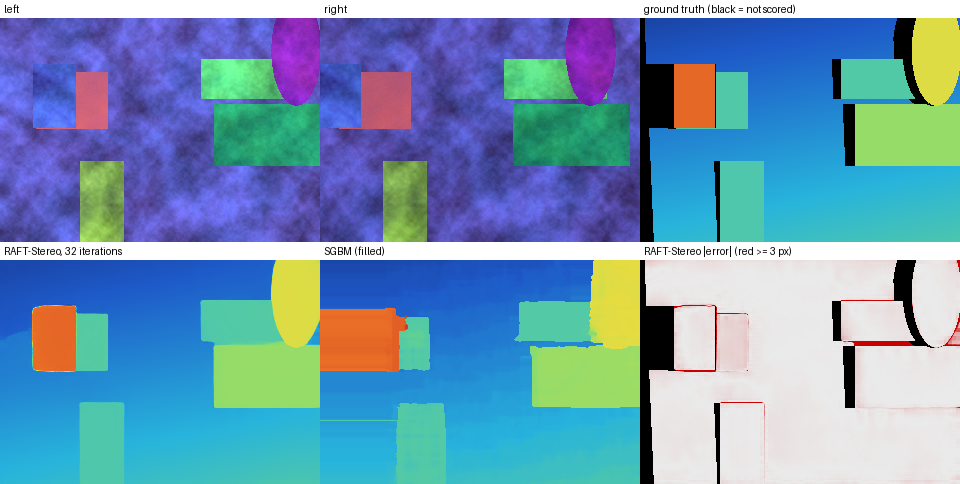

In [5]:
VALID_ITERS = 32  # @param {type:"integer"}

run_stage('demo', '--iters', VALID_ITERS)
show_image('raft_stereo_demo.png', 'Demonstration pair: inputs, ground truth, RAFT-Stereo, SGBM, RAFT-Stereo error')

**What to notice (Section 4):** the validation verdict and the refused probe; the two metric rows; SGBM's `density` (the share of pixels it matched itself before filling); and in the figure, where the red error pixels sit.

<details><summary>Check your reasoning</summary>A pretrained RAFT-Stereo checkpoint usually beats SGBM on EPE and on bad-pixel rates for textured rendered scenes, because it matches learned features over a wide context and its iterations smooth surfaces without blurring their edges. Expect both methods' errors to concentrate along object boundaries (where a disparity jump meets occlusion) and on the deliberately low-texture objects, where neither method has anything to match; SGBM's unmatched pixels there are filled from a row neighbour, which is often wrong. If your run shows the opposite ordering, that is a finding about this checkpoint on this rendered domain — note it; it is what Sections 7–9 measure properly on held-out pairs.</details>

## 5. Probes with exact answers: random dots shifted by 2 px and by 8 px · [Evaluation practice]

Before trusting any score, check that the model's output means what you think it means. Two random-dot pairs have an answer that is known exactly and needs no rendering model at all:

- **a shift of 2 px**: the right image is the left image moved 2 px, so the true disparity is **2** everywhere (the left 2 columns have no match and are not scored);
- **a shift of 8 px**: the same with an 8 px move, so the true disparity is **8** everywhere (the left 8 columns are not scored).

A wrong sign would show up as medians near −2 and −8, a scale error as a ratio between the two medians far from 4, and a constant bias as both medians off by the same amount. Random dots are not natural images, so a small error here says nothing about scenes; a large one says the pipeline is wired wrongly.

**Predict before running:** what median disparity will the model report for each probe, and will its 5th–95th percentile range be narrow (under 1 px) or wide?

In [6]:
run_stage('probes', '--iters', VALID_ITERS)

Running stage 'probes' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/probes.log
{'probe': 'random-dots-shift-2', 'true_disparity_px': 2, 'predicted_median_px': 149.825, 'predicted_p05_p95_px': [138.581, 157.111], 'epe': 147.1734, 'bad_1px': 1.0, 'bad_2px': 1.0, 'bad_3px': 1.0, 'd1_all': 1.0}
{'probe': 'random-dots-shift-8', 'true_disparity_px': 8, 'predicted_median_px': 8.001, 'predicted_p05_p95_px': [7.943, 8.069], 'epe': 0.0318, 'bad_1px': 0.0, 'bad_2px': 0.0, 'bad_3px': 0.0, 'd1_all': 0.0}
{'stage': 'probes', 'namespace': 'sample', 'status': 'ok', 'seconds': 3.7}


**What to notice (Section 5):** `predicted_median_px` against `true_disparity_px`, and the width of `predicted_p05_p95_px`.

<details><summary>Check your reasoning</summary>A correctly wired pipeline reports medians close to 2 and 8 with narrow percentile ranges: together the probes confirm the sign (positive = the right image's match lies to the left) and the pixel scale. In the recorded Colab T4 run the 8 px probe gave a median of 8.001 px with EPE 0.032. Random dots are an easy, perfectly textured case, so EPE well below 1 px is normal; medians near −2 and −8 would mean left and right were swapped, which is exactly the mistake `validate_dataset` guards against in Section 6. Both probes use a non-zero shift on purpose: an earlier version of this notebook also probed two identical images (true disparity 0), and this checkpoint returned a median of about 235 px there while getting the 8 px probe right, so a degenerate pair with no displacement does not test the wiring.</details>

## 6. Dataset, validation and split · [Evaluation practice]

This cell runs the `prepare` stage. It renders `N_PAIRS` scenes (seed `DATASET_SEED`; scene `i` uses seed `DATASET_SEED × 100003 + i`), each with exact disparity and a valid mask, and validates every record **before any model runs**: matching image sizes within the ceilings, a disparity map of the image's shape, finite non-negative values on valid pixels, unique record ids. It then shows three refusals — a right image of another size, a disparity map of the wrong shape, and a negative (left/right-swapped) disparity — each named by the rule it breaks.

The split is a seeded random 75 / 25 split (`HOLDOUT`, `SEED`): 24 training and 8 held-out pairs. A random split is valid here because every scene is rendered independently; records that share a scene (several exposures or crops of one view) must be split by scene, which `pairs.json` can declare with a `group` field. The stage asserts that no record is on both sides, records the split and the dataset's SHA-256, and every later stage rebuilds exactly these records and refuses to run if they changed. `EPOCHS` is set here because the dataset manifest records it.

**Sample provenance and licence:** generated in code by this package's `samples.py`; no third-party data, no licence terms beyond the repository's. **Pretraining overlap:** the checkpoint was trained on SceneFlow (rendered) and fine-tuned on Middlebury photographs; these scenes are rendered at runtime and cannot be in either set, but they resemble SceneFlow's random-object style, so the domain is not entirely new to the network.

**Predict before running:** what share of each pair's pixels will have a valid ground truth — nearly all, about nine in ten, or about half — and which pixels lose it?

In [7]:
N_PAIRS = 32  # @param {type:"integer"}
DATASET_SEED = 0  # @param {type:"integer"}
HOLDOUT = 0.25  # @param {type:"number"}
SEED = 20261004  # @param {type:"integer"}
EPOCHS = 3  # @param {type:"integer"}

run_stage('prepare', '--n-pairs', N_PAIRS, '--dataset-seed', DATASET_SEED, '--holdout', HOLDOUT, '--seed', SEED, '--epochs', EPOCHS)

Running stage 'prepare' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/prepare.log
{'source': 'sample', 'n_records': 32, 'image_sizes': [[320, 224]], 'mean_valid_fraction': 0.9123386928013393, 'max_disparity_px': 39.84931182861328, 'mean_disparity_px': 13.408177917095026, 'epochs': 3}
{'train': 24, 'held_out': 8, 'holdout': 0.25, 'split_seed': 20261004, 'shared_ids': 0}
{'probe': 'right image of another size', 'rejected': 'record 0: left and right images differ in size: (320, 224) vs (160, 224); a rectified pair has one size'}
{'probe': 'disparity of another shape', 'rejected': 'record 0: disparity shape (10, 10) != image shape (224, 320)'}
{'probe': 'negative disparity (left and right swapped)', 'rejected': "record 0: 67588 valid pixels have negative disparity; this pipeline expects the LEFT image's disparity (left x matches right x - d), so swap left and right or n"}
{'dataset_sha256': '5e97f149433f4c1e...'}
{'stage': 'prepare', 'namespace': 'sample'

**What to notice (Section 6):** `n_records`, the image size, `mean_valid_fraction` (the share of pixels with a visible match), `max_disparity_px`, the split sizes with `shared_ids: 0`, and the three refusals.

<details><summary>Check your reasoning</summary>The renderer marks a pixel valid only when its surface point is inside the right image and not hidden there by a nearer object, so roughly nine pixels in ten stay valid: the losses are the left-edge strip whose matches fall outside the right frame, and the bands beside object edges that the right camera cannot see. Those pixels have a true disparity but no match, and every metric in this notebook leaves them out (the non-occluded protocol).</details>

## 7. Three baselines on the held-out pairs · [Evaluation practice]

A score means little without something to compare it with. The `baselines` stage scores the 8 held-out pairs three ways, on exactly the same valid pixels:

- **median constant** — the training split's median disparity, predicted everywhere. Any method that does not beat it has learned nothing about the scene.
- **SGBM** — classical semi-global matching. Its search range is the training split's largest disparity plus 8 px, rounded up to a multiple of 16; nothing about the held-out pairs is used to configure it.
- **pretrained RAFT-Stereo** — the verified checkpoint before any adaptation, at `VALID_ITERS` iterations. This is the baseline the fine-tune has to beat.

All three are fitted or configured on the training split only, so the held-out pairs stay untouched evidence. The averages give each pair the same weight; there is one pass and no dispersion estimate, so differences of a few hundredths of a pixel on 8 pairs are not resolved.

**Predict before running:** order the three by held-out EPE. Will the ordering by `bad_3px` be the same?

In [8]:
run_stage('baselines', '--iters', VALID_ITERS)

Running stage 'baselines' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/baselines.log
{'median_disparity_px': 8.245, 'sgbm_num_disparities': 48, 'held_out_pairs': 8, 'iters': 32}
{'median': {'epe': 8.2234, 'bad_1px': 0.8528, 'bad_2px': 0.7406, 'bad_3px': 0.6321, 'd1_all': 0.6321}}
{'sgbm': {'epe': 0.6533, 'bad_1px': 0.0365, 'bad_2px': 0.03, 'bad_3px': 0.0283, 'd1_all': 0.0283}}
{'pretrained': {'epe': 0.231, 'bad_1px': 0.0122, 'bad_2px': 0.0095, 'bad_3px': 0.0079, 'd1_all': 0.0079}}
{'sgbm_mean_density': 0.8013, 'pretrained_seconds': 2.2, 'device': 'cuda:0'}
{'stage': 'baselines', 'namespace': 'sample', 'status': 'ok', 'seconds': 9.9}


**What to notice (Section 7):** the three rows, and whether EPE and `bad_3px` rank them the same way; SGBM's mean density.

<details><summary>Check your reasoning</summary>The median constant should be far behind both matchers — it ignores the images entirely. Between SGBM and the pretrained network, expect the network to lead on EPE and on the bad-pixel rates, but the two measures need not agree: SGBM's filled pixels can be badly wrong (inflating EPE) while most of its matched pixels are within 3 px, and a network can be slightly off almost everywhere (raising `bad_1px`) while rarely failing badly. That is why this notebook reports both: EPE weighs *how large* errors are, bad-pixel rates count *how many* fail.</details>

## 8. Bounded stereo fine-tuning · [Concept]

This cell runs the real adaptation in this runtime (`adapt` stage). It is **gradient fine-tuning** of the pretrained network — not a new head, not PEFT — with upstream's training loss: the L1 error between the true horizontal flow (`−disparity`) and the estimate after **every** refinement iteration, later iterations weighted more (`gamma` 0.9, adjusted to the iteration count), valid pixels only.

- **What trains.** BatchNorm layers are frozen (upstream's `freeze_bn`). With `FREEZE_ENCODERS = True` the feature encoder (`fnet`) and context encoder (`cnet`) also keep their weights; the context projections, the multi-level GRU update block, the disparity head and the upsampling mask train. The cell prints the trainable and total parameter counts.
- **Schedule.** `EPOCHS` epochs over the 24 training pairs, batch size `BATCH_SIZE`, AdamW at a constant `LEARNING_RATE` (2e-5, upstream's Middlebury fine-tuning rate; weight decay 1e-5, eps 1e-8), `TRAIN_ITERS` refinement iterations per step (upstream trains with 22; 12 keeps the tutorial short), gradient-norm clipping at 1.0, float32, seed `SEED`, no augmentation. Upstream's full recipe (OneCycle schedule, augmentation, mixed precision, 200,000 steps) is out of scope.
- **Every run starts from the checkpoint.** The stage loads the verified checkpoint afresh in its own process, so re-running this cell after changing a field compares the new setting from the same starting point instead of training further.

After training, the stage records the in-memory model's disparity on one held-out pair (the reference for Section 11) and exports `outputs/raft_stereo_adapter.safetensors`. **Read the loss as optimisation evidence only:** a falling loss says the optimiser is fitting the training pairs; Section 9 is the task evidence.

**Predict before running:** will the mean loss fall from epoch 1 to epoch `EPOCHS`? By roughly how much — a few percent, a third, or most of it?

In [9]:
LEARNING_RATE = 2e-5  # @param {type:"number"}
BATCH_SIZE = 2  # @param {type:"integer"}
TRAIN_ITERS = 12  # @param {type:"integer"}
FREEZE_ENCODERS = True  # @param {type:"boolean"}

run_stage('adapt', '--epochs', EPOCHS, '--batch-size', BATCH_SIZE, '--lr', LEARNING_RATE, '--train-iters', TRAIN_ITERS,
          '--freeze-encoders', int(FREEZE_ENCODERS), '--seed', SEED, '--iters', VALID_ITERS)

Running stage 'adapt' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/adapt.log
{'start': 'pretrained checkpoint, freshly loaded and verified', 'source': '/content/weights/raftstereo-middlebury', 'device': 'cuda:0'}
{'epoch': '1/3', 'mean_loss': 2.7093, 'steps': 12}
{'epoch': '2/3', 'mean_loss': 0.9328, 'steps': 24}
{'epoch': '3/3', 'mean_loss': 0.7107, 'steps': 36}
{'freeze_encoders': True, 'trainable_parameters': 5728144, 'total_parameters': 11116176, 'steps': 36, 'batch_size': 2, 'learning_rate': 2e-05, 'train_iters': 12, 'precision': 'float32', 'seconds': 22.5}
{'artifact': 'raft_stereo_adapter.safetensors', 'bytes': 22917592, 'tensors': 42, 'sha256': '8960ee5c1c594717...', 'frozen_prefixes': ['fnet.', 'cnet.']}
{'stage': 'adapt', 'namespace': 'sample', 'status': 'ok', 'seconds': 31.6}


**What to notice (Section 8):** the `start` line (the checkpoint, freshly verified), the epoch losses, the trainable share of the parameters, and the adapter's size and tensor count.

<details><summary>Check your reasoning</summary>The pretrained network already fits these scenes reasonably, so the loss starts moderate and typically falls by a modest fraction over three short epochs — not to zero. With the encoders frozen, roughly half of the 11.1 million parameters train (the encoders hold the rest), and the adapter holds only the tensors that could change. A loss that rises, or turns into `nan`, points at the learning rate; see Troubleshooting.</details>

## 9. Held-out comparison: the exported adapter, in a fresh process · [Evaluation practice]

The `evaluate` stage does not reuse the trained model in memory. It starts a new process, rebuilds the network from the verified checkpoint **plus the exported adapter file**, and scores the same 8 held-out pairs with the same `VALID_ITERS` as the baselines (it refuses to compare against baselines scored with a different iteration count). The table puts the adapted model under the three baselines; a per-pair count says on how many held-out pairs the adapted EPE is lower than the pretrained EPE; and a **run history** keeps one row per evaluation, so the Section 14 activity prints side by side with this run.

**What these numbers are.** Tutorial metrics from one pass over 8 rendered pairs, with no dispersion estimate. No setting was chosen on the held-out pairs, so they are an honest check of this run; they are not evidence about real photographs or about other rigs.

**Predict before running:** will the adapted EPE be lower than the pretrained EPE? On all 8 pairs, or only on most?

In [10]:
run_stage('evaluate', '--iters', VALID_ITERS)

Running stage 'evaluate' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/evaluate.log
{'held_out_pairs': 8, 'iters': 32, 'loaded_from': 'exported adapter, fresh process'}
model              epe   bad_1px   bad_2px   bad_3px    d1_all
median          8.2234    0.8528    0.7406    0.6321    0.6321
sgbm            0.6533    0.0365    0.0300    0.0283    0.0283
pretrained      0.2310    0.0122    0.0095    0.0079    0.0079
adapted         0.1117    0.0086    0.0060    0.0046    0.0046
{'pairs_where_adapted_epe_is_lower': '8/8'}
run history (one row per evaluation in this session; row 0 is the first):
0 {'freeze_encoders': True, 'epochs': 3, 'learning_rate': 2e-05, 'trainable_parameters': 5728144, 'final_loss': 0.7107, 'pretrained_epe': 0.231, 'adapted_epe': 0.1117, 'adapted_bad_3px': 0.0046, 'train_seconds': 22.5}
{'stage': 'evaluate', 'namespace': 'sample', 'status': 'ok', 'seconds': 8.9}


**What to notice (Section 9):** the `adapted` row against the `pretrained` row for every column, the per-pair count, and the run history's row 0.

<details><summary>Check your reasoning</summary>A short fine-tune on the target domain usually lowers held-out EPE and the bad-pixel rates a little, because the update block learns this domain's textures, gain difference and noise. Three things can legitimately differ from that: the improvement may be small compared with pair-to-pair spread (read the per-pair count, not only the mean); one metric may improve while another does not; and on some pairs the adapted model can be worse. With 8 held-out pairs and one run, report the direction and the count, not a precise gain. If the adapted model is worse overall, that is a negative result worth keeping — it is preserved in the outputs, not replaced.</details>

## 10. Inference on unseen pairs · [Concept]

Three new scenes come from a seed the dataset never used (`NEW_DATA_SEED = 99`), so neither the fine-tune nor any choice saw them. The `infer` stage runs the pretrained and the adapted model on each, prints per-pair metrics for both, and **exports the adapted disparity maps** — `outputs/raft_stereo_disparity/<pair>.npy` (float32 pixels, left image) and a 16-bit PNG in the KITTI convention (value / 256) — plus `outputs/raft_stereo_new_pairs.csv` and a figure (left image, ground truth, pretrained, adapted; one colour scale per row, warm = near).

**Predict before running:** on how many of the three unseen pairs will the adapted model have the lower EPE?

Running stage 'infer' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/infer.log
{'id': 'scene-9900297', 'pretrained': {'epe': 0.137, 'bad_1px': 0.0093, 'bad_2px': 0.0067, 'bad_3px': 0.0051, 'd1_all': 0.0051}, 'adapted': {'epe': 0.0838, 'bad_1px': 0.0054, 'bad_2px': 0.0033, 'bad_3px': 0.0023, 'd1_all': 0.0023}, 'adapted_disparity_px': {'min': 3.08, 'median': 13.14, 'max': 40.64}, 'files': ['raft_stereo_disparity/scene-9900297.npy', 'raft_stereo_disparity/scene-9900297.png']}
{'id': 'scene-9900298', 'pretrained': {'epe': 0.1735, 'bad_1px': 0.0118, 'bad_2px': 0.0083, 'bad_3px': 0.0062, 'd1_all': 0.0062}, 'adapted': {'epe': 0.1178, 'bad_1px': 0.0064, 'bad_2px': 0.0031, 'bad_3px': 0.0023, 'd1_all': 0.0023}, 'adapted_disparity_px': {'min': 3.64, 'median': 10.43, 'max': 41.44}, 'files': ['raft_stereo_disparity/scene-9900298.npy', 'raft_stereo_disparity/scene-9900298.png']}
{'id': 'scene-9900299', 'pretrained': {'epe': 0.1621, 'bad_1px': 0.0108, 'bad_2px': 0.00

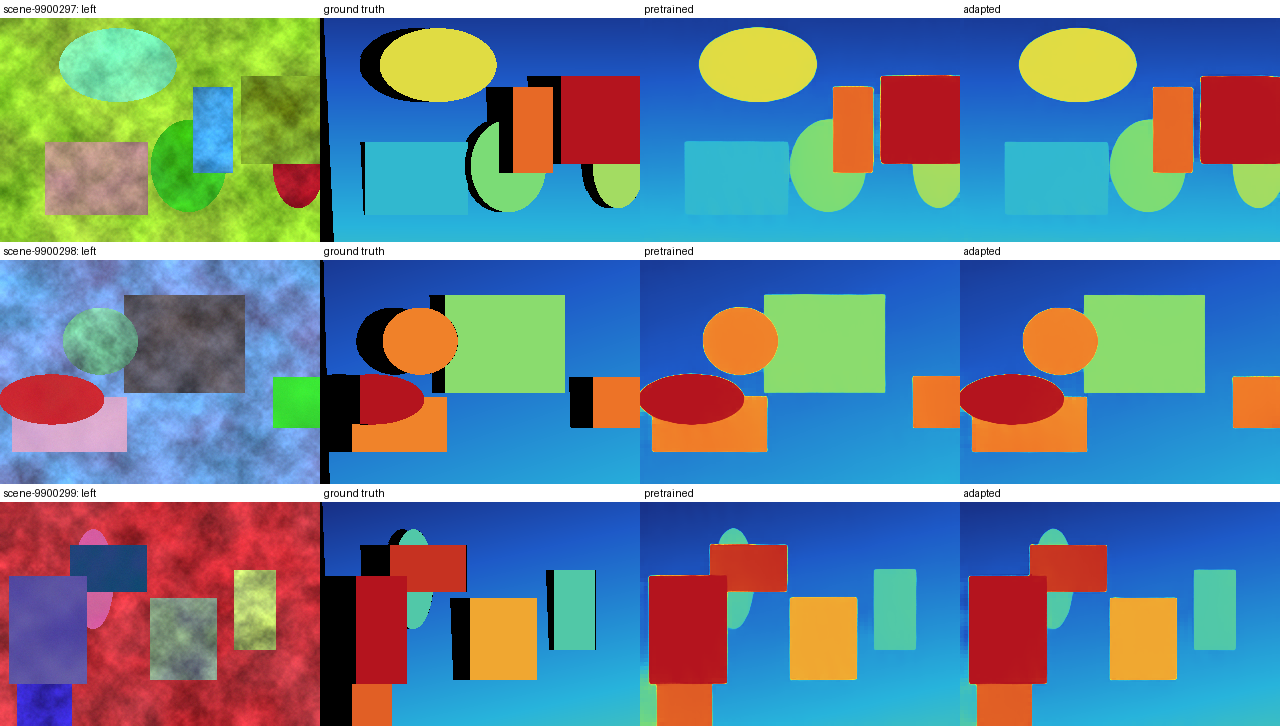

In [11]:
NEW_DATA_SEED = 99  # @param {type:"integer"}

run_stage('infer', '--new-seed', NEW_DATA_SEED, '--iters', VALID_ITERS)
show_image('raft_stereo_new_pairs.png', 'Unseen pairs: left, ground truth, pretrained, adapted')

**What to notice (Section 10):** `adapted_epe_lower_on`, each pair's two metric rows, and in the figure whether the adapted maps differ visibly from the pretrained ones (usually only at edges and on low-texture objects).

<details><summary>Check your reasoning</summary>Three pairs are a demonstration, not an evaluation: the count can be 3/3, 2/3 or worse even when the held-out average improved, because single scenes vary a lot (a large low-texture object can dominate a pair's EPE). The disparity files are the deliverable of this stage: machine-readable maps that a downstream user could convert to depth with their own calibration.</details>

## 11. Fresh reload and equivalence check · [Engineering]

Exporting a file is not the same as exporting the model. The `reload` stage starts yet another process, reads the adapter's provenance header (format, base model and revision, upstream commit, architecture arguments, frozen prefixes) and refuses one that does not fit, rebuilds the network from the verified checkpoint plus the adapter, and compares its disparity on the reference held-out pair with the disparity the **trained in-memory model** produced in Section 8, within a stated tolerance (mean absolute difference ≤ 0.001 px, maximum ≤ 0.01 px); it also checks that the held-out EPE measured in memory equals the fresh-process value of Section 9. Loading without error is not the check; reproducing the output is. The stage then writes `outputs/raft_stereo_result.json` with the provenance.

In [12]:
run_stage('reload')

Running stage 'reload' in the isolated environment; log: /content/outputs/raft_stereo/f9edce1ef640/logs/reload.log
{'artifact': 'raft_stereo_adapter.safetensors', 'format': 'raft-stereo-adapter-v1', 'base': 'princeton-vl/RAFT-Stereo/raftstereo-middlebury', 'base_revision': 'd22e84c0e431bf31', 'frozen_prefixes': ['fnet.', 'cnet.']}
{'reload_parity': {'reference_pair': 'scene-0', 'mean_abs_diff_px': 0.0, 'max_abs_diff_px': 0.0, 'tolerance_px': {'mean_abs': 0.001, 'max_abs': 0.01}, 'held_out_epe_in_memory': 0.11171861, 'held_out_epe_fresh_process': 0.11171861, 'compared_with': "the trained in-memory model of the 'adapt' process", 'equivalent': True}}
outputs/:
  - probes.json (0.6 KB)
  - raft_stereo_adaptation.json (2.0 KB)
  - raft_stereo_adapter.safetensors (22380.5 KB)
  - raft_stereo_baselines.json (7.5 KB)
  - raft_stereo_dataset.json (4.2 KB)
  - raft_stereo_demo.png (301.4 KB)
  - raft_stereo_demo_disparity.npy (280.1 KB)
  - raft_stereo_disparity/scene-9900297.npy (280.1 KB)
  - 

**What to notice (Section 11):** `equivalent: True`, the two differences against their tolerances, and the list of files written.

## 12. Outputs and provenance · [Engineering]

Everything the stages wrote is under this run's `outputs/` directory:

- `raft_stereo_input_manifest.json` and `raft_stereo_evaluation_report.json` — the demonstration pair's validation and report;
- `probes.json` — the two exact-answer probes;
- `raft_stereo_dataset.json` — dataset manifest, SHA-256, split ids and the refusal probes;
- `raft_stereo_baselines.json`, `raft_stereo_adaptation.json`, `raft_stereo_held_out_evaluation.json` — baselines, fine-tuning configuration and losses, and the held-out comparison with per-pair rows and the run history;
- `raft_stereo_new_pairs.json`, `raft_stereo_new_pairs.csv`, `raft_stereo_disparity/` — unseen-pair metrics and disparity maps;
- `raft_stereo_adapter.safetensors` — the adapter (provenance in its header);
- `raft_stereo_result.json` — identity (model, checkpoint revision, upstream commit), runtime versions, device, dataset digest, split, adaptation configuration, held-out table, artifact digest and reload parity;
- `weights.json`, the PNG figures and `logs/` with every stage's full output.

The next cell reads the result record in the kernel and prints its identity fields.

**Expected result:** three dictionaries — the model id, the checkpoint revision, the upstream commit, the repository revision, the device and the dataset digest; the adapter's digest and size with `reload_equivalent: True`; and the held-out table — followed by the run directory.

In [13]:
result = load_record('raft_stereo_result.json')
print({'model': result['model']['id'], 'checkpoint_revision': result['model']['revision'], 'upstream_commit': result['upstream_code']['commit'],
       'repository_revision': result['repository_revision'], 'device': result['model']['device'], 'dataset_sha256': result['dataset_sha256'][:16] + '...'})
print({'artifact_sha256': result['artifact']['sha256'][:16] + '...', 'artifact_bytes': result['artifact']['bytes'], 'reload_equivalent': result['reload_parity']['equivalent']})
print({'held_out_table': result['held_out_table']})
print('run directory:', ROOT)

{'model': 'princeton-vl/RAFT-Stereo/raftstereo-middlebury', 'checkpoint_revision': 'd22e84c0e431bf31d7cc66902c40601859eb40b35ef7f4399ea81276c2915819', 'upstream_commit': '6e93ed2169bd858dbb43033988563f3b0bb49506', 'repository_revision': '95db0ef90f1534ac473cadad8564c2c26c07a90b', 'device': 'cuda:0', 'dataset_sha256': '5e97f149433f4c1e...'}
{'artifact_sha256': '8960ee5c1c594717...', 'artifact_bytes': 22917592, 'reload_equivalent': True}
{'held_out_table': {'median': {'epe': 8.2234, 'bad_1px': 0.8528, 'bad_2px': 0.7406, 'bad_3px': 0.6321, 'd1_all': 0.6321}, 'sgbm': {'epe': 0.6533, 'bad_1px': 0.0365, 'bad_2px': 0.03, 'bad_3px': 0.0283, 'd1_all': 0.0283}, 'pretrained': {'epe': 0.231, 'bad_1px': 0.0122, 'bad_2px': 0.0095, 'bad_3px': 0.0079, 'd1_all': 0.0079}, 'adapted': {'epe': 0.1117, 'bad_1px': 0.0086, 'bad_2px': 0.006, 'bad_3px': 0.0046, 'd1_all': 0.0046}}}
run directory: /content/outputs/raft_stereo/f9edce1ef640


## 13. Optional: Bring Your Own Data (BYOD) · [Evaluation practice]

Both branches are off by default, so **Run all** never stops here. Read the contract before you switch one on:

- **Pair branch** (`USE_BYOD_PAIR`): one **rectified** pair — two images of the same size, each side 64..1280 px, at most 1,310,720 pixels — and optionally its ground-truth disparity for the left image (`.pfm`, `.npy` or 16-bit KITTI `.png`). It runs `validate_inputs`, the pretrained model, SGBM and `evaluation_report` (`not-measurable` without ground truth) and writes `outputs/byod/byod_pair_*`. Unrectified photos (two phone shots, for example) violate the row assumption and give meaningless disparity. Through the upload dialog, upload two or three files whose names say which is which: `left`/`im0`, `right`/`im1`, and `disp` for the ground truth.
- **Dataset branch** (`USE_BYOD_DATASET`): a folder (or one `.zip`) holding `pairs.json` — a list of `{"left", "right", "disparity", "valid"?, "group"?}` objects with paths relative to the folder — and the files it names; at least 2 independent groups. It runs the **same stages as the sample** — `prepare` (validate and split, by `group` when given) → `baselines` → `adapt` → `evaluate` → `infer` (on the held-out pairs) → `reload` — with the same fields as above (`HOLDOUT`, `SEED`, `EPOCHS`, `LEARNING_RATE`, `BATCH_SIZE`, `TRAIN_ITERS`, `FREEZE_ENCODERS`, `VALID_ITERS`), and writes everything to `outputs/byod/` with a `byod_` prefix, so the sample results are kept. Pairs larger than 448 × 320 px are cropped at a seeded random position for training only. Middlebury 2014 scenes at quarter or half resolution fit the ceilings; note that the checkpoint was fine-tuned on Middlebury, so scoring it there is not independent evidence.

Set `BYOD_LEFT_PATH` and `BYOD_RIGHT_PATH` (and optionally `BYOD_DISPARITY_PATH`), or `BYOD_DATASET_DIR` (a folder or a `.zip`), to read from a mounted or local location; leave them empty on Colab to get an upload dialog. Uploads are written under this run's `byod/` directory and are not sent anywhere. A record that breaks the contract stops the cell with the validator's message naming the rule (wrong sizes, missing file, a path outside the folder, negative disparity, fewer than 2 groups). After changing a field here, re-run this cell only.

In [14]:
USE_BYOD_PAIR = False  # @param {type:"boolean"}
BYOD_LEFT_PATH = ''  # @param {type:"string"}
BYOD_RIGHT_PATH = ''  # @param {type:"string"}
BYOD_DISPARITY_PATH = ''  # @param {type:"string"}
USE_BYOD_DATASET = False  # @param {type:"boolean"}
BYOD_DATASET_DIR = ''  # @param {type:"string"}

import shutil
import zipfile

BYOD_ROOT = ROOT / 'byod'
BYOD_MAX_ARCHIVE_FILES = 4001
BYOD_MAX_EXPANDED_BYTES = 4 * 1024**3


def _upload_into(target):
    """Colab upload dialog into a fresh `target`, so an earlier upload never mixes with this one."""
    try:
        from google.colab import files
    except ImportError as exc:
        raise RuntimeError('There is no upload dialog outside Google Colab: set the BYOD location fields to local paths.') from exc
    shutil.rmtree(target, ignore_errors=True)
    target.mkdir(parents=True)
    uploaded = files.upload()
    if not uploaded:
        raise ValueError('Nothing was uploaded: run the cell again and choose the files.')
    for name, data in uploaded.items():
        (target / Path(name).name).write_bytes(data)
    return target


def _safe_unzip(archive, target):
    """Extract a BYOD .zip member by member into a fresh `target`, refusing unsafe paths and oversized archives."""
    shutil.rmtree(target, ignore_errors=True)
    target.mkdir(parents=True)
    with zipfile.ZipFile(archive) as bundle:
        members = [m for m in bundle.infolist() if not m.is_dir()]
        if len(members) > BYOD_MAX_ARCHIVE_FILES:
            raise ValueError(f'{Path(archive).name} holds {len(members)} files, more than {BYOD_MAX_ARCHIVE_FILES}')
        if sum(m.file_size for m in members) > BYOD_MAX_EXPANDED_BYTES:
            raise ValueError(f'{Path(archive).name} expands to more than {BYOD_MAX_EXPANDED_BYTES:,d} bytes')
        for member in members:
            name = member.filename.replace('\\', '/')
            parts = [p for p in name.split('/') if p not in ('', '.')]
            if name.startswith('/') or ':' in name or '..' in parts:
                raise ValueError(f'{Path(archive).name}: unsafe member path {member.filename!r}')
            destination = target.joinpath(*parts)
            destination.parent.mkdir(parents=True, exist_ok=True)
            destination.write_bytes(bundle.read(member))
    return target


def _dataset_root(source):
    """The folder holding pairs.json: `source` itself, the inside of one .zip, or its single sub-folder that has one."""
    source = Path(source)
    if source.is_file() and source.suffix.lower() == '.zip':
        source = _safe_unzip(source, BYOD_ROOT / 'unzipped')
    elif source.is_dir() and not (source / 'pairs.json').is_file():
        archives = sorted(source.glob('*.zip'))
        if len(archives) == 1:
            source = _safe_unzip(archives[0], BYOD_ROOT / 'unzipped')
    if (source / 'pairs.json').is_file():
        return source
    found = sorted(source.rglob('pairs.json'))
    if len(found) != 1:
        raise ValueError(f'expected one pairs.json under {source}, found {len(found)}: upload pairs.json and the files it names, or one .zip')
    return found[0].parent


def _pick(paths, keys, role):
    """The one uploaded file whose name contains one of `keys`."""
    chosen = [p for p in paths if any(k in p.stem.lower() for k in keys)]
    if len(chosen) != 1:
        raise ValueError(f'name exactly one uploaded file with {" or ".join(keys)} for the {role}; got {[p.name for p in chosen]}')
    return chosen[0]


if USE_BYOD_PAIR:
    if BYOD_LEFT_PATH and BYOD_RIGHT_PATH:
        left_path, right_path = Path(BYOD_LEFT_PATH), Path(BYOD_RIGHT_PATH)
        disparity_path = Path(BYOD_DISPARITY_PATH) if BYOD_DISPARITY_PATH else None
    else:
        uploaded = sorted(p for p in _upload_into(BYOD_ROOT / 'pair').iterdir() if p.is_file())
        left_path, right_path = _pick(uploaded, ('left', 'im0'), 'left image'), _pick(uploaded, ('right', 'im1'), 'right image')
        rest = [p for p in uploaded if p not in (left_path, right_path)]
        disparity_path = _pick(rest, ('disp',), 'ground-truth disparity') if rest else None
    pair_options = ['--namespace', 'byod', '--left', left_path, '--right', right_path, '--iters', VALID_ITERS]
    if disparity_path is not None:
        pair_options += ['--disparity', disparity_path]
    run_stage('byod_pair', *pair_options)
    show_image('byod/byod_pair.png', 'BYOD pair')
else:
    print('BYOD pair branch is off; set USE_BYOD_PAIR = True to run the pretrained model on your own rectified pair.')

if USE_BYOD_DATASET:
    dataset_dir = _dataset_root(BYOD_DATASET_DIR if BYOD_DATASET_DIR else _upload_into(BYOD_ROOT / 'dataset'))
    for stage, options in (
        ('prepare', ['--byod', dataset_dir, '--holdout', HOLDOUT, '--seed', SEED, '--epochs', EPOCHS]),
        ('baselines', ['--iters', VALID_ITERS]),
        ('adapt', ['--epochs', EPOCHS, '--batch-size', BATCH_SIZE, '--lr', LEARNING_RATE, '--train-iters', TRAIN_ITERS,
                   '--freeze-encoders', int(FREEZE_ENCODERS), '--seed', SEED, '--iters', VALID_ITERS]),
        ('evaluate', ['--iters', VALID_ITERS]),
        ('infer', ['--iters', VALID_ITERS]),
        ('reload', []),
    ):
        run_stage(stage, '--namespace', 'byod', *options)
    byod_result = load_record('byod/byod_raft_stereo_result.json')
    print({'byod_held_out_table': byod_result['held_out_table'], 'reload_equivalent': byod_result['reload_parity']['equivalent']})
else:
    print('BYOD dataset branch is off; set USE_BYOD_DATASET = True to adapt RAFT-Stereo on your own labelled pairs.')

BYOD pair branch is off; set USE_BYOD_PAIR = True to run the pretrained model on your own rectified pair.
BYOD dataset branch is off; set USE_BYOD_DATASET = True to adapt RAFT-Stereo on your own labelled pairs.


## 14. Your turn — change one thing: unfreeze the encoders · [Concept]

Optional; **Predict → Change one thing → Run → Observe → Explain**. It re-runs the fine-tune with every parameter trainable, which takes longer than Section 8 did.

1. **Predict:** with `FREEZE_ENCODERS = False`, will the held-out EPE go down further, stay about the same, or get worse than in row 0 of the Section 9 run history? Write your guess down.
2. **Change:** in Section 8 set `FREEZE_ENCODERS = False`. Change nothing else.
3. **Run:** select the Section 8 cell and choose **Runtime → Run after**. Section 8 loads the verified checkpoint afresh in a new process (its `start` line says so) and trains every parameter; Section 9 adds row 1 to the run history; Sections 10–12 re-run on the new adapter.
4. **Observe:** in Section 8, the trainable parameter count rises to all 11,116,176 and the adapter grows (it now carries the encoders). In Section 9 compare rows 0 and 1: `adapted_epe`, `adapted_bad_3px`, `final_loss` and `train_seconds`.
5. **Explain:** in one sentence, why can training more parameters lower the training loss without lowering the held-out EPE?

<details><summary>Check your reasoning</summary>Unfreezing the encoders gives the optimiser more capacity, so the training loss often falls further; whether the held-out EPE follows depends on whether the encoders' changes generalise from 24 rendered pairs, and with so few pairs they can also start to fit the training scenes' particular textures. Both runs start from the same checkpoint with the same seed, so the comparison is fair; but it is one run each on 8 held-out pairs, so a difference of a few hundredths of a pixel is unresolved, not a ranking of the two settings. This notebook has no recorded hosted run of this comparison: your run history is the measurement.</details>

## Interpretation and limits

Start from your own run: the Section 7 baseline table, the Section 9 adapted row and per-pair count, and the Section 10 count.

**What this notebook established, in this runtime.** The carried upstream RAFT-Stereo source was verified file by file against its SHA-256 digests at a pinned commit, and the checkpoint was verified against a committed manifest before loading. The pretrained model was run on a rendered pair with exact ground truth and on two probes with exact answers, and compared with classical SGBM. A 32-pair rendered dataset was validated and split; the held-out pairs were scored against a median constant, SGBM and the pretrained network, all configured on the training split only; a bounded fine-tune ran; the exported adapter was scored in a fresh process on the same held-out pairs; the adapted model produced disparity maps for unseen pairs; and a second fresh process rebuilt the model from files and reproduced the trained model's output within a stated tolerance.

**Reading the metrics.** EPE weighs the size of errors and is pulled up by a few large failures; bad-pixel rates count failures above a threshold and ignore their size; neither alone characterises a disparity map. Every metric is computed on valid (non-occluded, in-frame) pixels only, so occluded regions — where every stereo method must guess — are not scored. RAFT-Stereo returns no confidence: it assigns a disparity to every pixel, including those with no possible match.

**What a green run proves.** Successful execution proves that the recorded repository revision, the pinned dependency set, the carried upstream source and the pinned checkpoint together reproduce these stages in a fresh runtime, without the repository being cloned or installed and without any DIMER worker or service. It does **not** establish benchmark superiority, accuracy on real photographs or on any particular rig, or fitness for any deployment. The held-out scores are tutorial metrics from one pass over 8 rendered pairs with no dispersion estimate; the rendered scenes resemble the network's synthetic pretraining data, and the checkpoint was fine-tuned on Middlebury, so neither domain is independent of its training.

**Reproducibility.** Seeds are form fields (`DATASET_SEED`, `SEED`, `NEW_DATA_SEED`); rendering, the split and the training order are seeded; the run is float32 without augmentation. GPU kernels are not forced to be deterministic, so repeated GPU runs, and GPU against CPU runs, can differ in the last digits of the losses and metrics.

**More experiments (optional).** Each names the cell to change and where to re-run from.

- **Fewer refinement iterations:** set `VALID_ITERS = 8` in Section 4 and choose **Runtime → Run after** from Section 4; compare the demonstration and held-out EPE with 32 iterations, and the time per stage in the logs.
- **Longer training:** set `EPOCHS = 6` in Section 6 and **Run after** from Section 6.
- **A harder split:** set `N_PAIRS = 16` in Section 6 (12 training pairs) and **Run after** from Section 6.
- **Your own labelled pairs:** turn on `USE_BYOD_DATASET` in Section 13 and re-run that cell only.

## Troubleshooting

- **Section 1 stops with "needs a Linux x86_64".** The locked environment is built from manylinux wheels; use Google Colab, Kaggle or a Linux Jupyter server.
- **Section 1 prints the CPU note.** No GPU was found. The notebook still completes, slowly; for the documented runtime choose *Runtime → Change runtime type → T4 GPU* and **Run all** again.
- **Section 2 fails while downloading, or reports a size or hash mismatch.** The `uv` wheel, the managed Python and the locked packages come from PyPI and python-build-standalone; run the cell again. A mismatch is refused on purpose — if it repeats, the download is being altered.
- **Not enough disk.** The isolated environment needs about 8 GiB. Start a fresh runtime, or delete old `outputs/` run directories and the temporary `raft_stereo_env_*` folders.
- **Section 3 says the checkpoint is not pinned.** This revision of the notebook was generated before the checkpoint's SHA-256 was recorded; use a revision of the notebook generated after pinning (see the repository's `docs/release-verification.md`).
- **Section 3 fails to download or stops on a digest mismatch.** The archive comes from upstream's Dropbox link without a credential; run the cell again. A size or SHA-256 mismatch is never loaded: if it repeats, the upstream archive has changed and the notebook must be re-pinned by a maintainer. Delete `weights/` before retrying a partial download.
- **Out of memory in Section 8 or 14.** Lower `BATCH_SIZE` to 1 or `TRAIN_ITERS` to 8 in Section 8, or keep `FREEZE_ENCODERS = True`, and **Run after** from Section 8.
- **The loss turns into `nan` or rises steadily.** Lower `LEARNING_RATE` (for example to 1e-5) and re-run from Section 8.
- **A stage stops with "... is missing: run the stage that writes it".** A cell was run out of order; run the notebook from Section 4 again (Sections 1–3 need not be repeated).
- **Section 9 refuses because the baselines used another iteration count.** You changed `VALID_ITERS` after Section 7 ran; **Run after** from Section 7.
- **BYOD is refused.** Each refusal names the rule: images of different sizes, a side outside 64..1280 px, a disparity map of the wrong shape, a negative disparity (swap left and right), a file missing from the folder, a path with `..`, an unsupported disparity format, or fewer than 2 independent groups. Fix the data and re-run Section 13.

## Conclusion (your notes)

Optional. Fill in from your own run, one sentence each:

1. On the demonstration pair, RAFT-Stereo's EPE was ___ px and SGBM's ___ px; the probes reported medians of ___ and ___ px.
2. On the 8 held-out pairs, the median constant, SGBM and the pretrained network had EPE ___, ___ and ___ px.
3. After the fine-tune, the held-out EPE was ___ px (bad-3 ___); the adapted model was better than the pretrained one on ___ of 8 pairs.
4. On the unseen pairs it was better on ___ of 3; the reload check reported a maximum difference of ___ px.
5. An important failure mode I saw (where, and in which metric): ___.
6. What I would need before using this adapter on real images from my own rig: ___.

## References

- Lipson, L., Teed, Z., & Deng, J. (2021). RAFT-Stereo: Multilevel recurrent field transforms for stereo matching. *International Conference on 3D Vision (3DV)*. [arXiv:2109.07547](https://arxiv.org/abs/2109.07547)
- Teed, Z., & Deng, J. (2020). RAFT: Recurrent all-pairs field transforms for optical flow. *European Conference on Computer Vision (ECCV)*. [arXiv:2003.12039](https://arxiv.org/abs/2003.12039)
- Hirschmüller, H. (2008). Stereo processing by semiglobal matching and mutual information. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 30*(2), 328–341. https://doi.org/10.1109/TPAMI.2007.1166
- Mayer, N., Ilg, E., Häusser, P., Fischer, P., Cremers, D., Dosovitskiy, A., & Brox, T. (2016). A large dataset to train convolutional networks for disparity, optical flow, and scene flow estimation. *IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*. [arXiv:1512.02134](https://arxiv.org/abs/1512.02134)
- Scharstein, D., Hirschmüller, H., Kitajima, Y., Krathwohl, G., Nešić, N., Wang, X., & Westling, P. (2014). High-resolution stereo datasets with subpixel-accurate ground truth. *German Conference on Pattern Recognition (GCPR)*. https://doi.org/10.1007/978-3-319-11752-2_3
- Upstream repository: [princeton-vl/RAFT-Stereo](https://github.com/princeton-vl/RAFT-Stereo) — MIT; code carried at commit `6e93ed2169bd858dbb43033988563f3b0bb49506`; checkpoint from its `download_models.sh`.
- Repository model card: https://github.com/kurtvalcorza/raft-stereo-pipeline/blob/main/MODEL_CARD.md
- [`kurtvalcorza/raft-stereo-pipeline`](https://github.com/kurtvalcorza/raft-stereo-pipeline) — source repository for this pipeline.